# 资产定价检验：预测 Expected Shortfall 与未来股票收益

本 notebook 只使用前一步冻结的样本外预测，不使用资产定价结果选择模型或修改 ES 定义。

主要检验：

1. structure MDN模型的 5%, 10% return-ES 单变量组合排序；
2. High ES minus Low ES 的均值、Newey–West $t$ 值和因子调整 alpha；
3. Fama–MacBeth 横截面回归；
4. Structured K3 的 adverse contribution 与 severity 定价；
5. severity premium 是否随 macro-conditioned adverse weight 变化；
6. 1%/10% ES、五组、breakpoints 和 microcap 的稳健性。

时间约定始终为：$widehat{ES}_{i,t}\rightarrow R_{i,t+1}$。`mthcaldt` 是信号形成月，`target_ret_final` 是下一月收益。

**ES 口径**：$ES_\alpha=E[R\mid R\le VaR_\alpha]$，亏损保留负数。


In [1]:
# ==========================================
# 1. 设置路径、模型版本和主要参数
# ==========================================
import os
os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/pricing-matplotlib")

from pathlib import Path
import sqlite3
import warnings

import numpy as np
import pandas as pd


import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from IPython.display import display


# warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)

# 该时间戳必须对应已经冻结的模型预测版本

# timestamp = "20260925_0018" # rank + training 72 months + ffi12 + random seed 42 + new quantile levels + flim
# save_version = "robustness" # main or robustness


timestamp = "20260928_0204" # normal + training 72 months + ffi12 + random seed 42 + new quantile levels + flim
save_version = "main" # main or robustness

alphas = (0.05, 0.10)
industry_type = "ffi12"  # 'ffi12' 或 'ffi49'
PRIMARY_GROUPS = 10
NW_LAGS = 12


project_root = Path("/Users/jianbinchen/NonSync/GitHub/Research/PricingTailRisk_MDN")
forecast_dir = Path("/Users/jianbinchen/Downloads/results")
result_dir = project_root / "output"
figure_dir = project_root / "overleaf/fig"
result_dir.mkdir(parents=True, exist_ok=True)
figure_dir.mkdir(parents=True, exist_ok=True)

WRDS_db_path = Path("/Users/jianbinchen/NonSync/GitHub/Research/DataSet/WRDS.sqlite")

model_order = [
    "rolling_normal", 
    "linear_quantile", 
    "fused_normal_k1", 
    "fused_normal_k3", 
    "structured_normal_k3", 
    # "film_sigma", 
    # "film_all"
    ]
model_labels = {
    "rolling_normal": "Rolling Normal", 
    "linear_quantile": "Linear Quantile",
    "fused_normal_k1": "Fused Normal K1", 
    "fused_normal_k3": "Fused Normal K3",
    "structured_normal_k3": "Structured Normal K3",
    # "film_sigma": "FiLM Sigma",
    # "film_all": "FiLM All"
}
model_files = {
    "rolling_normal": forecast_dir / f"rolling_normal_forecasts_{timestamp}.parquet",
    "linear_quantile": forecast_dir / f"linear_quantile_forecasts_{timestamp}.parquet",
    "fused_normal_k1": forecast_dir / f"fused_k1_forecasts_{timestamp}.parquet",
    "fused_normal_k3": forecast_dir / f"fused_k3_forecasts_{timestamp}.parquet",
    "structured_normal_k3": forecast_dir / f"structured_forecasts_{timestamp}.parquet",
    # "film_sigma": forecast_dir / f"film_sigma_forecasts_{timestamp}.parquet",
    # "film_all": forecast_dir / f"film_all_forecasts_{timestamp}.parquet",
}

model_colors = {
    "rolling_normal": "#4C78A8", 
    "linear_quantile": "#F2A541", 
    "fused_normal_k1": "#8C8C8C",
    "fused_normal_k3": "#B279A2", 
    "structured_normal_k3": "#2F6B4F",
    # "film_sigma": "#D98C3F",
    # "film_all": "#E15759",
}
signal_colors = {
    **{f"Total ES ({alpha * 100:g}%)": "#2F6B4F" for alpha in alphas}, 
    "Adverse contribution": "#D98C3F", 
    "Adverse severity": "#4C78A8",
}

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

## 2. 构建资产定价样本

- `mthcap` 使用信号月末市值，因此 value weights 不使用未来信息；
- `crsp_msenames` 按信号日期识别 common shares 和 NYSE 股票；
- NYSE 股票只用于形成 breakpoints，全部合格股票随后参与组合；
- FF factors 与下一月组合收益对齐。

In [2]:
# ==========================================
# 2.1 读取 Structured components、公司特征和 WRDS 数据
# ==========================================
structured_components = pd.read_parquet(result_dir / f"structured_components_{timestamp}.parquet")
structured_components["mthcaldt"] = pd.to_datetime(structured_components["mthcaldt"]) + pd.offsets.MonthEnd(0)
display(pd.concat([structured_components.head(), structured_components.tail()]))

micro_data = pd.read_parquet(project_root / "data/micro_data.parquet")
micro_data["mthcaldt"] = pd.to_datetime(micro_data["mthcaldt"]) + pd.offsets.MonthEnd(0)
display(pd.concat([micro_data.head(), micro_data.tail()]))

with sqlite3.connect(WRDS_db_path) as conn:
    crsp_names = pd.read_sql_query(
        "SELECT permno, namedt, nameendt, shrcd, exchcd FROM crsp_msenames", conn
    )
    ff3 = pd.read_sql_query(
        "SELECT year, month, mktrf, smb, hml, umd, rf FROM ff_factors_monthly", conn
    )
    ff5 = pd.read_sql_query(
        "SELECT year, month, mktrf, smb, hml, rmw, cma, umd, rf FROM ff_fivefactors_monthly", conn
    )

structured_components["permno"] = structured_components["permno"].astype("Int64")
micro_data["permno"] = micro_data["permno"].astype("Int64")

ff3["return_date"] = pd.to_datetime(dict(year=ff3["year"].astype(int), month=ff3["month"].astype(int), day=1)) + pd.offsets.MonthEnd(0)
ff5["return_date"] = pd.to_datetime(dict(year=ff5["year"].astype(int), month=ff5["month"].astype(int), day=1)) + pd.offsets.MonthEnd(0)
ff3 = ff3.rename(columns={c: f"{c}_ff3" for c in ["mktrf", "smb", "hml", "umd", "rf"]})
ff5 = ff5.rename(columns={c: f"{c}_ff5" for c in ["mktrf", "smb", "hml", "rmw", "cma", "umd", "rf"]})
factor_data = ff3.drop(columns=["year", "month"]).merge(
    ff5.drop(columns=["year", "month"]), on="return_date", validate="one_to_one"
)
display(pd.concat([factor_data.head(), factor_data.tail()]))

,permno,mthcaldt,target_ret_final,model_id,window,var_5,es_5,var_10,es_10,effective_k,max_pi,adverse_is_lowest_mu,es_reconstructed_5,es_reconstructed_10,pi_adverse,mu_adverse,sigma_adverse,tail_weight_adverse_5,severity_adverse_5,es_contribution_adverse_5,tail_weight_adverse_10,severity_adverse_10,es_contribution_adverse_10,pi_normal,mu_normal,sigma_normal,tail_weight_normal_5,severity_normal_5,es_contribution_normal_5,tail_weight_normal_10,severity_normal_10,es_contribution_normal_10,pi_favorable,mu_favorable,sigma_favorable,tail_weight_favorable_5,severity_favorable_5,es_contribution_favorable_5,tail_weight_favorable_10,severity_favorable_10,es_contribution_favorable_10,separation_adverse_normal,separation_normal_favorable
0,10001,2007-01-31,0.264774,structured_normal_k3,0,-0.137231,-0.180256,-0.102058,-0.149115,2.035929,0.596651,True,-0.180256,-0.149115,0.596651,-0.002109,0.093437,0.883902,-0.178984,-0.158204,0.849516,-0.149855,-0.127304,0.365745,0.021116,0.065137,0.055074,-0.158660,-0.008738,0.107210,-0.127203,-0.013637,0.037604,0.111644,0.178093,0.061024,-0.218167,-0.013313,0.043275,-0.188889,-0.008174,0.288368,0.675133
1,10025,2007-01-31,-0.028094,structured_normal_k3,0,-0.267241,-0.341703,-0.202206,-0.286767,2.035929,0.596651,True,-0.341703,-0.286767,0.596651,-0.040351,0.161778,0.959248,-0.340634,-0.326752,0.945925,-0.287146,-0.271618,0.365745,0.040656,0.100028,0.007619,-0.295017,-0.002248,0.027768,-0.235142,-0.006529,0.037604,0.216377,0.283573,0.033133,-0.383401,-0.012703,0.026307,-0.327624,-0.008619,0.602306,0.826432
2,10026,2007-01-31,-0.038517,structured_normal_k3,0,-0.129451,-0.168215,-0.097761,-0.140165,2.035929,0.596651,True,-0.168215,-0.140165,0.596651,-0.009281,0.082944,0.879405,-0.166480,-0.146404,0.853467,-0.140237,-0.119687,0.365745,0.017426,0.059464,0.049416,-0.148802,-0.007353,0.096438,-0.120388,-0.011610,0.037604,0.077114,0.157361,0.071180,-0.203129,-0.014459,0.050095,-0.177021,-0.008868,0.370077,0.501789
3,10032,2007-01-31,-0.023810,structured_normal_k3,0,-0.434075,-0.541191,-0.339631,-0.461940,2.035929,0.596651,True,-0.541191,-0.461940,0.596651,-0.105707,0.236118,0.980404,-0.541634,-0.531020,0.960090,-0.464063,-0.445542,0.365745,0.026387,0.152415,0.009211,-0.476997,-0.004394,0.029863,-0.390191,-0.011652,0.037604,0.332658,0.348088,0.010385,-0.556329,-0.005777,0.010047,-0.472322,-0.004745,0.664710,1.139840
4,10044,2007-01-31,0.021561,structured_normal_k3,0,-0.167657,-0.219821,-0.123863,-0.181760,2.035929,0.596651,True,-0.219821,-0.181760,0.596651,-0.005962,0.113731,0.925426,-0.218909,-0.202584,0.894649,-0.182766,-0.163511,0.365745,0.028451,0.073706,0.028521,-0.190431,-0.005431,0.070917,-0.150821,-0.010696,0.037604,0.149378,0.205269,0.046053,-0.256355,-0.011806,0.034434,-0.219347,-0.007553,0.359104,0.784117
480441,93372,2024-12-31,0.093948,structured_normal_k3,17,-0.151824,-0.216612,-0.116941,-0.174618,1.350445,0.853860,True,-0.216612,-0.174618,0.853860,-0.010818,0.082483,0.745887,-0.185566,-0.138412,0.846305,-0.155920,-0.131956,0.053825,0.047448,0.271740,0.249405,-0.310153,-0.077354,0.146730,-0.283728,-0.041631,0.092315,0.111881,0.094157,0.004707,-0.179865,-0.000847,0.006965,-0.147924,-0.001030,0.290160,0.316845
480442,93397,2024-12-31,-0.057236,structured_normal_k3,17,-0.128393,-0.184750,-0.097922,-0.148178,1.350445,0.853860,True,-0.184750,-0.148178,0.853860,-0.006005,0.071143,0.729013,-0.157394,-0.114743,0.838307,-0.131478,-0.110219,0.053825,0.017775,0.217901,0.270389,-0.258591,-0.069920,0.160249,-0.235819,-0.037790,0.092315,0.099487,0.066810,0.000598,-0.145533,-0.000087,0.001444,-0.117051,-0.000169,0.146710,0.507026
480443,93426,2024-12-31,-0.007243,structured_normal_k3,17,-0.152765,-0.217655,-0.117955,-0.175630,1.350445,0.853860,True,-0.217655,-0.175630,0.853860,-0.012109,0.082343,0.748020,-0.186465,-0.139479,0.848064,-0.156885,-0.133048,0.053825,0.049892,0.274556,0.247830,-0.312427,-0.077429,0.145589,-0.286030,-0.041643,0.092315,0.109296,0.092240,0.004151,-0.179950,-0.000747,0.006347,-0.148025,-0.000

,permno,mthcaldt,mthret,mthprc,mthcap,mthvol,shrout,siccd,gvkey,public_date,bm,evm,ps,pcf,opmad,cfm,roe,gprof,debt_at,short_debt,cash_ratio,curr_ratio,at_turn,rd_sale,accrual,ffi12,ffi49,linkdt,linkenddt
0,10001,1999-12-31,-0.004679,8.50000,2.082500e+04,3.248800e+04,2450,4920,12994,1999-12-31,0.648367,8.382672,0.358747,3.487122,0.056276,0.057297,0.116091,0.105303,0.431281,0.166191,0.028773,1.371188,1.227584,0.000000,-0.092283,8.0,31.0,1986-01-09,2017-08-31
1,10001,2000-01-31,-0.044118,8.12500,1.990625e+04,4.033300e+04,2450,4920,12994,2000-01-31,0.648367,8.382672,0.345460,3.357969,0.056276,0.057297,0.116091,0.105303,0.431281,0.166191,0.028773,1.371188,1.227584,0.000000,-0.092283,8.0,31.0,1986-01-09,2017-08-31
2,10001,2000-02-29,0.015385,8.25000,2.021250e+04,2.217600e+04,2450,4920,12994,2000-02-29,0.627854,8.663359,0.322297,302.541045,0.049894,0.048829,0.096569,0.099794,0.440956,0.213833,0.024975,1.282040,1.292765,0.000000,0.026443,8.0,31.0,1986-01-09,2017-08-31
3,10001,2000-03-31,-0.015288,8.00000,1.971200e+04,7.232000e+04,2464,4920,12994,2000-03-31,0.627854,8.663359,0.313421,294.208955,0.049894,0.048829,0.096569,0.099794,0.440956,0.213833,0.024975,1.282040,1.292765,0.000000,0.026443,8.0,31.0,1986-01-09,2017-08-31
4,10001,2000-04-30,0.011719,8.09375,1.994300e+04,2.634000e+04,2464,4920,12994,2000-04-30,0.627854,8.663359,0.323216,303.402985,0.049894,0.048829,0.096569,0.099794,0.440956,0.213833,0.024975,1.282040,1.292765,0.000000,0.026443,8.0,31.0,1986-01-09,2017-08-31
1305248,93436,2024-09-30,0.221942,261.63000,8.390474e+08,1.604206e+09,3207000,3711,184996,2024-09-30,0.105166,57.713252,8.802612,72.758187,0.075809,0.183071,0.217032,0.207100,0.095088,0.293684,1.017029,1.760274,0.902169,0.047001,0.010123,2.0,23.0,2010-06-29,2099-12-31
1305249,93436,2024-10-31,-0.045025,249.85000,8.020335e+08,1.901431e+09,3210060,3711,184996,2024-10-31,0.105166,57.713252,8.406271,69.482219,0.075809,0.183071,0.217032,0.207100,0.095088,0.293684,1.017029,1.760274,0.902169,0.047001,0.010123,2.0,23.0,2010-06-29,2099-12-31
1305250,93436,2024-11-30,0.381469,345.16000,1.107984e+09,2.082131e+09,3210060,3711,184996,2024-11-30,0.083346,53.762150,11.394010,76.450592,0.084756,0.183922,0.208738,0.203448,0.099842,0.274887,1.047903,1.798235,0.866390,0.044858,-0.014637,2.0,23.0,2010-06-29,2099-12-31
1305251,93436,2024-12-31,0.170008,403.84000,1.298958e+09,1.894644e+09,3216517,3711,184996,2024-12-31,0.083346,53.762150,13.368497,89.698836,0.084756,0.183922,0.208738,0.203448,0.099842,0.274887,1.047903,1.798235,0.866390,0.044858,-0.014637,2.0,23.0,2010-06-29,2099-12-31
1305252,93436,2025-01-31,0.001882,404.60000,1.301403e+09,1.502504e+09,3216517,3711,184996,2025-01-31,0.083346,53.762150,13.393655,89.867643,0.084756,0.183922,0.208738,0.203448,0.099842,0.274887,1.047903,1.798235,0.866390,0.044858,-0.014637,2.0,23.0,2010-06-29,2099-12-31


,mktrf_ff3,smb_ff3,hml_ff3,umd_ff3,rf_ff3,return_date,mktrf_ff5,smb_ff5,hml_ff5,rmw_ff5,cma_ff5,umd_ff5,rf_ff5
0,-0.0039,-0.0057,-0.0081,0.0101,0.0027,1963-07-31,-0.0039,-0.0048,-0.0081,0.0064,-0.0115,0.0101,0.0027
1,0.0508,-0.0095,0.0170,0.0100,0.0025,1963-08-31,0.0508,-0.0080,0.0170,0.0040,-0.0038,0.0100,0.0025
2,-0.0157,-0.0025,0.0000,0.0012,0.0027,1963-09-30,-0.0157,-0.0043,0.0000,-0.0078,0.0015,0.0012,0.0027
3,0.0254,-0.0057,-0.0004,0.0313,0.0029,1963-10-31,0.0254,-0.0134,-0.0004,0.0279,-0.0225,0.0313,0.0029
4,-0.0086,-0.0116,0.0173,-0.0078,0.0027,1963-11-30,-0.0086,-0.0085,0.0173,-0.0043,0.0227,-0.0078,0.0027
744,0.0198,0.0026,-0.0127,-0.0097,0.0034,2025-07-31,0.0198,-0.0015,-0.0127,-0.0029,-0.0207,-0.0097,0.0034
745,0.0184,0.0387,0.0442,-0.0354,0.0038,2025-08-31,0.0185,0.0488,0.0442,-0.0067,0.0208,-0.0354,0.0038
746,0.0339,-0.0185,-0.0105,0.0463,0.0033,2025-09-30,0.0339,-0.0218,-0.0105,-0.0203,-0.0222,0.0463,0.0033
747,0.0196,-0.0055,-0.0309,0.0028,0.0037,2025-10-31,0.0196,-0.0131,-0.0309,-0.0522,-0.0403,0.0028,0.0037
748,-0.0013,0.0038,0.0376,-0.0180,0.0030,2025-11-30,-0.0013,0.0147,0.0376,0.0143,0.0068,-0.0180,0.0030


In [3]:
# =========================================================
# 核心修复：强制对齐“日历月网格” (Resampling to Continuous Grid)
# =========================================================
print(" -> Reindexing panel data to a continuous monthly grid...")

# 2. 将日期设置为 Index，为 Pandas 的重采样做准备
micro_data = micro_data.set_index('mthcaldt')

# 3. ★ 核心魔法：按 permno 分组，按月 ('ME' 或 'M') 重新采样
# 只要两个日期之间有断层，Pandas 就会自动插入缺失的月份，并将那一行的值设为 NaN
micro_data = micro_data.groupby('permno').resample('ME').asfreq().drop(columns=['permno']).reset_index()
print(" -> Reindexing completed. New shape:", micro_data.shape)
# =========================================================
# 数据预处理
# =========================================================
micro_cols = ['mthret', 'mthprc', 'bm', 'evm', 'ps', 'pcf', 'opmad', 'cfm', 'roe', 'gprof', 'debt_at',
               'short_debt', 'cash_ratio', 'curr_ratio', 'at_turn', 'rd_sale', 'accrual']

micro_data = micro_data.sort_values(['permno', 'mthcaldt']).reset_index(drop=True)
# 1. 计算 t+1 收益率
# micro_data['target_ret_final'] = micro_data.groupby('permno')['mthret'].shift(-1)

# 2. 计算过去 12 个月动量（跳过近 1 月，滚动 11 月）
micro_data['log_ret'] = np.log1p(micro_data['mthret'])
micro_data['MOM12m'] = micro_data.groupby('permno')['log_ret'].transform(
    lambda x: x.shift(1).rolling(window=11, min_periods=6).sum()
)
micro_data['MOM12m'] = np.exp(micro_data['MOM12m']) - 1
micro_data = micro_data.drop(columns=['log_ret'])

# 3. 在完整微观时间序列上计算 12 个月滚动均值和标准差
micro_data['mu_bench'] = micro_data.groupby('permno')['mthret'].transform(
    lambda x: x.rolling(12, min_periods=6).mean()
)
micro_data['sigma_bench'] = micro_data.groupby('permno')['mthret'].transform(
    lambda x: x.rolling(12, min_periods=6).std()
)

# # 这里只使用 t 时点可以观察的信息筛选
# formation_required = ["mthret", "mthprc", "mthcap", "shrout", "gvkey"]

# micro_data = micro_data[
#     micro_data[formation_required].notna().all(axis=1)
# ].copy()

micro_data = micro_data[micro_data[[ 'mthret', 'shrout', 'gvkey']].notna().all(axis=1)]

print(" -> After filtering, new shape:", micro_data.shape)

micro_data['turnover'] = micro_data['mthvol'] / (micro_data['shrout'] * 1000)

# 对mthcap和mthvol取log
micro_data['mthcap_log'] = np.log(micro_data['mthcap'])

derived_micro_cols = ['MOM12m', 'mu_bench', 'sigma_bench', 'turnover', 'mthcap_log']
micro_cols = micro_cols + derived_micro_cols

# 剔除价格低于 5 美元的股票
micro_data = micro_data[micro_data['mthprc'] >= 5].copy()

# 剔除金融行业 (SIC 代码 6000 至 6999) 
micro_data['siccd']=micro_data['siccd'].astype('Int64')
print(f"Total rows before removing financial sector: {len(micro_data)}")
micro_data=micro_data[(micro_data['siccd'] < 6000) | (micro_data['siccd'] > 6999)]
print(f"Total rows after removing financial sector: {len(micro_data)}")
micro_data=micro_data.drop(columns=['siccd'])
print(f"Total duplicates found after merging: {micro_data.duplicated(subset=['permno', 'mthcaldt'], keep=False).sum()}")
display(pd.concat([micro_data.head(), micro_data.tail()]))


 -> Reindexing panel data to a continuous monthly grid...
 -> Reindexing completed. New shape: (1320379, 29)


/Users/jianbinchen/miniconda3/envs/research/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


 -> After filtering, new shape: (1257225, 32)
Total rows before removing financial sector: 954776
Total rows after removing financial sector: 729677
Total duplicates found after merging: 0


,permno,mthcaldt,mthret,mthprc,mthcap,mthvol,shrout,gvkey,public_date,bm,evm,ps,pcf,opmad,cfm,roe,gprof,debt_at,short_debt,cash_ratio,curr_ratio,at_turn,rd_sale,accrual,ffi12,ffi49,linkdt,linkenddt,MOM12m,mu_bench,sigma_bench,turnover,mthcap_log
0,10001,1999-12-31,-0.004679,8.50000,2.082500e+04,3.248800e+04,2450.0,12994,1999-12-31,0.648367,8.382672,0.358747,3.487122,0.056276,0.057297,0.116091,0.105303,0.431281,0.166191,0.028773,1.371188,1.227584,0.000000,-0.092283,8.0,31.0,1986-01-09,2017-08-31,NaN,NaN,NaN,0.013260,9.943909
1,10001,2000-01-31,-0.044118,8.12500,1.990625e+04,4.033300e+04,2450.0,12994,2000-01-31,0.648367,8.382672,0.345460,3.357969,0.056276,0.057297,0.116091,0.105303,0.431281,0.166191,0.028773,1.371188,1.227584,0.000000,-0.092283,8.0,31.0,1986-01-09,2017-08-31,NaN,NaN,NaN,0.016462,9.898789
2,10001,2000-02-29,0.015385,8.25000,2.021250e+04,2.217600e+04,2450.0,12994,2000-02-29,0.627854,8.663359,0.322297,302.541045,0.049894,0.048829,0.096569,0.099794,0.440956,0.213833,0.024975,1.282040,1.292765,0.000000,0.026443,8.0,31.0,1986-01-09,2017-08-31,NaN,NaN,NaN,0.009051,9.914057
3,10001,2000-03-31,-0.015288,8.00000,1.971200e+04,7.232000e+04,2464.0,12994,2000-03-31,0.627854,8.663359,0.313421,294.208955,0.049894,0.048829,0.096569,0.099794,0.440956,0.213833,0.024975,1.282040,1.292765,0.000000,0.026443,8.0,31.0,1986-01-09,2017-08-31,NaN,NaN,NaN,0.029351,9.888983
4,10001,2000-04-30,0.011719,8.09375,1.994300e+04,2.634000e+04,2464.0,12994,2000-04-30,0.627854,8.663359,0.323216,303.402985,0.049894,0.048829,0.096569,0.099794,0.440956,0.213833,0.024975,1.282040,1.292765,0.000000,0.026443,8.0,31.0,1986-01-09,2017-08-31,NaN,NaN,NaN,0.010690,9.900633
1320374,93436,2024-09-30,0.221942,261.63000,8.390474e+08,1.604206e+09,3207000.0,184996,2024-09-30,0.105166,57.713252,8.802612,72.758187,0.075809,0.183071,0.217032,0.207100,0.095088,0.293684,1.017029,1.760274,0.902169,0.047001,0.010123,2.0,23.0,2010-06-29,2099-12-31,-0.144312,0.014849,0.153502,0.500220,20.547778
1320375,93436,2024-10-31,-0.045025,249.85000,8.020335e+08,1.901431e+09,3210060.0,184996,2024-10-31,0.105166,57.713252,8.406271,69.482219,0.075809,0.183071,0.217032,0.207100,0.095088,0.293684,1.017029,1.760274,0.902169,0.047001,0.010123,2.0,23.0,2010-06-29,2099-12-31,0.302679,0.027542,0.140071,0.592335,20.502661
1320376,93436,2024-11-30,0.381469,345.16000,1.107984e+09,2.082131e+09,3210060.0,184996,2024-11-30,0.083346,53.762150,11.394010,76.450592,0.084756,0.183922,0.208738,0.203448,0.099842,0.274887,1.047903,1.798235,0.866390,0.044858,-0.014637,2.0,23.0,2010-06-29,2099-12-31,0.040696,0.043050,0.167882,0.648627,20.825808
1320377,93436,2024-12-31,0.170008,403.84000,1.298958e+09,1.894644e+09,3216517.0,184996,2024-12-31,0.083346,53.762150,13.368497,89.698836,0.084756,0.183922,0.208738,0.203448,0.099842,0.274887,1.047903,1.798235,0.866390,0.044858,-0.014637,2.0,23.0,2010-06-29,2099-12-31,0.389088,0.054301,0.171772,0.589036,20.984828
1320378,93436,2025-01-31,0.001882,404.60000,1.301403e+09,1.502504e+09,3216517.0,184996,2025-01-31,0.083346,53.762150,13.393655,89.867643,0.084756,0.183922,0.208738,0.203448,0.099842,0.274887,1.047903,1.798235,0.866390,0.044858,-0.014637,2.0,23.0,2010-06-29,2099-12-31,1.156231,0.074980,0.145178,0.467122,20.986709


In [4]:
crsp_names["permno"] = crsp_names["permno"].astype("Int64")
crsp_names["namedt"] = pd.to_datetime(crsp_names["namedt"])
crsp_names["nameendt"] = pd.to_datetime(crsp_names["nameendt"])
crsp_names["nameendt"] = crsp_names["nameendt"].fillna(pd.Timestamp("2262-04-11"))

pricing_base = structured_components.merge(
    micro_data,
    on=["permno", "mthcaldt"],
    how="left",
    validate="one_to_one",
)

pricing_base = pricing_base.merge(
    crsp_names,
    on="permno",
    how="left",
)
print(f"Total rows after merging: {len(pricing_base)}")
valid_name_period = (
    pricing_base["mthcaldt"].ge(pricing_base["namedt"])
    & pricing_base["mthcaldt"].le(pricing_base["nameendt"])
)

pricing_base = pricing_base.loc[valid_name_period].copy()
print(f"Total rows after filtering by valid name period: {valid_name_period.sum()}")

# 只保留普通股和三大交易所
pricing_base = pricing_base[
    pricing_base["shrcd"].isin([10, 11])
    & pricing_base["exchcd"].isin([1, 2, 3])
].copy()
print(f"Total rows after filtering by shrcd and exchcd: {len(pricing_base)}")

pricing_base["is_nyse"] = pricing_base["exchcd"].eq(1)

if pricing_base.duplicated(["permno", "mthcaldt"]).any():
    raise ValueError("CRSP name-history matching produced duplicate firm-months")

pricing_base["return_date"] = pricing_base["mthcaldt"] + pd.offsets.MonthEnd(1)
display(pd.concat([pricing_base.head(), pricing_base.tail()]))

Total rows after merging: 2679379
Total rows after filtering by valid name period: 480446
Total rows after filtering by shrcd and exchcd: 480429


,permno,mthcaldt,target_ret_final,model_id,window,var_5,es_5,var_10,es_10,effective_k,max_pi,adverse_is_lowest_mu,es_reconstructed_5,es_reconstructed_10,pi_adverse,mu_adverse,sigma_adverse,tail_weight_adverse_5,severity_adverse_5,es_contribution_adverse_5,tail_weight_adverse_10,severity_adverse_10,es_contribution_adverse_10,pi_normal,mu_normal,sigma_normal,tail_weight_normal_5,severity_normal_5,es_contribution_normal_5,tail_weight_normal_10,severity_normal_10,es_contribution_normal_10,pi_favorable,mu_favorable,sigma_favorable,tail_weight_favorable_5,severity_favorable_5,es_contribution_favorable_5,tail_weight_favorable_10,severity_favorable_10,es_contribution_favorable_10,separation_adverse_normal,separation_normal_favorable,mthret,mthprc,mthcap,mthvol,shrout,gvkey,public_date,bm,evm,ps,pcf,opmad,cfm,roe,gprof,debt_at,short_debt,cash_ratio,curr_ratio,at_turn,rd_sale,accrual,ffi12,ffi49,linkdt,linkenddt,MOM12m,mu_bench,sigma_bench,turnover,mthcap_log,namedt,nameendt,shrcd,exchcd,is_nyse,return_date
4,10001,2007-01-31,0.264774,structured_normal_k3,0,-0.137231,-0.180256,-0.102058,-0.149115,2.035929,0.596651,True,-0.180256,-0.149115,0.596651,-0.002109,0.093437,0.883902,-0.178984,-0.158204,0.849516,-0.149855,-0.127304,0.365745,0.021116,0.065137,0.055074,-0.158660,-0.008738,0.107210,-0.127203,-0.013637,0.037604,0.111644,0.178093,0.061024,-0.218167,-0.013313,0.043275,-0.188889,-0.008174,0.288368,0.675133,0.023279,11.3584,3.360951e+04,2.565300e+04,2959.0,12994,2007-01-31,0.782398,7.783603,0.461289,5.069307,0.072001,0.076558,0.102871,0.110003,0.370948,0.214735,0.060371,1.311260,1.183344,0.000000,-0.066651,8.0,31.0,1986-01-09,2017-08-31,0.203138,0.020930,0.088735,0.008669,10.422564,2004-12-27,2008-02-04,11,3,False,2007-02-28
11,10025,2007-01-31,-0.028094,structured_normal_k3,0,-0.267241,-0.341703,-0.202206,-0.286767,2.035929,0.596651,True,-0.341703,-0.286767,0.596651,-0.040351,0.161778,0.959248,-0.340634,-0.326752,0.945925,-0.287146,-0.271618,0.365745,0.040656,0.100028,0.007619,-0.295017,-0.002248,0.027768,-0.235142,-0.006529,0.037604,0.216377,0.283573,0.033133,-0.383401,-0.012703,0.026307,-0.327624,-0.008619,0.602306,0.826432,-0.125305,46.6300,3.700557e+05,1.080610e+06,7936.0,11903,2007-01-31,0.143568,7.057821,0.461353,6.187187,0.086494,0.071010,1.073700,0.532784,0.585123,0.060535,0.016326,2.003190,2.477928,0.001496,-0.065007,3.0,15.0,1986-01-30,2017-01-31,1.050385,0.057992,0.140733,0.136166,12.821409,2004-06-10,2009-01-29,11,3,False,2007-02-28
15,10026,2007-01-31,-0.038517,structured_normal_k3,0,-0.129451,-0.168215,-0.097761,-0.140165,2.035929,0.596651,True,-0.168215,-0.140165,0.596651,-0.009281,0.082944,0.879405,-0.166480,-0.146404,0.853467,-0.140237,-0.119687,0.365745,0.017426,0.059464,0.049416,-0.148802,-0.007353,0.096438,-0.120388,-0.011610,0.037604,0.077114,0.157361,0.071180,-0.203129,-0.014459,0.050095,-0.177021,-0.008868,0.370077,0.501789,-0.002899,41.2800,7.653725e+05,1.216924e+06,18541.0,12825,2007-01-31,0.489391,8.145375,1.484563,13.905198,0.089849,0.105001,0.110334,0.577084,0.000000,NaN,1.296705,2.914993,1.592100,0.001084,-0.078904,1.0,2.0,1986-02-04,2099-12-31,0.379742,0.029112,0.069789,0.065634,13.548118,2004-06-10,2019-08-04,11,3,False,2007-02-28
20,10032,2007-01-31,-0.023810,structured_normal_k3,0,-0.434075,-0.541191,-0.339631,-0.461940,2.035929,0.596651,True,-0.541191,-0.461940,0.596651,-0.105707,0.236118,0.980404,-0.541634,-0.531020,0.960090,-0.464063,-0.445542,0.365745,0.026387,0.152415,0.009211,-0.476997,-0.004394,0.029863,-0.390191,-0.011652,0.037604,0.332658,0.348088,0.010385,-0.556329,-0.005777,0.010047,-0.472322,-0.004745,0.664710,1.139840,-0.296482,16.8000,7.772520e+05,2.512802e+07,46265.0,12945,2007-01-31,0.542692,8.824937,0.532161,9.355014,0.054953,0.084790,0.244115,0.227097,0.033252,0.037411,0.680604,2.253812,2.083638,0.000000,0.024889,6.0,37.0,1986-02-05,2099-12-31,-0.156482,-0.027890,0.172200,0.543132,13.563520,2004-06-10,2019-09-11,11,3,False,2007-02-28
25,10044,2007-01-31,0.021561,structured_normal_k3,0,

## 3. 通用统计与组合函数

所有月度均值、H–L returns、Fama–MacBeth slopes 和 factor alphas 使用 12 阶 Newey–West 标准误。组合形成不使用下一月收益。

In [5]:
control_cols = ["mthcap_log", "bm", "MOM12m", "mu_bench", "sigma_bench", "turnover"]
base_model_cols = ["permno", "mthcaldt", "return_date", "target_ret_final", "mthcap", industry_type, "is_nyse"] + control_cols

In [6]:
# ==========================================
# 3.1 通用统计函数
# ==========================================
def nw_mean(values, lags=NW_LAGS):
    # values = pd.Series(values).replace([np.inf, -np.inf], np.nan).dropna().to_numpy(dtype=float)
    values = pd.Series(values).to_numpy(dtype=float)
    fit = sm.OLS(values, np.ones((len(values), 1))).fit(
        cov_type="HAC", cov_kwds={"maxlags": min(lags, len(values) - 1)}
    )
    mean, se = float(fit.params[0]), float(fit.bse[0])
    return {
        "mean_monthly": mean, "nw_se": se, "nw_t": float(fit.tvalues[0]),
        "p_value": float(fit.pvalues[0]), "ci_95_low": mean - 1.96 * se,
        "ci_95_high": mean + 1.96 * se, "months": len(values),
    }

def alpha_suffix(alpha):
    return f"{alpha * 100:g}".replace(".", "_")


def load_model_panel(model_id, alpha):
    es_col = f"es_{alpha_suffix(alpha)}"
    signal = pd.read_parquet(model_files[model_id], columns=["permno", "mthcaldt", es_col, f"var_{alpha_suffix(alpha)}"])
    signal = signal.drop(columns=f"var_{alpha_suffix(alpha)}")
    signal["permno"] = signal["permno"].astype("Int64")
    signal["mthcaldt"] = pd.to_datetime(signal["mthcaldt"]) + pd.offsets.MonthEnd(0)
    panel = pricing_base[base_model_cols].merge(signal, on=["permno", "mthcaldt"], validate="one_to_one")
    return panel.rename(columns={es_col: "signal"})

# def load_model_panel(model_id):
#     # es_col = f"es_{alpha_suffix(alpha)}"
#     signal = pd.read_parquet(model_files[model_id])
#     signal["permno"] = signal["permno"].astype("Int64")
#     signal["mthcaldt"] = pd.to_datetime(signal["mthcaldt"]) + pd.offsets.MonthEnd(0)
#     panel = pricing_base[base_model_cols].merge(signal, on=["permno", "mthcaldt"], validate="one_to_one")
#     return panel.rename(columns={es_col: "signal"})

In [7]:
# ==========================================
# 下载NYSE breakpoints, 只用于剔除末尾20%股票
# ==========================================
import pandas_datareader.data as web
# 获取 NYSE 市值 (ME) 断点数据
# 数据集名称为 'ME_Breakpoints'
me_breakpoints = web.DataReader('ME_Breakpoints', 'famafrench', start='1990-01-01')
# # famafrench 接口会返回一个字典，主数据集通常在索引 0 的位置
me_breakpoints = me_breakpoints[0]
me_breakpoints = me_breakpoints.rename(columns={(15, 20): "ff_nyse_me_p20"})

# 2. 如果 index 是 Period 类型，直接用 to_timestamp() 转换到当月末
me_breakpoints.index = me_breakpoints.index.to_timestamp(how="end").normalize()

# 3. 将 index 命名为 mthcaldt
me_breakpoints.index.name = "mthcaldt"
me_breakpoints[["ff_nyse_me_p20"]]=me_breakpoints[["ff_nyse_me_p20"]]*1000
me_breakpoints=me_breakpoints[["ff_nyse_me_p20"]].reset_index()

# 4. 查看结果
display(pd.concat([me_breakpoints.head(), me_breakpoints.tail()]))

/var/folders/8b/0krd96r57jldyg4t2s79cv140000gn/T/ipykernel_43191/3118671481.py:7: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  me_breakpoints = web.DataReader('ME_Breakpoints', 'famafrench', start='1990-01-01')


,mthcaldt,ff_nyse_me_p20
0,1990-01-31,97240.0
1,1990-02-28,100360.0
2,1990-03-31,103910.0
3,1990-04-30,95870.0
4,1990-05-31,101230.0
435,2026-04-30,1120980.0
436,2026-05-31,1151950.0
437,2026-06-30,1224130.0
438,2026-07-31,1216450.0
439,2026-08-31,1189070.0


In [8]:
# ==========================================
# 3.2 NYSE breakpoints、EW/VW portfolios 与 H-L
# ==========================================
def assign_signal_groups(
    panel,
    signal_col,
    n_groups=10,
    breakpoint_universe="NYSE",
    me_breakpoints_df=None,
    exclude_microcaps=False,
):
    # this function assigns stocks to quantile-based portfolios based on the specified signal column. 
    # It can use either NYSE stocks or all stocks to determine the breakpoints for the quantiles. 
    # Additionally, it can exclude microcap stocks based on the provided market equity breakpoints.
    required = [
        "permno",
        "mthcaldt",
        "return_date",
        "target_ret_final",
        "mthcap",
        "mthcap_log",
        "bm",
        "is_nyse",
        signal_col,
    ]

    work = (
        panel[required]
        .replace([np.inf, -np.inf], np.nan)
        .copy()
    )

    # 使用 FF 官方市值断点排除 microcaps
    if exclude_microcaps:
        work = work.merge(
            me_breakpoints_df[["mthcaldt", "ff_nyse_me_p20"]],
            on="mthcaldt",
            how="left",
            validate="many_to_one",
        )
        work = work[work["mthcap"] >= work["ff_nyse_me_p20"]].drop(columns="ff_nyse_me_p20")
        work = work.reset_index(drop=True)

    portfolio = np.full(len(work), -1, dtype=np.int16)
    probabilities = np.arange(1, n_groups) / n_groups

    for positions in work.groupby("mthcaldt", sort=False).indices.values():
        month = work.iloc[positions]
        if breakpoint_universe.lower() == "nyse":
            reference = month.loc[month["is_nyse"], signal_col]
        elif breakpoint_universe.lower() == "all":
            reference = month[signal_col]
        else:
            raise ValueError("breakpoint_universe must be 'NYSE' or 'All'")
        # reference 是用于计算分组的依据
        reference = reference.dropna().to_numpy(dtype=float)
        # breaks：代码的执行结果。它返回的是跟 probabilities 对应的具体数值（切分点）。
        breaks = np.quantile(reference, probabilities)
        portfolio[positions] = (
            np.searchsorted(
                breaks,
                month[signal_col].to_numpy(dtype=float),
                side="right",
            )
            + 1
        )

    work["portfolio"] = portfolio
    return work

In [9]:
def sort_portfolios(
    panel,
    signal_col,
    n_groups=10,
    me_breakpoints_df=me_breakpoints,
    exclude_microcaps=False,
    breakpoint_universe="NYSE",
):
    # This function sorts stocks into portfolios based on the specified signal column. 
    # It can use either NYSE stocks or all stocks to determine the breakpoints for the quantiles. 
    # Additionally, it can exclude microcap stocks based on the provided market equity breakpoints.
    # It returns a DataFrame with the portfolio assignments and the corresponding equally-weighted and value-weighted returns for each portfolio.
    work = assign_signal_groups(
        panel=panel,
        signal_col=signal_col,
        n_groups=n_groups,
        breakpoint_universe=breakpoint_universe,
        me_breakpoints_df=me_breakpoints_df,
        exclude_microcaps=exclude_microcaps,
    )

    # 分组完成后，才处理下一月收益缺失
    realized = work.dropna(subset=["target_ret_final"]).copy()
    realized["vw_numerator"] = realized["target_ret_final"] * realized["mthcap"]
    returns = (
        realized.groupby(
            [
                "mthcaldt",
                "return_date",
                "portfolio",
            ],
            as_index=False,
        )
        .agg(
            n_firms=("permno", "size"),
            mean_signal=(signal_col, "mean"),
            ew_return=("target_ret_final", "mean"),
            vw_numerator=("vw_numerator", "sum"),
            market_cap=("mthcap", "sum"),
        )
    )
    returns["vw_return"] = returns["vw_numerator"] / returns["market_cap"]

    return returns.drop(columns="vw_numerator")

In [10]:
def build_hml(portfolios, metadata):
    # This function calculates the high-minus-low (H-L) returns for both equally-weighted (EW) and value-weighted (VW) portfolios.
    # It takes a DataFrame of portfolio returns and a dictionary of metadata as input.
    parts = []
    high, low = portfolios["portfolio"].max(), portfolios["portfolio"].min()
    for weighting in ["ew", "vw"]:
        wide = portfolios.pivot(index=["mthcaldt", "return_date"], columns="portfolio", values=f"{weighting}_return")
        result = (wide[high] - wide[low]).rename("hml_return").reset_index()
        result["weighting"] = weighting.upper()
        for key, value in metadata.items():
            result[key] = value
        parts.append(result)
    return pd.concat(parts, ignore_index=True)


def summarize_hml(hml):
    # This function summarizes the high-minus-low (H-L) returns by calculating the Newey-West adjusted mean and 
    # confidence intervals for each group defined by model, signal, weighting, and other parameters.
    group_cols = ["model_id", "model_label", "signal_name", "weighting", "n_groups",  "exclude_microcaps", "breakpoint_universe",]
    rows = []
    for keys, group in hml.groupby(group_cols, dropna=False):
        stats = nw_mean(group["hml_return"])
        row = dict(zip(group_cols, keys))
        row.update(stats)
        row["annualized_mean_pct"] = 1200 * row["mean_monthly"]
        row["annualized_ci_low_pct"] = 1200 * row["ci_95_low"]
        row["annualized_ci_high_pct"] = 1200 * row["ci_95_high"]
        rows.append(row)
    return pd.DataFrame(rows)

## 4. 五个模型的总 ES 组合排序

主结果分别使用 `alphas` 中设定的各个尾部概率 的收益率 ES，分组数和 breakpoint universe 由下方参数决定。按 ES 数值升序分组：第 1 组 ES 最低（尾部亏损最严重），最后一组 ES 最高。H–L 始终为高 ES 减低 ES，因此正向尾部风险补偿假设对应负的 H–L 均值/alpha，以及负的 ES 横截面回归斜率。contribution、severity 及其残差也按收益率口径解释；状态交互项的系数表示该收益率口径斜率随状态的变化。

In [11]:
# ==========================================
# 4.1 五个模型：分别对 alphas 中的 ES 十分组
# ==========================================
primary_portfolios_by_alpha = {}
primary_hml_by_alpha = {}
primary_hml_summary_by_alpha = {}
for alpha in alphas:
    print(f"ES alpha = {alpha * 100:g}%")
    primary_portfolio_parts, primary_hml_parts = [], []
    exclude_microcaps = False # True or False
    breakpoint_universe="All" # "NYSE" or "All"
    for model_id in model_order:
        print("Portfolio sorts:", model_labels[model_id])
        model_panel = load_model_panel(model_id, alpha)
        portfolios = sort_portfolios(model_panel, "signal", PRIMARY_GROUPS, me_breakpoints, exclude_microcaps,breakpoint_universe=breakpoint_universe,)
        metadata = {
            "model_id": model_id, "model_label": model_labels[model_id], "signal_name": f"Total ES ({alpha * 100:g}%)",
            "n_groups": PRIMARY_GROUPS, "exclude_microcaps": exclude_microcaps, "breakpoint_universe": breakpoint_universe,
        }
        for key, value in metadata.items():
            portfolios[key] = value
        primary_portfolio_parts.append(portfolios)
        primary_hml_parts.append(build_hml(portfolios, metadata))

    primary_portfolios = pd.concat(primary_portfolio_parts, ignore_index=True)
    primary_hml = pd.concat(primary_hml_parts, ignore_index=True)
    primary_hml_summary = summarize_hml(primary_hml)

    primary_portfolios.to_parquet(result_dir / f"primary_portfolios_{timestamp}_alpha{alpha_suffix(alpha)}.parquet", index=False)
    primary_hml.to_parquet(result_dir / f"primary_hml_{timestamp}_alpha{alpha_suffix(alpha)}.parquet", index=False)
    primary_hml_summary.to_parquet(result_dir / f"primary_hml_summary_{timestamp}_alpha{alpha_suffix(alpha)}.parquet", index=False)

    display(primary_portfolios)

    display(primary_hml)

    display(primary_hml_summary)

    primary_portfolios_by_alpha[alpha] = primary_portfolios
    primary_hml_by_alpha[alpha] = primary_hml
    primary_hml_summary_by_alpha[alpha] = primary_hml_summary


ES alpha = 5%
Portfolio sorts: Rolling Normal
Portfolio sorts: Linear Quantile
Portfolio sorts: Fused Normal K1
Portfolio sorts: Fused Normal K3
Portfolio sorts: Structured Normal K3


,mthcaldt,return_date,portfolio,n_firms,mean_signal,ew_return,market_cap,vw_return,model_id,model_label,signal_name,n_groups,exclude_microcaps,breakpoint_universe
0,2007-01-31,2007-02-28,1,287,-0.595928,0.017230,2.420929e+08,0.021110,rolling_normal,Rolling Normal,Total ES (5%),10,False,All
1,2007-01-31,2007-02-28,2,287,-0.392734,-0.004648,3.753576e+08,-0.009861,rolling_normal,Rolling Normal,Total ES (5%),10,False,All
2,2007-01-31,2007-02-28,3,287,-0.334669,-0.000052,4.269339e+08,0.006575,rolling_normal,Rolling Normal,Total ES (5%),10,False,All
3,2007-01-31,2007-02-28,4,287,-0.291567,0.014194,8.089020e+08,-0.006283,rolling_normal,Rolling Normal,Total ES (5%),10,False,All
4,2007-01-31,2007-02-28,5,287,-0.255770,0.008539,8.286497e+08,-0.001963,rolling_normal,Rolling Normal,Total ES (5%),10,False,All
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10795,2024-12-31,2025-01-31,6,206,-0.204857,0.033153,8.472328e+08,0.054399,structured_normal_k3,Structured Normal K3,Total ES (5%),10,False,All
10796,2024-12-31,2025-01-31,7,205,-0.190591,0.028785,4.833569e+09,-0.059360,structured_normal_k3,Structured Normal K3,Total ES (5%),10,False,All
10797,2024-12-31,2025-01-31,8,205,-0.180218,0.031972,3.763640e+09,0.049106,structured_normal_k3,Structured Normal K3,Total ES (5%),10,False,All
10798,2024-12-31,2025-01-31,9,205,-0.170488,0.034927,9.236087e+09,0.024524,structured_normal_k3,Structured Normal K3,Total ES (5%),10,False,All


,mthcaldt,return_date,hml_return,weighting,model_id,model_label,signal_name,n_groups,exclude_microcaps,breakpoint_universe
0,2007-01-31,2007-02-28,-0.014480,EW,rolling_normal,Rolling Normal,Total ES (5%),10,False,All
1,2007-02-28,2007-03-31,-0.001418,EW,rolling_normal,Rolling Normal,Total ES (5%),10,False,All
2,2007-03-31,2007-04-30,-0.007034,EW,rolling_normal,Rolling Normal,Total ES (5%),10,False,All
3,2007-04-30,2007-05-31,0.016528,EW,rolling_normal,Rolling Normal,Total ES (5%),10,False,All
4,2007-05-31,2007-06-30,-0.018786,EW,rolling_normal,Rolling Normal,Total ES (5%),10,False,All
...,...,...,...,...,...,...,...,...,...,...
2155,2024-08-31,2024-09-30,-0.023724,VW,structured_normal_k3,Structured Normal K3,Total ES (5%),10,False,All
2156,2024-09-30,2024-10-31,-0.025781,VW,structured_normal_k3,Structured Normal K3,Total ES (5%),10,False,All
2157,2024-10-31,2024-11-30,-0.088614,VW,structured_normal_k3,Structured Normal K3,Total ES (5%),10,False,All
2158,2024-11-30,2024-12-31,0.105739,VW,structured_normal_k3,Structured Normal K3,Total ES (5%),10,False,All


,model_id,model_label,signal_name,weighting,n_groups,exclude_microcaps,breakpoint_universe,mean_monthly,nw_se,nw_t,p_value,ci_95_low,ci_95_high,months,annualized_mean_pct,annualized_ci_low_pct,annualized_ci_high_pct
0,fused_normal_k1,Fused Normal K1,Total ES (5%),EW,10,False,All,0.008030,0.004821,1.665675,0.095778,-0.001419,0.017478,216,9.635667,-1.702623,20.973957
1,fused_normal_k1,Fused Normal K1,Total ES (5%),VW,10,False,All,0.003066,0.004853,0.631705,0.527579,-0.006447,0.012579,216,3.679108,-7.736106,15.094322
2,fused_normal_k3,Fused Normal K3,Total ES (5%),EW,10,False,All,0.008510,0.005066,1.679849,0.092987,-0.001419,0.018439,216,10.212092,-1.703088,22.127273
3,fused_normal_k3,Fused Normal K3,Total ES (5%),VW,10,False,All,0.001902,0.005200,0.365788,0.714523,-0.008289,0.012093,216,2.282308,-9.946982,14.511598
4,linear_quantile,Linear Quantile,Total ES (5%),EW,10,False,All,0.008312,0.005082,1.635689,0.101905,-0.001648,0.018272,216,9.974276,-1.977617,21.926169
5,linear_quantile,Linear Quantile,Total ES (5%),VW,10,False,All,0.000969,0.005807,0.166848,0.867490,-0.010412,0.012350,216,1.162568,-12.494409,14.819544
6,rolling_normal,Rolling Normal,Total ES (5%),EW,10,False,All,0.008502,0.004734,1.795923,0.072507,-0.000777,0.017782,216,10.202873,-0.932143,21.337889
7,rolling_normal,Rolling Normal,Total ES (5%),VW,10,False,All,0.002640,0.005541,0.476390,0.633796,-0.008221,0.013501,216,3.167814,-9.865434,16.201063
8,structured_normal_k3,Structured Normal K3,Total ES (5%),EW,10,False,All,0.011524,0.005411,2.129583,0.033206,0.000918,0.022130,216,13.828609,1.101202,26.556016
9,structured_normal_k3,Structured Normal K3,Total ES (5%),VW,10,False,All,0.006927,0.005623,1.231900,0.217987,-0.004094,0.017947,216,8.311987,-4.912706,21.536681


ES alpha = 10%
Portfolio sorts: Rolling Normal
Portfolio sorts: Linear Quantile
Portfolio sorts: Fused Normal K1
Portfolio sorts: Fused Normal K3
Portfolio sorts: Structured Normal K3


,mthcaldt,return_date,portfolio,n_firms,mean_signal,ew_return,market_cap,vw_return,model_id,model_label,signal_name,n_groups,exclude_microcaps,breakpoint_universe
0,2007-01-31,2007-02-28,1,287,-0.498512,0.015403,2.458294e+08,0.019654,rolling_normal,Rolling Normal,Total ES (10%),10,False,All
1,2007-01-31,2007-02-28,2,287,-0.330116,-0.005509,3.713619e+08,-0.010154,rolling_normal,Rolling Normal,Total ES (10%),10,False,All
2,2007-01-31,2007-02-28,3,287,-0.280647,0.002432,4.805910e+08,0.008914,rolling_normal,Rolling Normal,Total ES (10%),10,False,All
3,2007-01-31,2007-02-28,4,287,-0.244396,0.013930,9.235806e+08,-0.011002,rolling_normal,Rolling Normal,Total ES (10%),10,False,All
4,2007-01-31,2007-02-28,5,287,-0.213879,0.006531,7.503743e+08,-0.004591,rolling_normal,Rolling Normal,Total ES (10%),10,False,All
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10795,2024-12-31,2025-01-31,6,206,-0.165472,0.034222,9.932570e+08,0.059581,structured_normal_k3,Structured Normal K3,Total ES (10%),10,False,All
10796,2024-12-31,2025-01-31,7,205,-0.153112,0.028346,4.714934e+09,-0.063012,structured_normal_k3,Structured Normal K3,Total ES (10%),10,False,All
10797,2024-12-31,2025-01-31,8,205,-0.144274,0.033880,5.229009e+09,0.039698,structured_normal_k3,Structured Normal K3,Total ES (10%),10,False,All
10798,2024-12-31,2025-01-31,9,205,-0.136108,0.034759,9.100070e+09,0.030833,structured_normal_k3,Structured Normal K3,Total ES (10%),10,False,All


,mthcaldt,return_date,hml_return,weighting,model_id,model_label,signal_name,n_groups,exclude_microcaps,breakpoint_universe
0,2007-01-31,2007-02-28,-0.013708,EW,rolling_normal,Rolling Normal,Total ES (10%),10,False,All
1,2007-02-28,2007-03-31,-0.000363,EW,rolling_normal,Rolling Normal,Total ES (10%),10,False,All
2,2007-03-31,2007-04-30,-0.006502,EW,rolling_normal,Rolling Normal,Total ES (10%),10,False,All
3,2007-04-30,2007-05-31,0.018556,EW,rolling_normal,Rolling Normal,Total ES (10%),10,False,All
4,2007-05-31,2007-06-30,-0.019893,EW,rolling_normal,Rolling Normal,Total ES (10%),10,False,All
...,...,...,...,...,...,...,...,...,...,...
2155,2024-08-31,2024-09-30,-0.026982,VW,structured_normal_k3,Structured Normal K3,Total ES (10%),10,False,All
2156,2024-09-30,2024-10-31,-0.082914,VW,structured_normal_k3,Structured Normal K3,Total ES (10%),10,False,All
2157,2024-10-31,2024-11-30,-0.088743,VW,structured_normal_k3,Structured Normal K3,Total ES (10%),10,False,All
2158,2024-11-30,2024-12-31,0.106051,VW,structured_normal_k3,Structured Normal K3,Total ES (10%),10,False,All


,model_id,model_label,signal_name,weighting,n_groups,exclude_microcaps,breakpoint_universe,mean_monthly,nw_se,nw_t,p_value,ci_95_low,ci_95_high,months,annualized_mean_pct,annualized_ci_low_pct,annualized_ci_high_pct
0,fused_normal_k1,Fused Normal K1,Total ES (10%),EW,10,False,All,0.007801,0.004818,1.619238,0.105396,-0.001642,0.017243,216,9.360878,-1.969961,20.691717
1,fused_normal_k1,Fused Normal K1,Total ES (10%),VW,10,False,All,0.002975,0.004861,0.612046,0.540507,-0.006553,0.012503,216,3.570331,-7.863204,15.003867
2,fused_normal_k3,Fused Normal K3,Total ES (10%),EW,10,False,All,0.008745,0.005046,1.732936,0.083107,-0.001146,0.018636,216,10.493992,-1.375012,22.362997
3,fused_normal_k3,Fused Normal K3,Total ES (10%),VW,10,False,All,0.001419,0.005149,0.275609,0.782848,-0.008673,0.011511,216,1.702937,-10.407522,13.813396
4,linear_quantile,Linear Quantile,Total ES (10%),EW,10,False,All,0.008120,0.005124,1.584666,0.113042,-0.001923,0.018164,216,9.744269,-2.307968,21.796505
5,linear_quantile,Linear Quantile,Total ES (10%),VW,10,False,All,0.002031,0.005901,0.344202,0.730695,-0.009536,0.013598,216,2.437561,-11.442727,16.317848
6,rolling_normal,Rolling Normal,Total ES (10%),EW,10,False,All,0.008968,0.004662,1.923556,0.054410,-0.000170,0.018106,216,10.761710,-0.203895,21.727315
7,rolling_normal,Rolling Normal,Total ES (10%),VW,10,False,All,0.003153,0.005468,0.576586,0.564219,-0.007564,0.013869,216,3.783036,-9.076717,16.642789
8,structured_normal_k3,Structured Normal K3,Total ES (10%),EW,10,False,All,0.011631,0.005359,2.170470,0.029971,0.001128,0.022135,216,13.957728,1.353478,26.561978
9,structured_normal_k3,Structured Normal K3,Total ES (10%),VW,10,False,All,0.006599,0.005658,1.166240,0.243518,-0.004491,0.017688,216,7.918264,-5.389289,21.225817


ES alpha = 5%
ES alpha = 10%


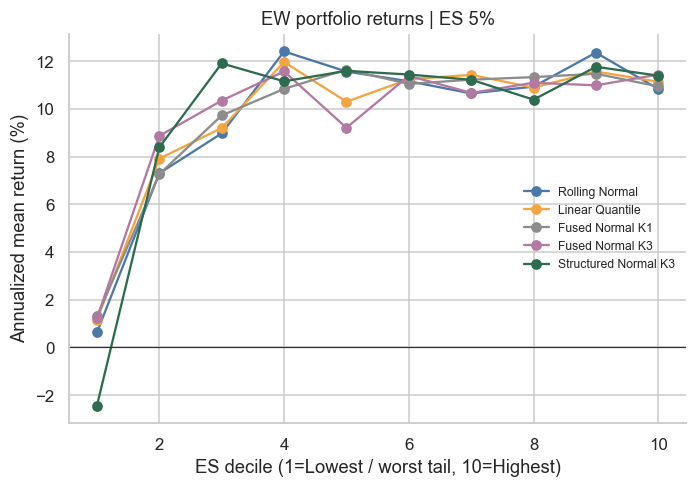

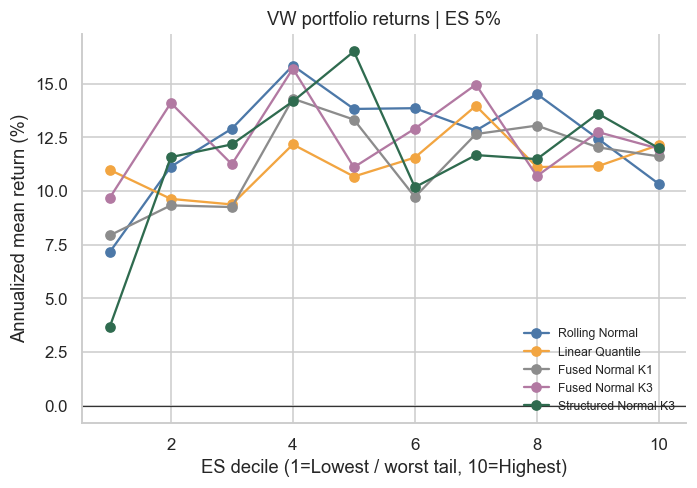

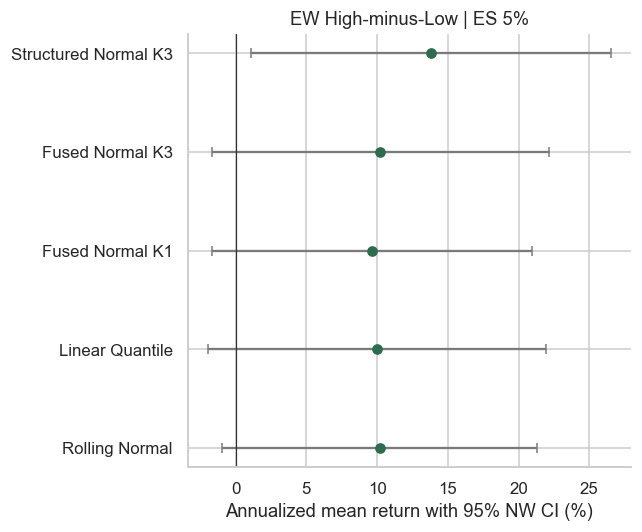

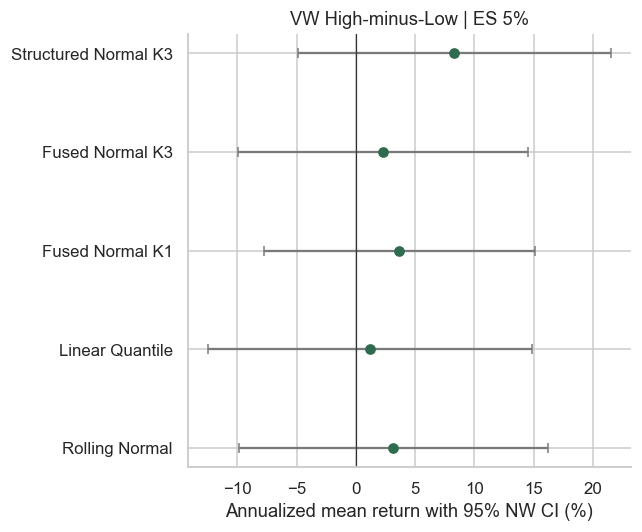

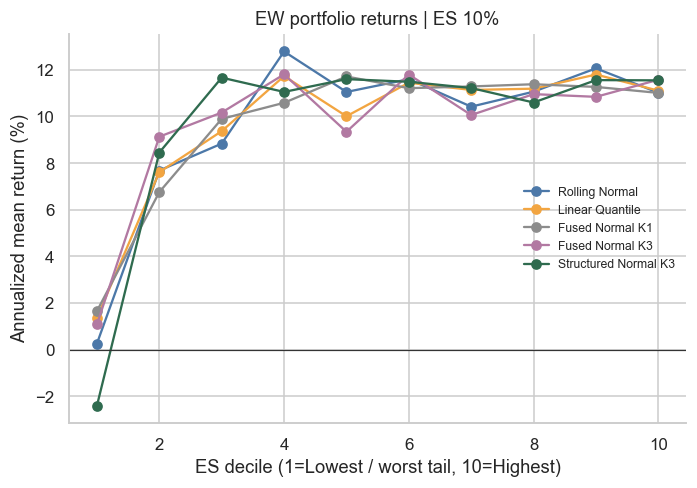

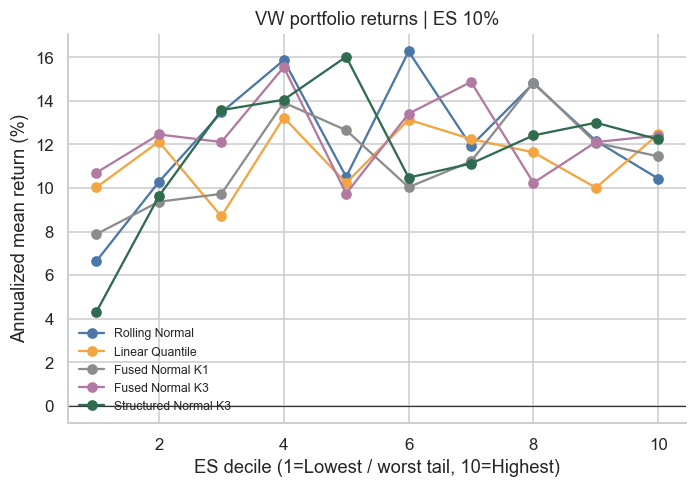

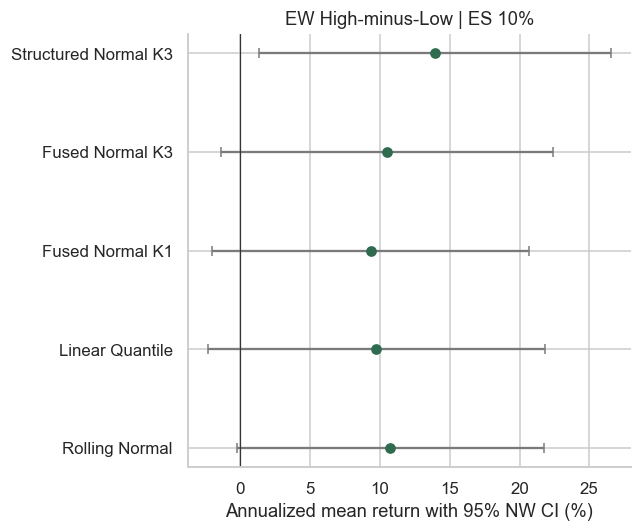

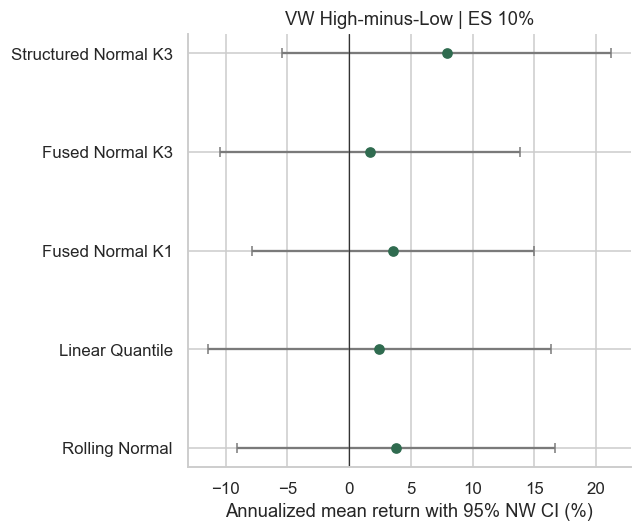

In [12]:
# ==========================================
# 4.2 图：组合单调性与 H-L 置信区间
# ==========================================

for alpha in alphas:
    print(f"ES alpha = {alpha * 100:g}%")
    primary_portfolios = primary_portfolios_by_alpha[alpha]
    primary_hml_summary = primary_hml_summary_by_alpha[alpha]
    portfolio_means = primary_portfolios.groupby(["model_id", "model_label", "portfolio"], as_index=False
    )[["ew_return", "vw_return"]].mean()


    # 分别生成 EW、VW 组合收益图
    for weighting in ["ew", "vw"]:
        fig, ax = plt.subplots(figsize=(6.5, 4.6))

        for model_id in model_order:
            data = portfolio_means[portfolio_means["model_id"] == model_id]
            ax.plot(data["portfolio"], 1200 * data[f"{weighting}_return"], marker="o",
                    color=model_colors[model_id], label=model_labels[model_id])

        ax.axhline(0, color="#333333", linewidth=0.8)
        ax.set(title=f"{weighting.upper()} portfolio returns | ES {alpha * 100:g}%",
            xlabel="ES decile (1=Lowest / worst tail, 10=Highest)",
               ylabel="Annualized mean return (%)")
        ax.legend(frameon=False, fontsize=8)

        # fig.suptitle(, y=1.03)
        fig.tight_layout()
        fig.savefig(figure_dir / f"fig01_model_portfolio_curves_{weighting}_alpha{alpha_suffix(alpha)}_{save_version}.pdf", dpi=220, bbox_inches="tight", pad_inches=0.02)
        # print(f"title={weighting.upper()} portfolio returns")
        # print(f"{alpha * 100:g}% return-ES portfolio returns: 2007–2024 signal months")
        # fig.show()


    # 分别生成 EW、VW High-minus-Low 置信区间图
    for weighting in ["EW", "VW"]:
        fig, ax = plt.subplots(figsize=(6, 5))

        data = primary_hml_summary[
            primary_hml_summary["weighting"] == weighting
        ].set_index("model_id").loc[model_order].reset_index()

        y = np.arange(len(data))

        ax.errorbar(
            data["annualized_mean_pct"], y,
            xerr=[data["annualized_mean_pct"] - data["annualized_ci_low_pct"],
                  data["annualized_ci_high_pct"] - data["annualized_mean_pct"]],
            fmt="o", color="#2F6B4F", ecolor="#7A7A7A", capsize=3,
        )

        ax.axvline(0, color="#333333", linewidth=0.8)
        ax.set(title=f"{weighting} High-minus-Low | ES {alpha * 100:g}%",
               xlabel="Annualized mean return with 95% NW CI (%)",
               yticks=y, yticklabels=data["model_label"])

        fig.tight_layout()
        fig.savefig(figure_dir / f"fig02_model_hml_intervals_{weighting.lower()}_alpha{alpha_suffix(alpha)}_{save_version}.pdf", dpi=220, bbox_inches="tight", pad_inches=0.02)
        # print(f"title={weighting} High-minus-Low")
        # print(f"Tail-risk premium across forecasting models")
        # fig.show()



ES alpha = 5%
ES alpha = 10%


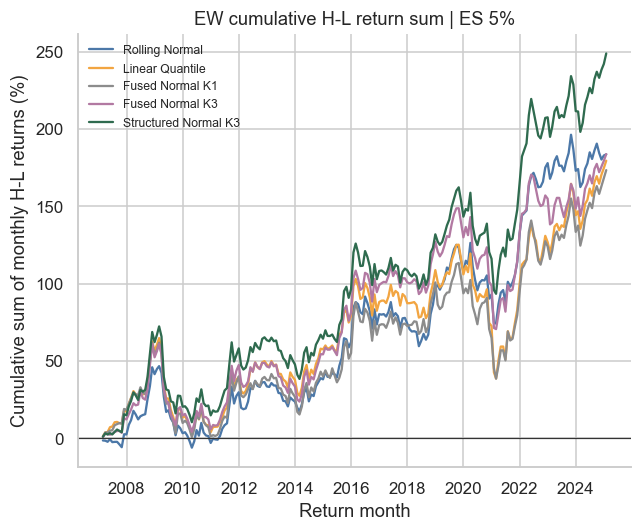

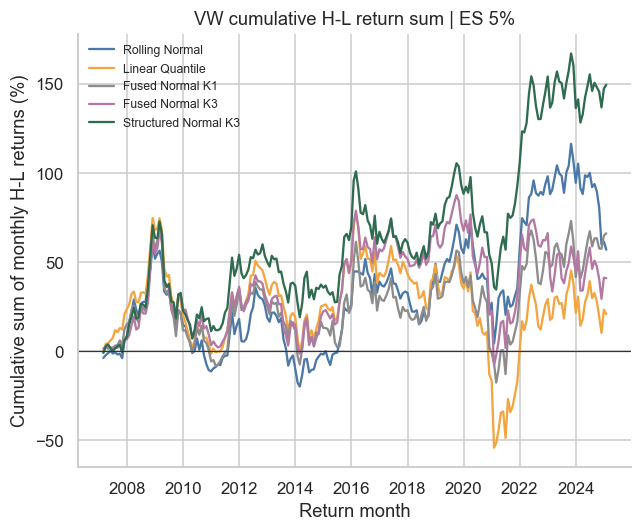

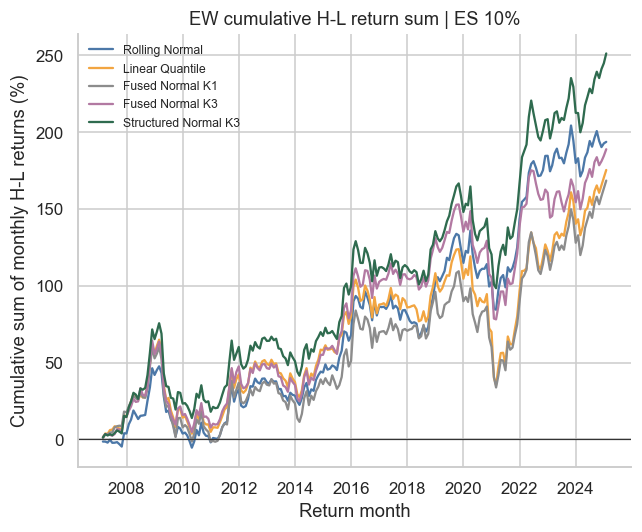

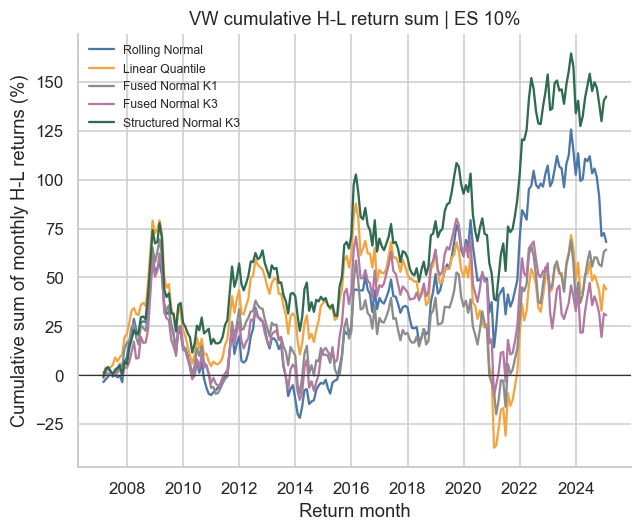

In [13]:
# ==========================================
# 4.3 图：H-L 累计收益和模型比较
# ==========================================

for alpha in alphas:
    print(f"ES alpha = {alpha * 100:g}%")
    primary_hml = primary_hml_by_alpha[alpha]
    for weighting in  ["EW", "VW"]:
        fig, ax = plt.subplots(figsize=(6, 5))
        for model_id in model_order:
            data = primary_hml[(primary_hml["model_id"] == model_id) & (primary_hml["weighting"] == weighting)].sort_values("return_date")
            ax.plot(data["return_date"], 100 * data["hml_return"].cumsum(), color=model_colors[model_id], label=model_labels[model_id])
        ax.axhline(0, color="#333333", linewidth=0.8)
        ax.set(
            title=f"{weighting} cumulative H-L return sum | ES {alpha * 100:g}%",
            xlabel="Return month", ylabel="Cumulative sum of monthly H-L returns (%)")
        ax.legend(frameon=False, fontsize=8)
        fig.tight_layout()
        fig.savefig(figure_dir / f"fig03_model_hml_cumulative_{weighting.lower()}_alpha{alpha_suffix(alpha)}_{save_version}.pdf", dpi=220, bbox_inches="tight", pad_inches=0.02)
        # print(f"title={weighting} cumulative H-L returns")
        # print("Cumulative High-ES minus Low-ES returns")
        # fig.show()



## 5. Structured ES 的经济分解

以下比较总 ES、adverse component 对总 ES 的精确贡献(contribution)，以及 adverse component 在总体 VaR 阈值以下的条件平均收益(severity)。`pi_adverse` 是同月共同变量，不能用于月内股票排序。

`contribution = tail_weight × severity`，各 component contribution 加总为总 ES；数值越低表示尾部收益越差。severity 保留历史列名，但不再表示正数损失额。


In [14]:
# ==========================================
# 5.1 Adverse contribution 与 severity 组合
# ==========================================
mechanism_specs_by_alpha = {}
full_portfolios_by_alpha = {}
full_hml_by_alpha = {}
full_hml_summary_by_alpha = {}
for alpha in alphas:
    print(f"ES alpha = {alpha * 100:g}%")
    primary_portfolios = primary_portfolios_by_alpha[alpha]
    primary_hml = primary_hml_by_alpha[alpha]
    primary_hml_summary = primary_hml_summary_by_alpha[alpha]
    mechanism_specs = {
        "Adverse contribution": f"es_contribution_adverse_{alpha_suffix(alpha)}",
        "Adverse severity": f"severity_adverse_{alpha_suffix(alpha)}",
    }
    mechanism_portfolio_parts, mechanism_hml_parts = [], []

    for signal_name, signal_col in mechanism_specs.items():
        portfolios = sort_portfolios(pricing_base, signal_col, PRIMARY_GROUPS, me_breakpoints, exclude_microcaps, breakpoint_universe=breakpoint_universe,)
        metadata = {
            "model_id": "structured_normal_k3", "model_label": model_labels["structured_normal_k3"], "signal_name": signal_name,
            "n_groups": PRIMARY_GROUPS, "exclude_microcaps": exclude_microcaps, "breakpoint_universe": breakpoint_universe,
        }
        for key, value in metadata.items():
            portfolios[key] = value
        mechanism_portfolio_parts.append(portfolios)
        mechanism_hml_parts.append(build_hml(portfolios, metadata))

    mechanism_portfolios = pd.concat(mechanism_portfolio_parts, ignore_index=True)
    mechanism_hml = pd.concat(mechanism_hml_parts, ignore_index=True)
    mechanism_hml_summary = summarize_hml(mechanism_hml)

    full_portfolios = pd.concat([primary_portfolios, mechanism_portfolios], ignore_index=True)
    full_hml = pd.concat([primary_hml, mechanism_hml], ignore_index=True)
    full_hml_summary = pd.concat([primary_hml_summary, mechanism_hml_summary], ignore_index=True)

    full_portfolios.to_parquet(result_dir / f"full_portfolios_{timestamp}_alpha{alpha_suffix(alpha)}.parquet", index=False)
    full_hml.to_parquet(result_dir / f"full_hml_{timestamp}_alpha{alpha_suffix(alpha)}.parquet", index=False)
    full_hml_summary.to_parquet(result_dir / f"full_hml_summary_{timestamp}_alpha{alpha_suffix(alpha)}.parquet", index=False)

    display(full_portfolios)
    display(full_hml)
    display(full_hml_summary)

    # structured_total_portfolios = primary_portfolios[primary_portfolios["model_id"] == "structured_normal_k3"].copy()
    # structured_total_hml = primary_hml[primary_hml["model_id"] == "structured_normal_k3"].copy()
    # structured_portfolios = pd.concat([structured_total_portfolios, mechanism_portfolios], ignore_index=True)
    # structured_hml = pd.concat([structured_total_hml, mechanism_hml], ignore_index=True)

    # display(pd.concat([structured_portfolios.head(),structured_portfolios.tail()]))
    # display(pd.concat([structured_hml.head(),structured_hml.tail()]))

    # display(pd.concat([
    #     primary_hml_summary[primary_hml_summary["model_id"] == "structured_normal_k3"],
    #     mechanism_hml_summary,
    # ], ignore_index=True)[["signal_name", "weighting", "annualized_mean_pct", "nw_t", "p_value"]].round(4))

    mechanism_specs_by_alpha[alpha] = mechanism_specs
    full_portfolios_by_alpha[alpha] = full_portfolios
    full_hml_by_alpha[alpha] = full_hml
    full_hml_summary_by_alpha[alpha] = full_hml_summary


ES alpha = 5%


,mthcaldt,return_date,portfolio,n_firms,mean_signal,ew_return,market_cap,vw_return,model_id,model_label,signal_name,n_groups,exclude_microcaps,breakpoint_universe
0,2007-01-31,2007-02-28,1,287,-0.595928,0.017230,2.420929e+08,0.021110,rolling_normal,Rolling Normal,Total ES (5%),10,False,All
1,2007-01-31,2007-02-28,2,287,-0.392734,-0.004648,3.753576e+08,-0.009861,rolling_normal,Rolling Normal,Total ES (5%),10,False,All
2,2007-01-31,2007-02-28,3,287,-0.334669,-0.000052,4.269339e+08,0.006575,rolling_normal,Rolling Normal,Total ES (5%),10,False,All
3,2007-01-31,2007-02-28,4,287,-0.291567,0.014194,8.089020e+08,-0.006283,rolling_normal,Rolling Normal,Total ES (5%),10,False,All
4,2007-01-31,2007-02-28,5,287,-0.255770,0.008539,8.286497e+08,-0.001963,rolling_normal,Rolling Normal,Total ES (5%),10,False,All
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15115,2024-12-31,2025-01-31,6,206,-0.177499,0.031787,4.281939e+09,-0.066529,structured_normal_k3,Structured Normal K3,Adverse severity,10,False,All
15116,2024-12-31,2025-01-31,7,205,-0.163713,0.033262,2.005423e+09,0.036040,structured_normal_k3,Structured Normal K3,Adverse severity,10,False,All
15117,2024-12-31,2025-01-31,8,205,-0.153978,0.030213,5.855641e+09,0.027083,structured_normal_k3,Structured Normal K3,Adverse severity,10,False,All
15118,2024-12-31,2025-01-31,9,205,-0.145246,0.037570,1.052158e+10,0.051688,structured_normal_k3,Structured Normal K3,Adverse severity,10,False,All


,mthcaldt,return_date,hml_return,weighting,model_id,model_label,signal_name,n_groups,exclude_microcaps,breakpoint_universe
0,2007-01-31,2007-02-28,-0.014480,EW,rolling_normal,Rolling Normal,Total ES (5%),10,False,All
1,2007-02-28,2007-03-31,-0.001418,EW,rolling_normal,Rolling Normal,Total ES (5%),10,False,All
2,2007-03-31,2007-04-30,-0.007034,EW,rolling_normal,Rolling Normal,Total ES (5%),10,False,All
3,2007-04-30,2007-05-31,0.016528,EW,rolling_normal,Rolling Normal,Total ES (5%),10,False,All
4,2007-05-31,2007-06-30,-0.018786,EW,rolling_normal,Rolling Normal,Total ES (5%),10,False,All
...,...,...,...,...,...,...,...,...,...,...
3019,2024-08-31,2024-09-30,-0.029105,VW,structured_normal_k3,Structured Normal K3,Adverse severity,10,False,All
3020,2024-09-30,2024-10-31,-0.080971,VW,structured_normal_k3,Structured Normal K3,Adverse severity,10,False,All
3021,2024-10-31,2024-11-30,-0.091789,VW,structured_normal_k3,Structured Normal K3,Adverse severity,10,False,All
3022,2024-11-30,2024-12-31,0.097116,VW,structured_normal_k3,Structured Normal K3,Adverse severity,10,False,All


,model_id,model_label,signal_name,weighting,n_groups,exclude_microcaps,breakpoint_universe,mean_monthly,nw_se,nw_t,p_value,ci_95_low,ci_95_high,months,annualized_mean_pct,annualized_ci_low_pct,annualized_ci_high_pct
0,fused_normal_k1,Fused Normal K1,Total ES (5%),EW,10,False,All,0.008030,0.004821,1.665675,0.095778,-0.001419,0.017478,216,9.635667,-1.702623,20.973957
1,fused_normal_k1,Fused Normal K1,Total ES (5%),VW,10,False,All,0.003066,0.004853,0.631705,0.527579,-0.006447,0.012579,216,3.679108,-7.736106,15.094322
2,fused_normal_k3,Fused Normal K3,Total ES (5%),EW,10,False,All,0.008510,0.005066,1.679849,0.092987,-0.001419,0.018439,216,10.212092,-1.703088,22.127273
3,fused_normal_k3,Fused Normal K3,Total ES (5%),VW,10,False,All,0.001902,0.005200,0.365788,0.714523,-0.008289,0.012093,216,2.282308,-9.946982,14.511598
4,linear_quantile,Linear Quantile,Total ES (5%),EW,10,False,All,0.008312,0.005082,1.635689,0.101905,-0.001648,0.018272,216,9.974276,-1.977617,21.926169
5,linear_quantile,Linear Quantile,Total ES (5%),VW,10,False,All,0.000969,0.005807,0.166848,0.867490,-0.010412,0.012350,216,1.162568,-12.494409,14.819544
6,rolling_normal,Rolling Normal,Total ES (5%),EW,10,False,All,0.008502,0.004734,1.795923,0.072507,-0.000777,0.017782,216,10.202873,-0.932143,21.337889
7,rolling_normal,Rolling Normal,Total ES (5%),VW,10,False,All,0.002640,0.005541,0.476390,0.633796,-0.008221,0.013501,216,3.167814,-9.865434,16.201063
8,structured_normal_k3,Structured Normal K3,Total ES (5%),EW,10,False,All,0.011524,0.005411,2.129583,0.033206,0.000918,0.022130,216,13.828609,1.101202,26.556016
9,structured_normal_k3,Structured Normal K3,Total ES (5%),VW,10,False,All,0.006927,0.005623,1.231900,0.217987,-0.004094,0.017947,216,8.311987,-4.912706,21.536681


ES alpha = 10%


,mthcaldt,return_date,portfolio,n_firms,mean_signal,ew_return,market_cap,vw_return,model_id,model_label,signal_name,n_groups,exclude_microcaps,breakpoint_universe
0,2007-01-31,2007-02-28,1,287,-0.498512,0.015403,2.458294e+08,0.019654,rolling_normal,Rolling Normal,Total ES (10%),10,False,All
1,2007-01-31,2007-02-28,2,287,-0.330116,-0.005509,3.713619e+08,-0.010154,rolling_normal,Rolling Normal,Total ES (10%),10,False,All
2,2007-01-31,2007-02-28,3,287,-0.280647,0.002432,4.805910e+08,0.008914,rolling_normal,Rolling Normal,Total ES (10%),10,False,All
3,2007-01-31,2007-02-28,4,287,-0.244396,0.013930,9.235806e+08,-0.011002,rolling_normal,Rolling Normal,Total ES (10%),10,False,All
4,2007-01-31,2007-02-28,5,287,-0.213879,0.006531,7.503743e+08,-0.004591,rolling_normal,Rolling Normal,Total ES (10%),10,False,All
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15115,2024-12-31,2025-01-31,6,206,-0.148792,0.031315,4.270938e+09,-0.067301,structured_normal_k3,Structured Normal K3,Adverse severity,10,False,All
15116,2024-12-31,2025-01-31,7,205,-0.136725,0.031965,1.996447e+09,0.035987,structured_normal_k3,Structured Normal K3,Adverse severity,10,False,All
15117,2024-12-31,2025-01-31,8,205,-0.128158,0.031883,6.000423e+09,0.027463,structured_normal_k3,Structured Normal K3,Adverse severity,10,False,All
15118,2024-12-31,2025-01-31,9,205,-0.120425,0.038522,1.035915e+10,0.054103,structured_normal_k3,Structured Normal K3,Adverse severity,10,False,All


,mthcaldt,return_date,hml_return,weighting,model_id,model_label,signal_name,n_groups,exclude_microcaps,breakpoint_universe
0,2007-01-31,2007-02-28,-0.013708,EW,rolling_normal,Rolling Normal,Total ES (10%),10,False,All
1,2007-02-28,2007-03-31,-0.000363,EW,rolling_normal,Rolling Normal,Total ES (10%),10,False,All
2,2007-03-31,2007-04-30,-0.006502,EW,rolling_normal,Rolling Normal,Total ES (10%),10,False,All
3,2007-04-30,2007-05-31,0.018556,EW,rolling_normal,Rolling Normal,Total ES (10%),10,False,All
4,2007-05-31,2007-06-30,-0.019893,EW,rolling_normal,Rolling Normal,Total ES (10%),10,False,All
...,...,...,...,...,...,...,...,...,...,...
3019,2024-08-31,2024-09-30,-0.029734,VW,structured_normal_k3,Structured Normal K3,Adverse severity,10,False,All
3020,2024-09-30,2024-10-31,-0.084377,VW,structured_normal_k3,Structured Normal K3,Adverse severity,10,False,All
3021,2024-10-31,2024-11-30,-0.093787,VW,structured_normal_k3,Structured Normal K3,Adverse severity,10,False,All
3022,2024-11-30,2024-12-31,0.099513,VW,structured_normal_k3,Structured Normal K3,Adverse severity,10,False,All


,model_id,model_label,signal_name,weighting,n_groups,exclude_microcaps,breakpoint_universe,mean_monthly,nw_se,nw_t,p_value,ci_95_low,ci_95_high,months,annualized_mean_pct,annualized_ci_low_pct,annualized_ci_high_pct
0,fused_normal_k1,Fused Normal K1,Total ES (10%),EW,10,False,All,0.007801,0.004818,1.619238,0.105396,-0.001642,0.017243,216,9.360878,-1.969961,20.691717
1,fused_normal_k1,Fused Normal K1,Total ES (10%),VW,10,False,All,0.002975,0.004861,0.612046,0.540507,-0.006553,0.012503,216,3.570331,-7.863204,15.003867
2,fused_normal_k3,Fused Normal K3,Total ES (10%),EW,10,False,All,0.008745,0.005046,1.732936,0.083107,-0.001146,0.018636,216,10.493992,-1.375012,22.362997
3,fused_normal_k3,Fused Normal K3,Total ES (10%),VW,10,False,All,0.001419,0.005149,0.275609,0.782848,-0.008673,0.011511,216,1.702937,-10.407522,13.813396
4,linear_quantile,Linear Quantile,Total ES (10%),EW,10,False,All,0.008120,0.005124,1.584666,0.113042,-0.001923,0.018164,216,9.744269,-2.307968,21.796505
5,linear_quantile,Linear Quantile,Total ES (10%),VW,10,False,All,0.002031,0.005901,0.344202,0.730695,-0.009536,0.013598,216,2.437561,-11.442727,16.317848
6,rolling_normal,Rolling Normal,Total ES (10%),EW,10,False,All,0.008968,0.004662,1.923556,0.054410,-0.000170,0.018106,216,10.761710,-0.203895,21.727315
7,rolling_normal,Rolling Normal,Total ES (10%),VW,10,False,All,0.003153,0.005468,0.576586,0.564219,-0.007564,0.013869,216,3.783036,-9.076717,16.642789
8,structured_normal_k3,Structured Normal K3,Total ES (10%),EW,10,False,All,0.011631,0.005359,2.170470,0.029971,0.001128,0.022135,216,13.957728,1.353478,26.561978
9,structured_normal_k3,Structured Normal K3,Total ES (10%),VW,10,False,All,0.006599,0.005658,1.166240,0.243518,-0.004491,0.017688,216,7.918264,-5.389289,21.225817


ES alpha = 5%
ES alpha = 10%


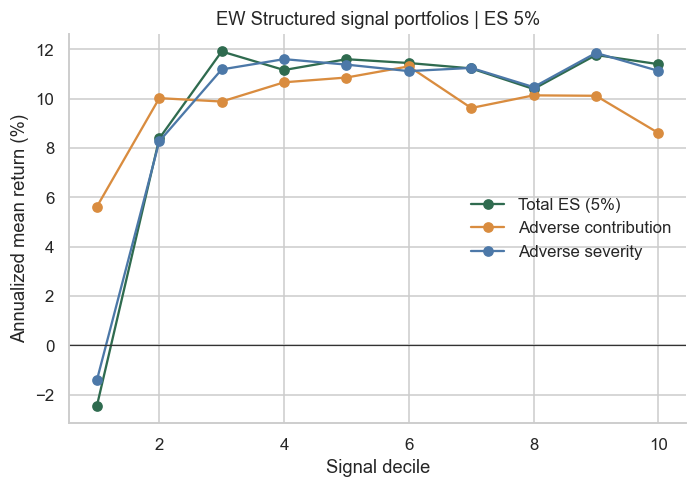

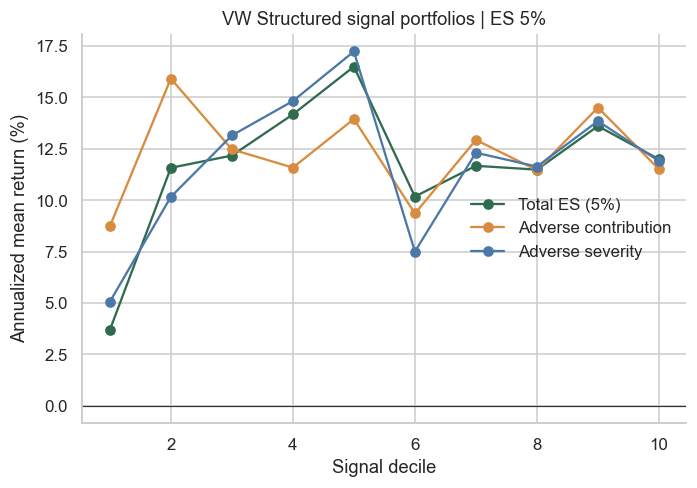

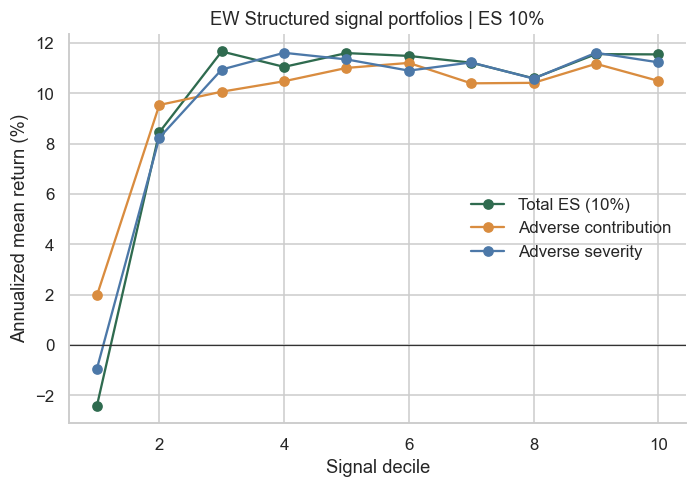

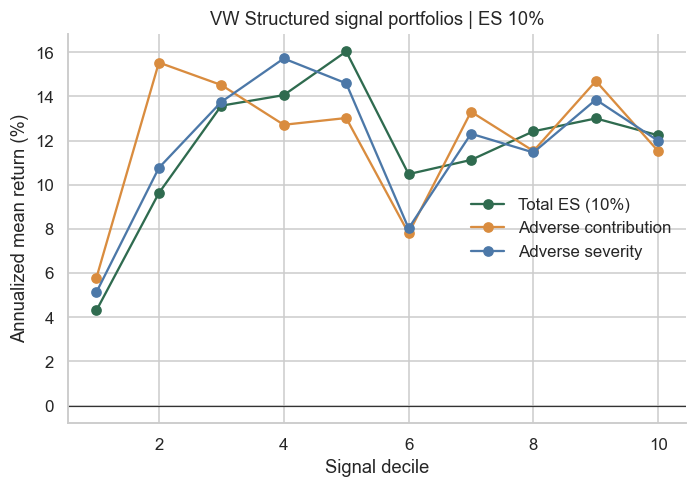

In [15]:
# ==========================================
# 5.2 图：Structured signals 的组合收益与相关性
# ==========================================
for alpha in alphas:
    print(f"ES alpha = {alpha * 100:g}%")
    full_portfolios = full_portfolios_by_alpha[alpha]
    structured_portfolios = full_portfolios[full_portfolios["model_id"] == "structured_normal_k3"].copy()
    structured_means = structured_portfolios.groupby(["signal_name", "portfolio"], as_index=False)[["ew_return", "vw_return"]].mean()

    for weighting in  ["ew", "vw"]:
        fig, ax = plt.subplots(figsize=(6.5, 4.6))
        for signal_name in [f"Total ES ({alpha * 100:g}%)", *mechanism_specs_by_alpha[alpha]]:
            data = structured_means[structured_means["signal_name"] == signal_name]
            ax.plot(data["portfolio"], 1200 * data[f"{weighting}_return"], marker="o",
                    color=signal_colors[signal_name], label=signal_name)
        ax.axhline(0, color="#333333", linewidth=0.8)
        ax.set(title=f"{weighting.upper()} Structured signal portfolios | ES {alpha * 100:g}%", xlabel="Signal decile", ylabel="Annualized mean return (%)")
        ax.legend(frameon=False)
        fig.tight_layout()
        fig.savefig(figure_dir / f"fig04_structured_signal_portfolios_{weighting}_alpha{alpha_suffix(alpha)}_{save_version}.pdf", dpi=220, bbox_inches="tight", pad_inches=0.02)



ES alpha = 5%
ES alpha = 10%


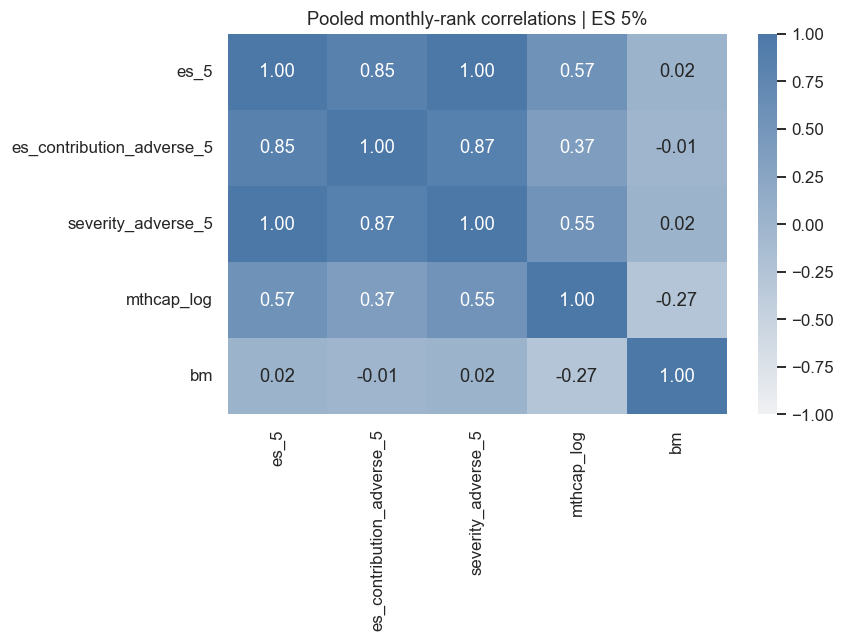

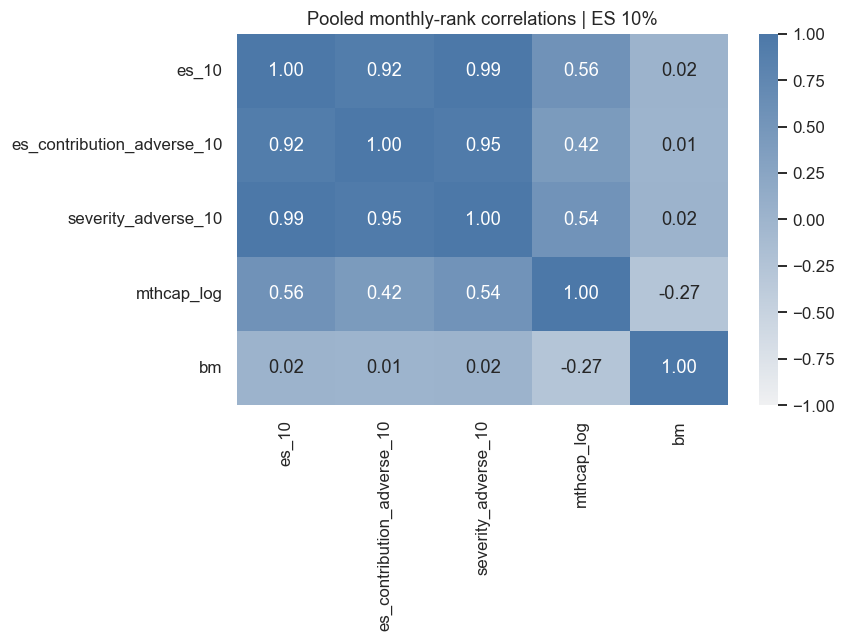

In [16]:
# ==========================================
# 5.3 图：Structured signals 的相关性热图, 基于排名计算相关性
# ==========================================
for alpha in alphas:
    print(f"ES alpha = {alpha * 100:g}%")
    corr_cols = [f"es_{alpha_suffix(alpha)}", f"es_contribution_adverse_{alpha_suffix(alpha)}", f"severity_adverse_{alpha_suffix(alpha)}", "mthcap_log", "bm"]
    ranked = pricing_base.groupby("mthcaldt")[corr_cols].rank(pct=True)
    signal_correlation = ranked.corr()

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(signal_correlation, annot=True, fmt=".2f", cmap=sns.light_palette("#4C78A8", as_cmap=True), vmin=-1, vmax=1, ax=ax)
    ax.set_title(f"Pooled monthly-rank correlations | ES {alpha * 100:g}%")
    fig.tight_layout()
    fig.savefig(figure_dir / f"fig05_signal_correlation_alpha{alpha_suffix(alpha)}_{save_version}.pdf", dpi=220, bbox_inches="tight", pad_inches=0.02)



ES alpha = 5%
ES alpha = 10%


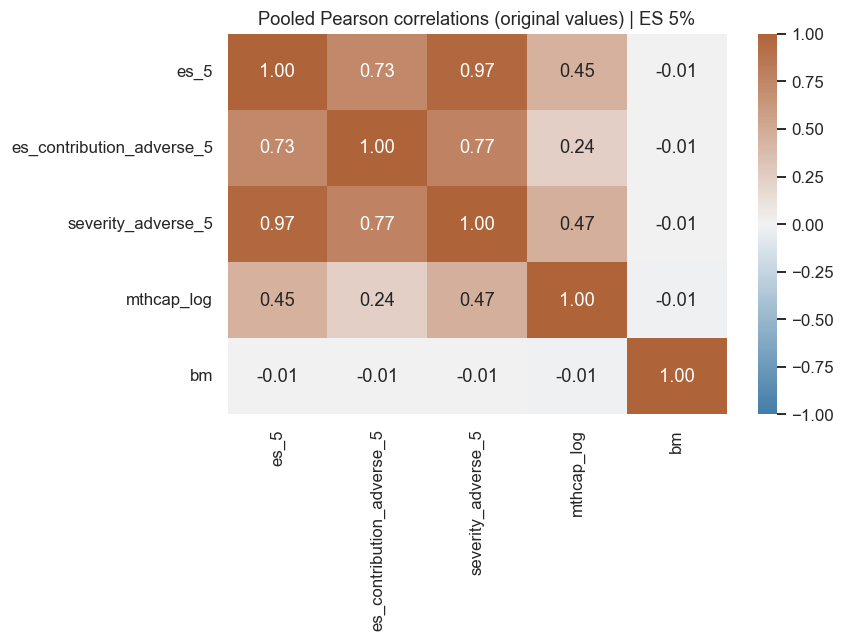

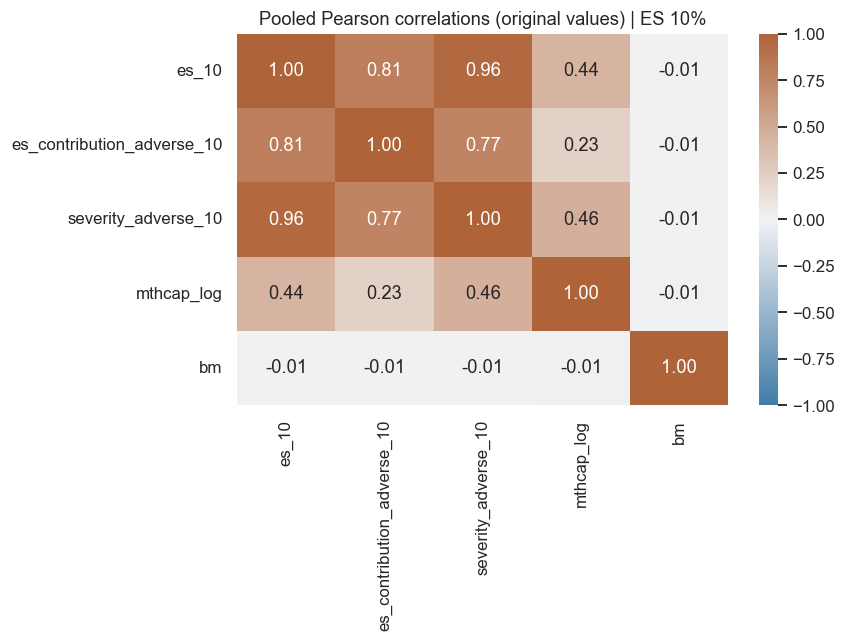

In [17]:
# ==========================================
# 5.3 图：Structured signals 的相关性热图，基于原始数值
# ==========================================
for alpha in alphas:
    print(f"ES alpha = {alpha * 100:g}%")
    corr_cols = [
        f"es_{alpha_suffix(alpha)}",
        f"es_contribution_adverse_{alpha_suffix(alpha)}",
        f"severity_adverse_{alpha_suffix(alpha)}",
        "mthcap_log",
        "bm",
    ]
    signal_correlation = (
        pricing_base[corr_cols]
        .replace([np.inf, -np.inf], np.nan)
        .corr(method="pearson")
    )

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(
        signal_correlation,
        annot=True,
        fmt=".2f",
        cmap=sns.diverging_palette(240, 30, as_cmap=True),
        center=0,
        vmin=-1,
        vmax=1,
        ax=ax,
    )
    ax.set_title(
        f"Pooled Pearson correlations (original values) | ES {alpha * 100:g}%"
    )
    fig.tight_layout()
    fig.savefig(
        figure_dir / f"fig05_signal_correlation_alpha{alpha_suffix(alpha)}_{save_version}.pdf",
        dpi=220,
        bbox_inches="tight",
        pad_inches=0.02,
    )

## 6. 因子调整 alpha

H–L 是零成本组合，因此不减 risk-free rate。组合收益使用下一月日期与 CAPM、FF3、Carhart4、FF5 和 FF5+Momentum 因子对齐。

In [18]:
# ==========================================
# 6.1 H-L factor regressions
# ==========================================
factor_alphas_by_alpha = {}
factor_coefficients_by_alpha = {}
for alpha in alphas:
    print(f"ES alpha = {alpha * 100:g}%")
    full_hml = full_hml_by_alpha[alpha]
    factor_models = {
        "CAPM": ["mktrf_ff3"],
        "FF3": ["mktrf_ff3", "smb_ff3", "hml_ff3"],
        "Carhart4": ["mktrf_ff3", "smb_ff3", "hml_ff3", "umd_ff3"],
        "FF5": ["mktrf_ff5", "smb_ff5", "hml_ff5", "rmw_ff5", "cma_ff5"],
        "FF5+MOM": ["mktrf_ff5", "smb_ff5", "hml_ff5", "rmw_ff5", "cma_ff5", "umd_ff5"],
    }


    def run_factor_regressions(hml):
        alpha_rows, coefficient_rows = [], []
        group_cols = ["model_id", "model_label", "signal_name", "weighting"]
        for keys, group in hml.groupby(group_cols):
            data = group.merge(factor_data, on="return_date", how="inner")
            for specification, factors in factor_models.items():
                regression = data[["hml_return"] + factors].dropna()
                fit = sm.OLS(regression["hml_return"], sm.add_constant(regression[factors])).fit(
                    cov_type="HAC", cov_kwds={"maxlags": min(NW_LAGS, len(regression) - 1)}
                )
                ci = fit.conf_int().loc["const"]
                row = dict(zip(group_cols, keys))
                row.update({
                    "specification": specification, "alpha_monthly": fit.params["const"],
                    "alpha_annualized_pct": 1200 * fit.params["const"], "nw_t": fit.tvalues["const"],
                    "p_value": fit.pvalues["const"], "ci_95_low_pct": 1200 * ci.iloc[0],
                    "ci_95_high_pct": 1200 * ci.iloc[1], "r_squared": fit.rsquared, "months": int(fit.nobs),
                })
                alpha_rows.append(row)
                for parameter in fit.params.index:
                    coefficient_rows.append({**row, "parameter": parameter, "coefficient": fit.params[parameter], "parameter_t": fit.tvalues[parameter]})
        return pd.DataFrame(alpha_rows), pd.DataFrame(coefficient_rows)

    factor_alphas, factor_coefficients = run_factor_regressions(full_hml)
    # display(factor_alphas[factor_alphas["specification"] == "FF5+MOM"][[
    #     "model_label", "signal_name", "weighting", "alpha_annualized_pct", "nw_t", "p_value", "months"
    # ]].round(4))

    # display(factor_alphas[[
    #     "model_label", "signal_name", "specification", "weighting", "alpha_annualized_pct", "nw_t", "p_value", "months"
    # ]].round(4))

    factor_alphas.to_parquet(result_dir / f"factor_alphas_{timestamp}_alpha{alpha_suffix(alpha)}.parquet", index=False)
    factor_coefficients.to_parquet(result_dir / f"factor_coefficients_{timestamp}_alpha{alpha_suffix(alpha)}.parquet", index=False)

    display(factor_alphas)
    display(factor_coefficients)

    factor_alphas_by_alpha[alpha] = factor_alphas
    factor_coefficients_by_alpha[alpha] = factor_coefficients


ES alpha = 5%


,model_id,model_label,signal_name,weighting,specification,alpha_monthly,alpha_annualized_pct,nw_t,p_value,ci_95_low_pct,ci_95_high_pct,r_squared,months
0,fused_normal_k1,Fused Normal K1,Total ES (5%),EW,CAPM,0.014454,17.345167,3.576241,0.000349,7.839123,26.851211,0.239817,216
1,fused_normal_k1,Fused Normal K1,Total ES (5%),EW,FF3,0.011909,14.291388,4.582793,0.000005,8.179262,20.403514,0.594706,216
2,fused_normal_k1,Fused Normal K1,Total ES (5%),EW,Carhart4,0.011320,13.584428,4.517384,0.000006,7.690532,19.478324,0.608863,216
3,fused_normal_k1,Fused Normal K1,Total ES (5%),EW,FF5,0.006666,7.999677,2.577647,0.009948,1.916968,14.082387,0.708551,216
4,fused_normal_k1,Fused Normal K1,Total ES (5%),EW,FF5+MOM,0.006137,7.364487,2.561593,0.010419,1.729663,12.999312,0.722220,216
...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,structured_normal_k3,Structured Normal K3,Total ES (5%),VW,CAPM,0.014553,17.464019,3.349269,0.000810,7.244223,27.683816,0.283097,216
66,structured_normal_k3,Structured Normal K3,Total ES (5%),VW,FF3,0.011919,14.302605,3.500135,0.000465,6.293602,22.311608,0.643067,216
67,structured_normal_k3,Structured Normal K3,Total ES (5%),VW,Carhart4,0.011116,13.339707,3.314815,0.000917,5.452284,21.227129,0.665066,216
68,structured_normal_k3,Structured Normal K3,Total ES (5%),VW,FF5,0.006080,7.295786,2.349502,0.018799,1.209613,13.381958,0.754641,216


,model_id,model_label,signal_name,weighting,specification,alpha_monthly,alpha_annualized_pct,nw_t,p_value,ci_95_low_pct,ci_95_high_pct,r_squared,months,parameter,coefficient,parameter_t
0,fused_normal_k1,Fused Normal K1,Total ES (5%),EW,CAPM,0.014454,17.345167,3.576241,0.000349,7.839123,26.851211,0.239817,216,const,0.014454,3.576241
1,fused_normal_k1,Fused Normal K1,Total ES (5%),EW,CAPM,0.014454,17.345167,3.576241,0.000349,7.839123,26.851211,0.239817,216,mktrf_ff3,-0.763275,-6.805862
2,fused_normal_k1,Fused Normal K1,Total ES (5%),EW,FF3,0.011909,14.291388,4.582793,0.000005,8.179262,20.403514,0.594706,216,const,0.011909,4.582793
3,fused_normal_k1,Fused Normal K1,Total ES (5%),EW,FF3,0.011909,14.291388,4.582793,0.000005,8.179262,20.403514,0.594706,216,mktrf_ff3,-0.471687,-4.347354
4,fused_normal_k1,Fused Normal K1,Total ES (5%),EW,FF3,0.011909,14.291388,4.582793,0.000005,8.179262,20.403514,0.594706,216,smb_ff3,-1.804285,-9.833169
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
331,structured_normal_k3,Structured Normal K3,Total ES (5%),VW,FF5+MOM,0.005397,6.475926,2.128500,0.033296,0.512769,12.439083,0.773716,216,smb_ff5,-1.458992,-13.686297
332,structured_normal_k3,Structured Normal K3,Total ES (5%),VW,FF5+MOM,0.005397,6.475926,2.128500,0.033296,0.512769,12.439083,0.773716,216,hml_ff5,0.488429,4.352179
333,structured_normal_k3,Structured Normal K3,Total ES (5%),VW,FF5+MOM,0.005397,6.475926,2.128500,0.033296,0.512769,12.439083,0.773716,216,rmw_ff5,1.462127,8.972969
334,structured_normal_k3,Structured Normal K3,Total ES (5%),VW,FF5+MOM,0.005397,6.475926,2.128500,0.033296,0.512769,12.439083,0.773716,216,cma_ff5,0.332184,1.846476


ES alpha = 10%


,model_id,model_label,signal_name,weighting,specification,alpha_monthly,alpha_annualized_pct,nw_t,p_value,ci_95_low_pct,ci_95_high_pct,r_squared,months
0,fused_normal_k1,Fused Normal K1,Total ES (10%),EW,CAPM,0.014201,17.041020,3.517710,0.000435,7.546268,26.535772,0.239741,216
1,fused_normal_k1,Fused Normal K1,Total ES (10%),EW,FF3,0.011667,14.000016,4.528435,0.000006,7.940632,20.059401,0.594790,216
2,fused_normal_k1,Fused Normal K1,Total ES (10%),EW,Carhart4,0.011104,13.324801,4.468304,0.000008,7.480048,19.169554,0.607798,216
3,fused_normal_k1,Fused Normal K1,Total ES (10%),EW,FF5,0.006420,7.704142,2.498582,0.012469,1.660779,13.747505,0.711080,216
4,fused_normal_k1,Fused Normal K1,Total ES (10%),EW,FF5+MOM,0.005912,7.094224,2.485120,0.012951,1.499152,12.689295,0.723775,216
...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,structured_normal_k3,Structured Normal K3,Total ES (10%),VW,CAPM,0.014284,17.141097,3.375649,0.000736,7.188661,27.093532,0.280677,216
66,structured_normal_k3,Structured Normal K3,Total ES (10%),VW,FF3,0.011656,13.987581,3.450868,0.000559,6.043159,21.932002,0.638005,216
67,structured_normal_k3,Structured Normal K3,Total ES (10%),VW,Carhart4,0.010865,13.038208,3.250255,0.001153,5.175927,20.900488,0.658883,216
68,structured_normal_k3,Structured Normal K3,Total ES (10%),VW,FF5,0.005864,7.036500,2.315552,0.020583,1.080560,12.992440,0.745453,216


,model_id,model_label,signal_name,weighting,specification,alpha_monthly,alpha_annualized_pct,nw_t,p_value,ci_95_low_pct,ci_95_high_pct,r_squared,months,parameter,coefficient,parameter_t
0,fused_normal_k1,Fused Normal K1,Total ES (10%),EW,CAPM,0.014201,17.041020,3.517710,0.000435,7.546268,26.535772,0.239741,216,const,0.014201,3.517710
1,fused_normal_k1,Fused Normal K1,Total ES (10%),EW,CAPM,0.014201,17.041020,3.517710,0.000435,7.546268,26.535772,0.239741,216,mktrf_ff3,-0.760368,-6.854880
2,fused_normal_k1,Fused Normal K1,Total ES (10%),EW,FF3,0.011667,14.000016,4.528435,0.000006,7.940632,20.059401,0.594790,216,const,0.011667,4.528435
3,fused_normal_k1,Fused Normal K1,Total ES (10%),EW,FF3,0.011667,14.000016,4.528435,0.000006,7.940632,20.059401,0.594790,216,mktrf_ff3,-0.469867,-4.383377
4,fused_normal_k1,Fused Normal K1,Total ES (10%),EW,FF3,0.011667,14.000016,4.528435,0.000006,7.940632,20.059401,0.594790,216,smb_ff3,-1.798033,-9.980250
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
331,structured_normal_k3,Structured Normal K3,Total ES (10%),VW,FF5+MOM,0.005176,6.211305,2.040372,0.041313,0.244778,12.177832,0.764320,216,smb_ff5,-1.472480,-13.299720
332,structured_normal_k3,Structured Normal K3,Total ES (10%),VW,FF5+MOM,0.005176,6.211305,2.040372,0.041313,0.244778,12.177832,0.764320,216,hml_ff5,0.533705,4.705716
333,structured_normal_k3,Structured Normal K3,Total ES (10%),VW,FF5+MOM,0.005176,6.211305,2.040372,0.041313,0.244778,12.177832,0.764320,216,rmw_ff5,1.479256,8.434222
334,structured_normal_k3,Structured Normal K3,Total ES (10%),VW,FF5+MOM,0.005176,6.211305,2.040372,0.041313,0.244778,12.177832,0.764320,216,cma_ff5,0.251272,1.315836


ES alpha = 5%
ES alpha = 10%


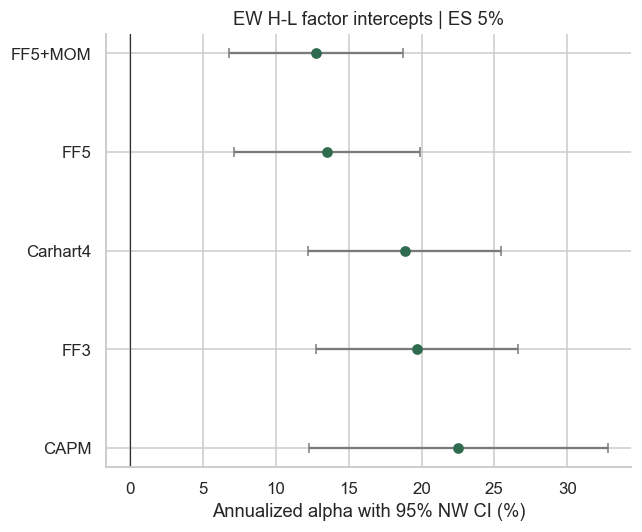

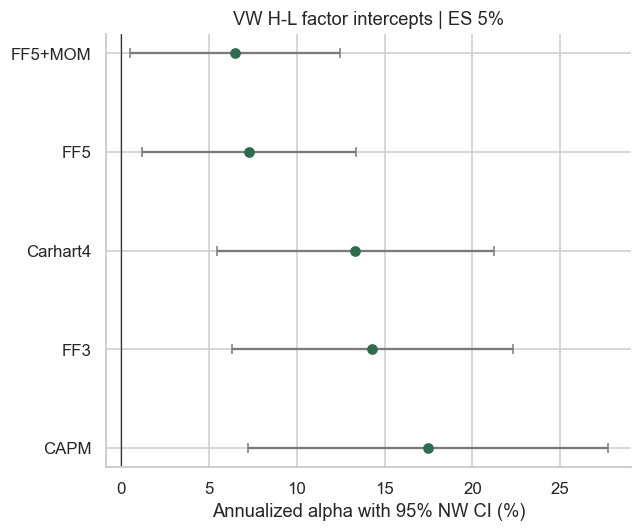

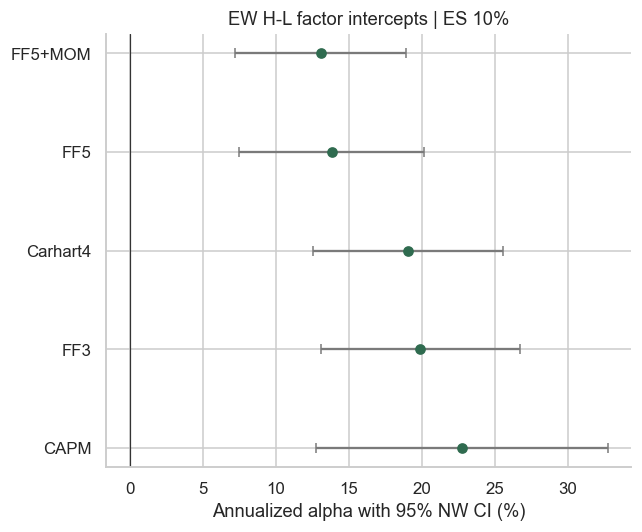

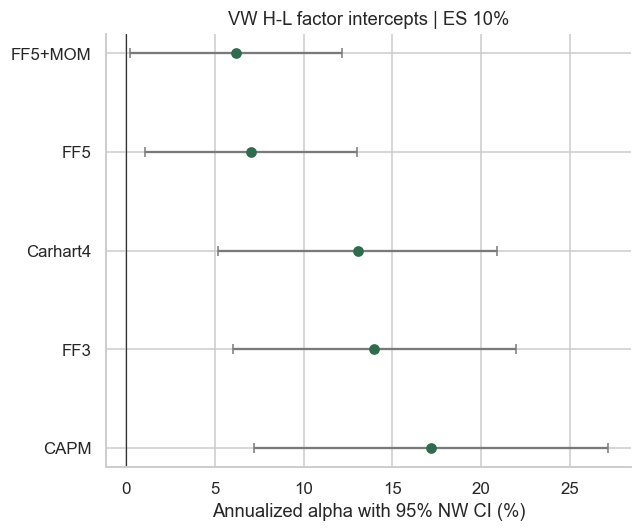

In [19]:
# ==========================================
# draw a specific model over all factor model
# =========================================
for alpha in alphas:
    print(f"ES alpha = {alpha * 100:g}%")
    factor_alphas = factor_alphas_by_alpha[alpha]
    factor_coefficients = factor_coefficients_by_alpha[alpha]
    model_id_to_draw = "structured_normal_k3"
    signal_name_to_draw = f"Total ES ({alpha * 100:g}%)"
    factor_alphas_draw = factor_alphas[
        (factor_alphas["model_id"] == model_id_to_draw) & (factor_alphas["signal_name"] == signal_name_to_draw)
    ].copy()
    for  weighting in  ["EW", "VW"]:
        fig, ax = plt.subplots(figsize=(6, 5))
        data = factor_alphas_draw[factor_alphas_draw["weighting"] == weighting]
        ax.errorbar(
            data["alpha_annualized_pct"], data["specification"],
            xerr=[data["alpha_annualized_pct"] - data["ci_95_low_pct"], data["ci_95_high_pct"] - data["alpha_annualized_pct"]],
            fmt="o", color="#2F6B4F", ecolor="#7A7A7A", capsize=3,
        )
        ax.axvline(0, color="#333333", linewidth=0.8)
        ax.set(title=f"{weighting} H-L factor intercepts | ES {alpha * 100:g}%",
               xlabel="Annualized alpha with 95% NW CI (%)")
        fig.tight_layout()
        fig.savefig(figure_dir / f"fig06_factor_model_alpha_{weighting.lower()}_{model_id_to_draw}_alpha{alpha_suffix(alpha)}_{save_version}.pdf", dpi=220, bbox_inches="tight", pad_inches=0.02)


    # ==========================================
    # generate a summary table for a specific factor model
    # ==========================================
    factor_coefficients_draw = factor_coefficients[
        (factor_coefficients["model_id"] == model_id_to_draw) & (factor_coefficients["signal_name"] == signal_name_to_draw)
    ].copy()



In [20]:
for alpha in alphas:
    print(f"ES alpha = {alpha * 100:g}%")
    factor_coefficients = factor_coefficients_by_alpha[alpha]
    signal_name_to_draw = f"Total ES ({alpha * 100:g}%)"
    # ==========================================
    # generate a summary table for a specific factor model
    # ==========================================
    factor_coefficients_draw = factor_coefficients[
        (factor_coefficients["model_id"] == model_id_to_draw) & (factor_coefficients["signal_name"] == signal_name_to_draw)
    ].copy()
    # 删除parameter后面的_的后缀
    factor_coefficients_draw["parameter"] = factor_coefficients_draw["parameter"].str.replace(r"_(ff3|ff5)$", "", regex=True)
    factor_coefficients_draw


    def create_simple_table(df, weight):
        # 1. 过滤数据
        df_w = df[df['weighting'] == weight].copy()
    
        # 2. 拼接成 "系数 (t值)" 的格式
        df_w['coef_t'] = df_w.apply(lambda row: f"{row['coefficient']:.4f} ({row['parameter_t']:.2f})", axis=1)
    
        # 3. 核心一步：长表转宽表 (行是因子，列是模型)
        table = df_w.pivot(index='parameter', columns='specification', values='coef_t')
    
        # 4. 把 R-squared 作为新的一行加在最下面
        r2 = df_w.groupby('specification')['r_squared'].first().apply(lambda x: f"{x:.4f}")
        table.loc['R-squared'] = r2
    
        # 5. 排一下列的顺序，并把没数据的地方填成空白
        ordered_cols = ['CAPM', 'FF3', 'Carhart4', 'FF5', 'FF5+MOM']
        table = table.reindex(columns=ordered_cols).fillna("")
    
        return table

    # 生成表格
    parameter_order = ['const', 'mktrf', 'smb', 'hml', 'rmw', 'cma', 'umd', 'R-squared']
    ew_table = create_simple_table(factor_coefficients_draw, 'EW')
    vw_table = create_simple_table(factor_coefficients_draw, 'VW')
    # sort parameter by parameter_order
    ew_table.sort_index(key=lambda x: [parameter_order.index(i) for i in x], inplace=True)
    vw_table.sort_index(key=lambda x: [parameter_order.index(i) for i in x], inplace=True)

    display(ew_table)
    display(vw_table)

    ew_table.to_parquet(result_dir / f"factor_coefficients_ew_table_{model_id_to_draw}_{timestamp}_alpha{alpha_suffix(alpha)}.parquet", index=True)
    vw_table.to_parquet(result_dir / f"factor_coefficients_vw_table_{model_id_to_draw}_{timestamp}_alpha{alpha_suffix(alpha)}.parquet", index=True)



ES alpha = 5%


specification,CAPM,FF3,Carhart4,FF5,FF5+MOM
parameter,,,,,
const,0.0188 (4.30),0.0164 (5.56),0.0157 (5.55),0.0113 (4.14),0.0106 (4.21)
mktrf,-0.8596 (-7.89),-0.5751 (-5.32),-0.4996 (-4.90),-0.4983 (-5.57),-0.4351 (-4.83)
smb,,-1.8073 (-9.50),-1.7500 (-9.22),-1.3999 (-10.53),-1.3409 (-11.06)
hml,,0.2811 (2.77),0.3795 (4.96),0.3941 (3.34),0.5292 (5.00)
rmw,,,,1.3215 (7.68),1.3464 (7.41)
cma,,,,0.2511 (1.02),0.1249 (0.53)
umd,,,0.2551 (2.33),,0.2544 (2.35)
R-squared,0.2819,0.6151,0.6334,0.7124,0.7299


specification,CAPM,FF3,Carhart4,FF5,FF5+MOM
parameter,,,,,
const,0.0146 (3.35),0.0119 (3.50),0.0111 (3.31),0.0061 (2.35),0.0054 (2.13)
mktrf,-0.9061 (-8.33),-0.5929 (-5.24),-0.5059 (-4.96),-0.4912 (-7.37),-0.4218 (-7.59)
smb,,-1.9783 (-11.07),-1.9122 (-11.29),-1.5238 (-12.01),-1.4590 (-13.69)
hml,,0.2927 (2.64),0.4061 (4.31),0.3401 (3.22),0.4884 (4.35)
rmw,,,,1.4348 (9.43),1.4621 (8.97)
cma,,,,0.4708 (2.55),0.3322 (1.85)
umd,,,0.2942 (3.32),,0.2794 (3.23)
R-squared,0.2831,0.6431,0.6651,0.7546,0.7737


ES alpha = 10%


specification,CAPM,FF3,Carhart4,FF5,FF5+MOM
parameter,,,,,
const,0.0189 (4.45),0.0166 (5.75),0.0159 (5.76),0.0115 (4.26),0.0109 (4.36)
mktrf,-0.8672 (-7.79),-0.5860 (-5.33),-0.5094 (-4.88),-0.5094 (-5.49),-0.4454 (-4.76)
smb,,-1.7856 (-9.29),-1.7275 (-9.05),-1.3856 (-10.03),-1.3258 (-10.46)
hml,,0.2767 (2.76),0.3765 (4.95),0.3871 (3.34),0.5239 (5.09)
rmw,,,,1.3025 (7.55),1.3277 (7.30)
cma,,,,0.2531 (1.03),0.1253 (0.53)
umd,,,0.2587 (2.41),,0.2576 (2.43)
R-squared,0.2870,0.6124,0.6312,0.7078,0.7257


specification,CAPM,FF3,Carhart4,FF5,FF5+MOM
parameter,,,,,
const,0.0143 (3.38),0.0117 (3.45),0.0109 (3.25),0.0059 (2.32),0.0052 (2.04)
mktrf,-0.9131 (-8.48),-0.5987 (-5.28),-0.5128 (-4.99),-0.5038 (-7.29),-0.4340 (-7.41)
smb,,-1.9933 (-10.61),-1.9281 (-10.75),-1.5377 (-11.71),-1.4725 (-13.30)
hml,,0.3044 (2.59),0.4163 (4.16),0.3845 (3.34),0.5337 (4.71)
rmw,,,,1.4517 (8.81),1.4793 (8.43)
cma,,,,0.3908 (1.90),0.2513 (1.32)
umd,,,0.2900 (3.16),,0.2812 (3.27)
R-squared,0.2807,0.6380,0.6589,0.7455,0.7643


ES alpha = 5%
ES alpha = 10%


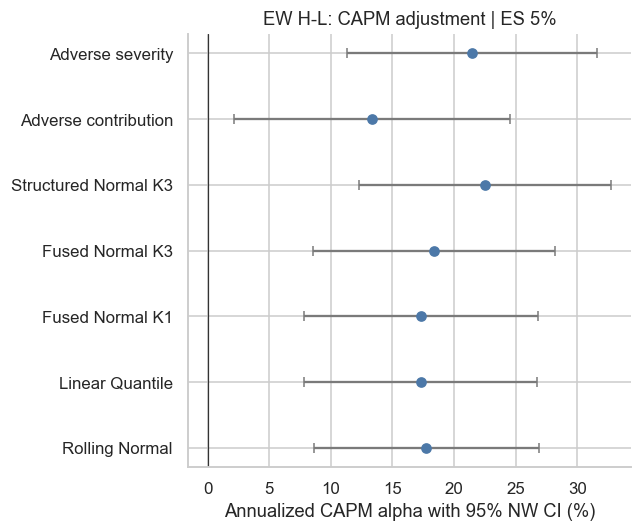

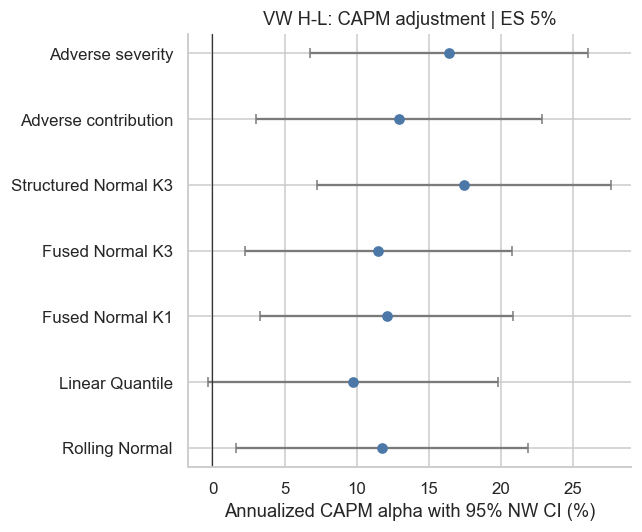

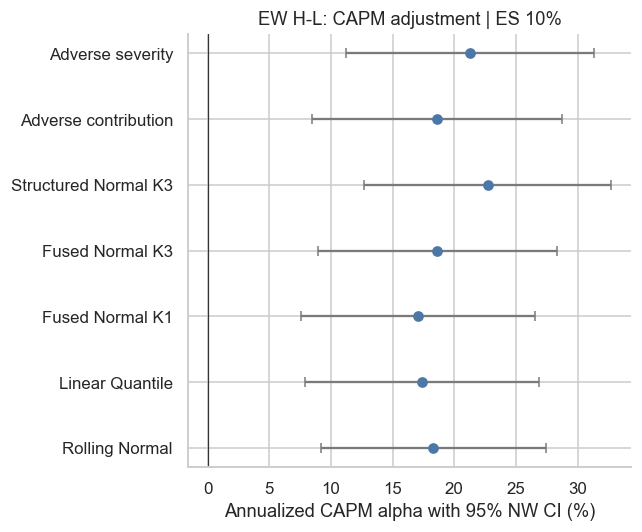

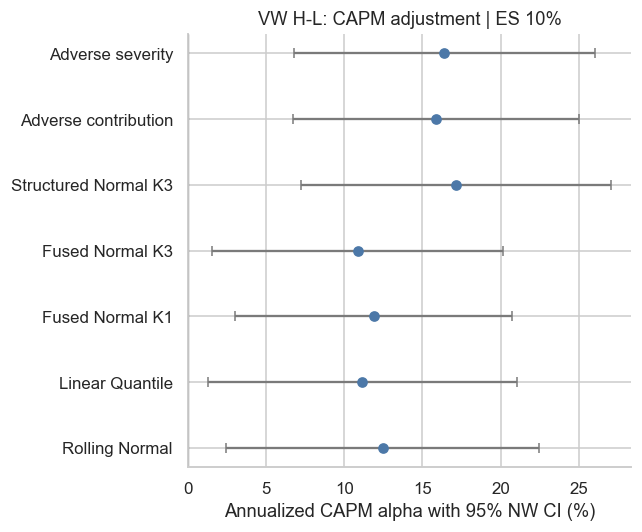

In [21]:
for alpha in alphas:
    print(f"ES alpha = {alpha * 100:g}%")
    factor_alphas = factor_alphas_by_alpha[alpha]
    specification_FF="CAPM"
    plot_alpha = factor_alphas[factor_alphas["specification"] == specification_FF].copy()
    plot_alpha["series_label"] = np.where(
        plot_alpha["signal_name"] == f"Total ES ({alpha * 100:g}%)", plot_alpha["model_label"], plot_alpha["signal_name"]
    )


    series_order = list(model_labels.values()) + ["Adverse contribution", "Adverse severity"]
    for  weighting in  ["EW", "VW"]:
        fig, ax = plt.subplots(figsize=(6, 5))
        data = plot_alpha[plot_alpha["weighting"] == weighting].set_index("series_label").reindex(series_order).dropna().reset_index()
        y = np.arange(len(data))
        ax.errorbar(
            data["alpha_annualized_pct"], y,
            xerr=[data["alpha_annualized_pct"] - data["ci_95_low_pct"], data["ci_95_high_pct"] - data["alpha_annualized_pct"]],
            fmt="o", color="#4C78A8", ecolor="#7A7A7A", capsize=3,
        )
        ax.axvline(0, color="#333333", linewidth=0.8)
        ax.set(title=f"{weighting} H-L: {specification_FF} adjustment | ES {alpha * 100:g}%", xlabel=f"Annualized {specification_FF} alpha with 95% NW CI (%)", yticks=y, yticklabels=data["series_label"])
        # fig.suptitle(f"Factor-adjusted tail-risk portfolio returns {specification_FF}", y=1.02)
        fig.tight_layout()
        fig.savefig(figure_dir / f"fig06_factor_adjusted_alpha_{specification_FF.lower()}_{weighting.lower()}_alpha{alpha_suffix(alpha)}_{save_version}.pdf", dpi=220, bbox_inches="tight", pad_inches=0.02)



ES alpha = 5%
ES alpha = 10%


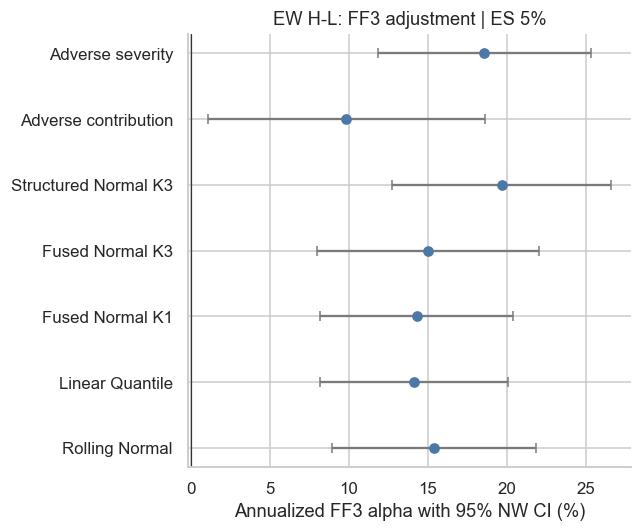

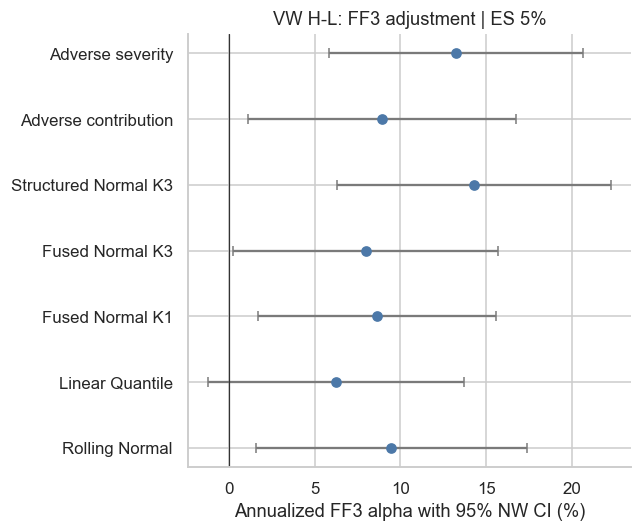

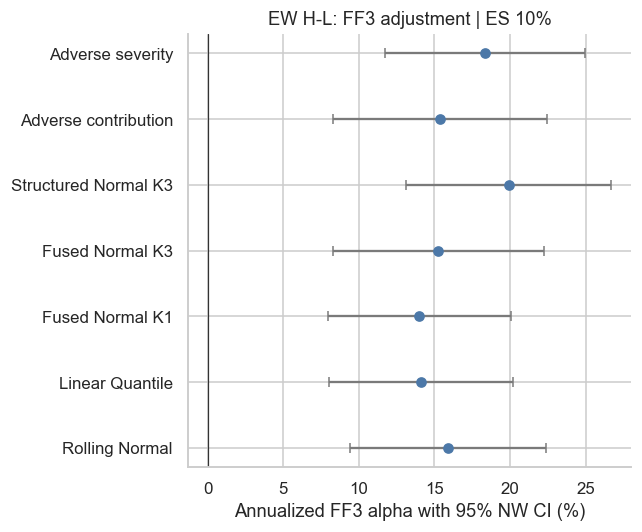

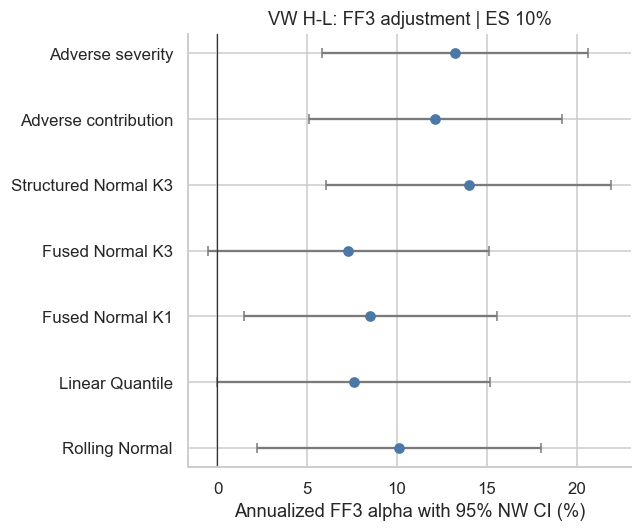

In [22]:
for alpha in alphas:
    print(f"ES alpha = {alpha * 100:g}%")
    factor_alphas = factor_alphas_by_alpha[alpha]
    specification_FF="FF3"
    plot_alpha = factor_alphas[factor_alphas["specification"] == specification_FF].copy()
    plot_alpha["series_label"] = np.where(
        plot_alpha["signal_name"] == f"Total ES ({alpha * 100:g}%)", plot_alpha["model_label"], plot_alpha["signal_name"]
    )

    for  weighting in  ["EW", "VW"]:
        fig, ax = plt.subplots(figsize=(6, 5))
        data = plot_alpha[plot_alpha["weighting"] == weighting].set_index("series_label").reindex(series_order).dropna().reset_index()
        y = np.arange(len(data))
        ax.errorbar(
            data["alpha_annualized_pct"], y,
            xerr=[data["alpha_annualized_pct"] - data["ci_95_low_pct"], data["ci_95_high_pct"] - data["alpha_annualized_pct"]],
            fmt="o", color="#4C78A8", ecolor="#7A7A7A", capsize=3,
        )
        ax.axvline(0, color="#333333", linewidth=0.8)
        ax.set(title=f"{weighting} H-L: {specification_FF} adjustment | ES {alpha * 100:g}%", xlabel=f"Annualized {specification_FF} alpha with 95% NW CI (%)", yticks=y, yticklabels=data["series_label"])
        # fig.suptitle(f"Factor-adjusted tail-risk portfolio returns {specification_FF}", y=1.02)
        fig.tight_layout()
        fig.savefig(figure_dir / f"fig06_factor_adjusted_alpha_{specification_FF.lower()}_{weighting.lower()}_alpha{alpha_suffix(alpha)}_{save_version}.pdf", dpi=220, bbox_inches="tight", pad_inches=0.02)



ES alpha = 5%
ES alpha = 10%


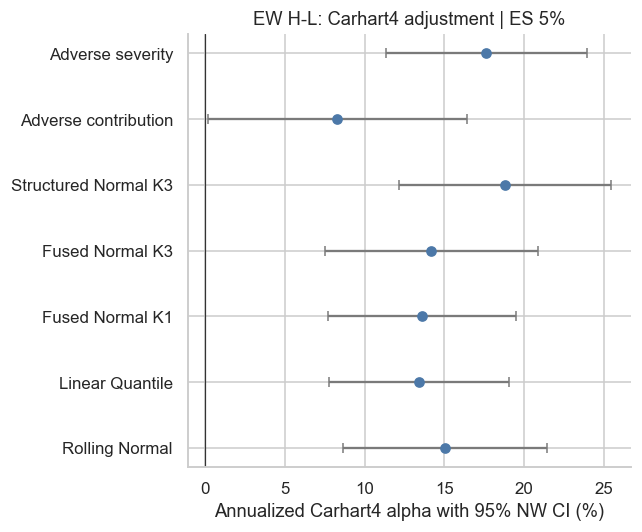

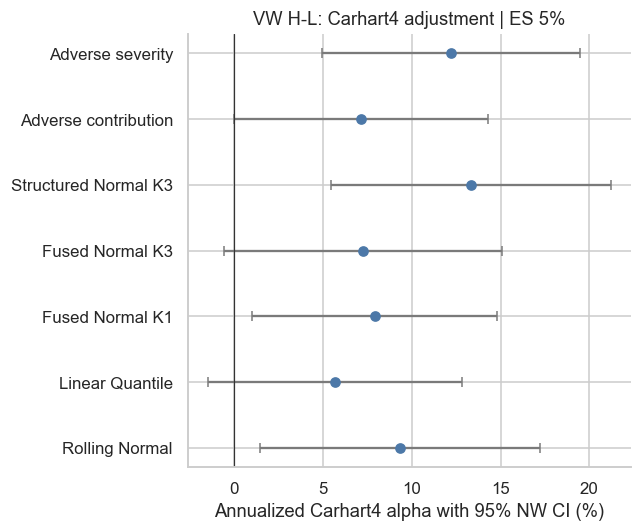

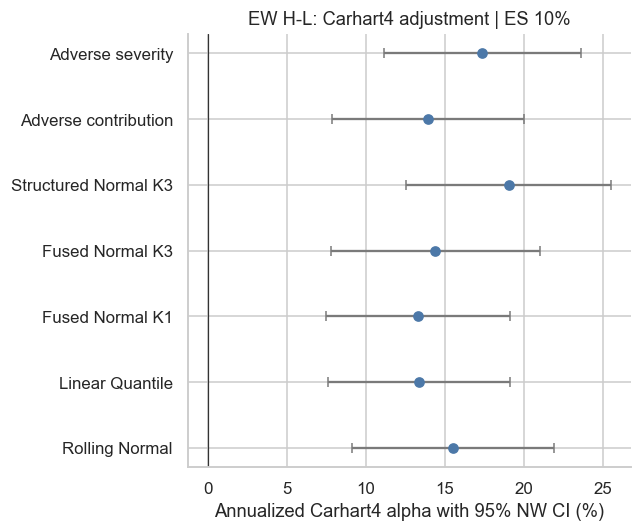

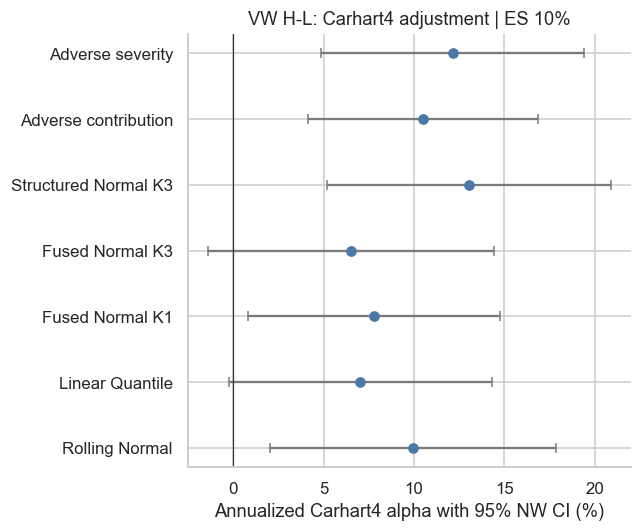

In [23]:
for alpha in alphas:
    print(f"ES alpha = {alpha * 100:g}%")
    factor_alphas = factor_alphas_by_alpha[alpha]
    specification_FF="Carhart4"
    plot_alpha = factor_alphas[factor_alphas["specification"] == specification_FF].copy()
    plot_alpha["series_label"] = np.where(
        plot_alpha["signal_name"] == f"Total ES ({alpha * 100:g}%)", plot_alpha["model_label"], plot_alpha["signal_name"]
    )

    for  weighting in  ["EW", "VW"]:
        fig, ax = plt.subplots(figsize=(6, 5))
        data = plot_alpha[plot_alpha["weighting"] == weighting].set_index("series_label").reindex(series_order).dropna().reset_index()
        y = np.arange(len(data))
        ax.errorbar(
            data["alpha_annualized_pct"], y,
            xerr=[data["alpha_annualized_pct"] - data["ci_95_low_pct"], data["ci_95_high_pct"] - data["alpha_annualized_pct"]],
            fmt="o", color="#4C78A8", ecolor="#7A7A7A", capsize=3,
        )
        ax.axvline(0, color="#333333", linewidth=0.8)
        ax.set(title=f"{weighting} H-L: {specification_FF} adjustment | ES {alpha * 100:g}%", xlabel=f"Annualized {specification_FF} alpha with 95% NW CI (%)", yticks=y, yticklabels=data["series_label"])
        # fig.suptitle(f"Factor-adjusted tail-risk portfolio returns {specification_FF}", y=1.02)
        fig.tight_layout()
        fig.savefig(figure_dir / f"fig06_factor_adjusted_alpha_{specification_FF.lower()}_{weighting.lower()}_alpha{alpha_suffix(alpha)}_{save_version}.pdf", dpi=220, bbox_inches="tight", pad_inches=0.02)
        # save_figure(fig, f"fig06_factor_adjusted_alpha_{specification_FF.lower()}")



ES alpha = 5%
ES alpha = 10%


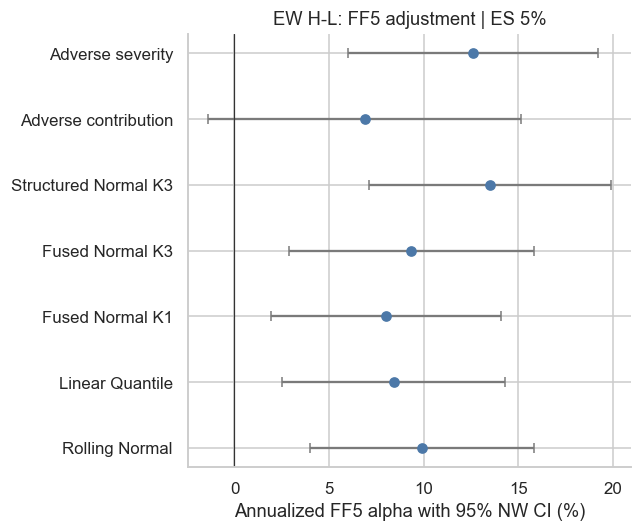

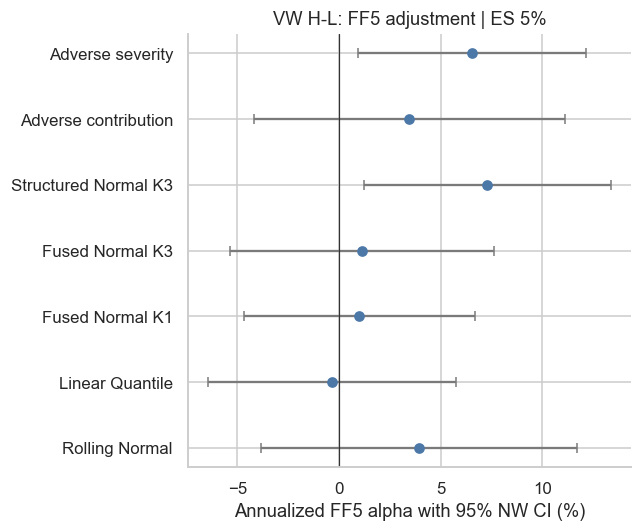

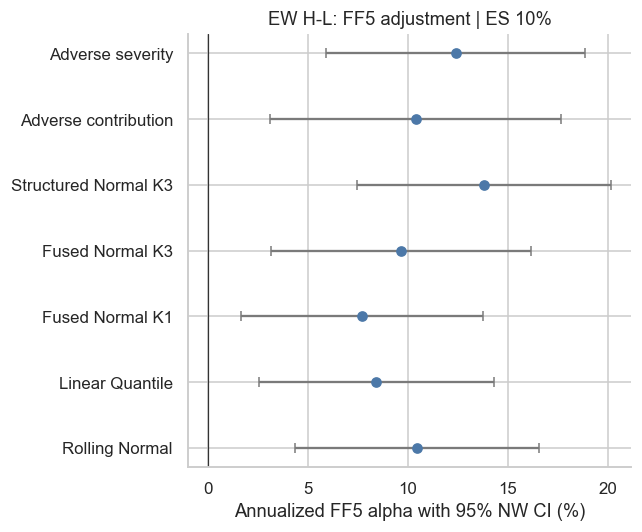

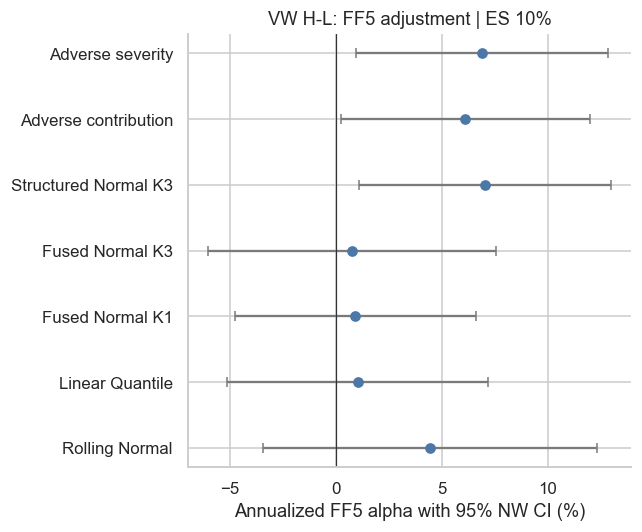

In [24]:
for alpha in alphas:
    print(f"ES alpha = {alpha * 100:g}%")
    factor_alphas = factor_alphas_by_alpha[alpha]
    specification_FF="FF5"
    plot_alpha = factor_alphas[factor_alphas["specification"] == specification_FF].copy()
    plot_alpha["series_label"] = np.where(
        plot_alpha["signal_name"] == f"Total ES ({alpha * 100:g}%)", plot_alpha["model_label"], plot_alpha["signal_name"]
    )
    for  weighting in  ["EW", "VW"]:
        fig, ax = plt.subplots(figsize=(6, 5))
        data = plot_alpha[plot_alpha["weighting"] == weighting].set_index("series_label").reindex(series_order).dropna().reset_index()
        y = np.arange(len(data))
        ax.errorbar(
            data["alpha_annualized_pct"], y,
            xerr=[data["alpha_annualized_pct"] - data["ci_95_low_pct"], data["ci_95_high_pct"] - data["alpha_annualized_pct"]],
            fmt="o", color="#4C78A8", ecolor="#7A7A7A", capsize=3,
        )
        ax.axvline(0, color="#333333", linewidth=0.8)
        ax.set(title=f"{weighting} H-L: {specification_FF} adjustment | ES {alpha * 100:g}%", xlabel=f"Annualized {specification_FF} alpha with 95% NW CI (%)", yticks=y, yticklabels=data["series_label"])
        # fig.suptitle(f"Factor-adjusted tail-risk portfolio returns {specification_FF}", y=1.02)
        fig.tight_layout()
        fig.savefig(figure_dir / f"fig06_factor_adjusted_alpha_{specification_FF.lower()}_{weighting.lower()}_alpha{alpha_suffix(alpha)}_{save_version}.pdf", dpi=220, bbox_inches="tight", pad_inches=0.02)



ES alpha = 5%
ES alpha = 10%


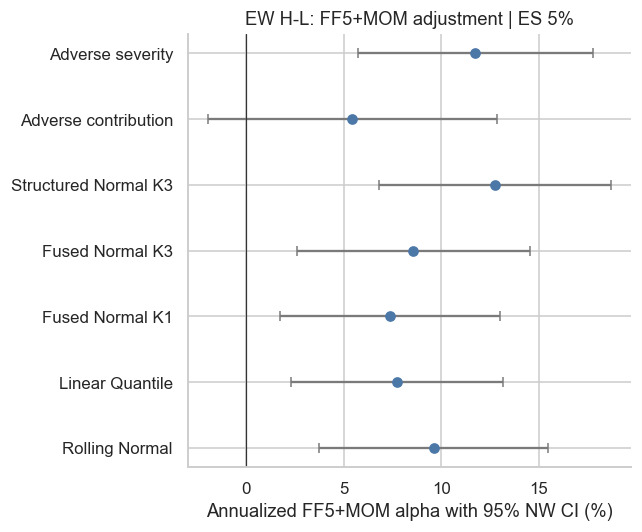

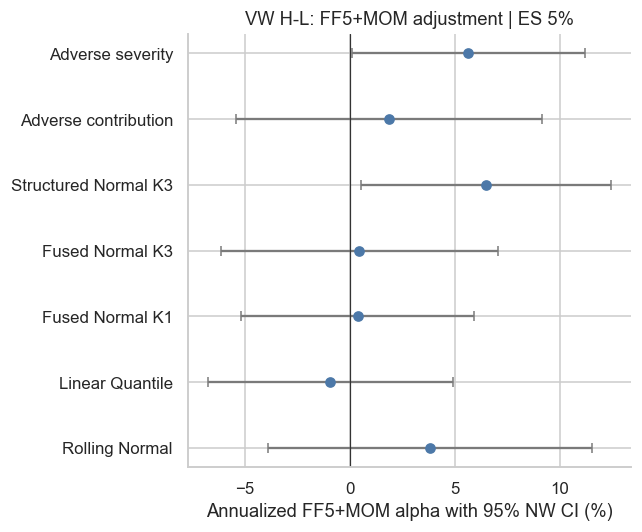

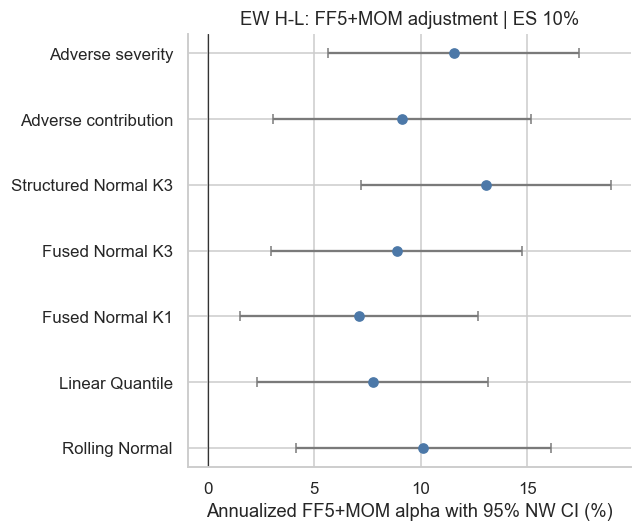

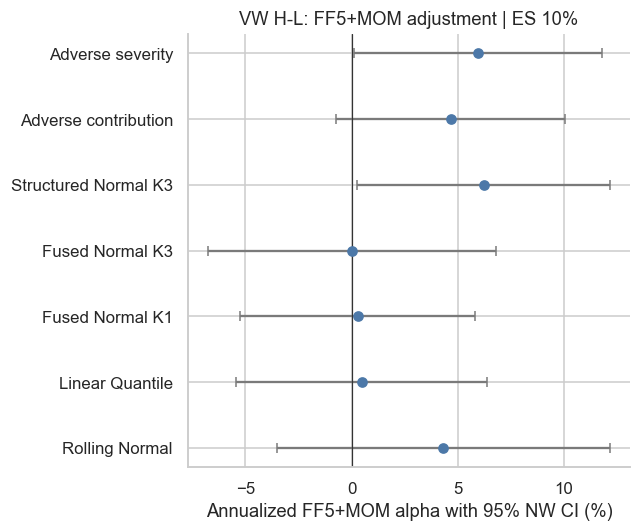

In [25]:
for alpha in alphas:
    print(f"ES alpha = {alpha * 100:g}%")
    factor_alphas = factor_alphas_by_alpha[alpha]
    specification_FF="FF5+MOM"
    plot_alpha = factor_alphas[factor_alphas["specification"] == specification_FF].copy()
    plot_alpha["series_label"] = np.where(
        plot_alpha["signal_name"] == f"Total ES ({alpha * 100:g}%)", plot_alpha["model_label"], plot_alpha["signal_name"]
    )
    for  weighting in  ["EW", "VW"]:
        fig, ax = plt.subplots(figsize=(6, 5))
        data = plot_alpha[plot_alpha["weighting"] == weighting].set_index("series_label").reindex(series_order).dropna().reset_index()
        y = np.arange(len(data))
        ax.errorbar(
            data["alpha_annualized_pct"], y,
            xerr=[data["alpha_annualized_pct"] - data["ci_95_low_pct"], data["ci_95_high_pct"] - data["alpha_annualized_pct"]],
            fmt="o", color="#4C78A8", ecolor="#7A7A7A", capsize=3,
        )
        ax.axvline(0, color="#333333", linewidth=0.8)
        # 
        ax.set(title=f"{weighting} H-L: {specification_FF} adjustment | ES {alpha * 100:g}%", xlabel=f"Annualized {specification_FF} alpha with 95% NW CI (%)", yticks=y, yticklabels=data["series_label"])
        # fig.suptitle(f"Factor-adjusted tail-risk portfolio returns {specification_FF}", y=1.02)
        fig.tight_layout()
        fig.savefig(figure_dir / f"fig06_factor_adjusted_alpha_{specification_FF.lower()}_{weighting.lower()}_alpha{alpha_suffix(alpha)}_{save_version}.pdf", dpi=220, bbox_inches="tight", pad_inches=0.02)
        # save_figure(fig, f"fig06_factor_adjusted_alpha_{specification_FF.lower()}")



## 7. Fama–MacBeth 横截面回归

连续变量每月先在 1%/99% winsorize，再标准化。所有规格使用相同的 non-missing control sample：

1. Univariate；
2. Controls：size、book-to-market、momentum、历史波动率；
3. Controls + industry fixed effects。

In [26]:
control_cols = ["mthcap_log", "bm", "MOM12m", "mu_bench", "sigma_bench", "turnover"]
control_cols_0 = ["mthcap_log", "bm"]
control_cols_1 = ["mthcap_log", "bm", "MOM12m"]
control_cols_2 = ["mthcap_log", "bm", "MOM12m",  "turnover"]
control_cols_3 = ["mthcap_log", "bm", "MOM12m", "mu_bench",  "turnover"]
control_cols_4 = ["mthcap_log", "bm", "MOM12m", "mu_bench"]

In [27]:
# ==========================================
# 7.1 月度横截面回归函数
# ==========================================
def standardize_monthly(panel, columns):
    result = panel.copy()
    for column in columns:
        grouped = result.groupby("mthcaldt")[column]
        lower = grouped.transform(lambda x: x.quantile(0.01))
        upper = grouped.transform(lambda x: x.quantile(0.99))
        # # 不要winsorize
        # lower = grouped.transform(lambda x: min(x))
        # upper = grouped.transform(lambda x: max(x))
        clipped = result[column].clip(lower=lower, upper=upper)
        mean = clipped.groupby(result["mthcaldt"]).transform("mean")
        std = clipped.groupby(result["mthcaldt"]).transform("std")
        result[f"z_{column}"] = (clipped - mean) / std
    return result


def run_fama_macbeth(panel, signal_col, model_id, model_label, signal_name):
    required = ["mthcaldt", "target_ret_final", industry_type, signal_col, *control_cols]
    work = panel[required].replace([np.inf, -np.inf], np.nan).dropna().copy()
    work = standardize_monthly(work, [signal_col, *control_cols])
    z_signal = f"z_{signal_col}"
    z_controls = [f"z_{column}" for column in control_cols]
    controls_0 = [f"z_{column}" for column in control_cols_0]
    controls_1 = [f"z_{column}" for column in control_cols_1]
    controls_2 = [f"z_{column}" for column in control_cols_2]
    controls_3 = [f"z_{column}" for column in control_cols_3]
    controls_4 = [f"z_{column}" for column in control_cols_4]
    specifications = {
        "Univariate": ([], False), 
        "Controls_0": (controls_0, False),
        "Controls_1": (controls_1, False),
        "Controls_2": (controls_2, False),
        "Controls_3": (controls_3, False),
        "Controls_4": (controls_4, False),
        "Controls": (z_controls, False),
        "Univariate+IndustryFE": ([], False), 
        "Controls_0+IndustryFE": (controls_0, True),
        "Controls_1+IndustryFE": (controls_1, True),
        "Controls_2+IndustryFE": (controls_2, True),
        "Controls_3+IndustryFE": (controls_3, True),
        "Controls_4+IndustryFE": (controls_4, True),
        "Controls+IndustryFE": (z_controls, True),

    }

    rows = []
    for month, group in work.groupby("mthcaldt", sort=True):
        y = group["target_ret_final"].to_numpy(dtype=float)
        for specification, (controls, industry_fe) in specifications.items():
            X = group[[z_signal] + controls].to_numpy(dtype=float)
            if industry_fe:
                industry = pd.get_dummies(group[industry_type].astype(int), drop_first=True, dtype=float).to_numpy()
                X = np.column_stack([X, industry])
            X = np.column_stack([np.ones(len(group)), X])
            # beta = np.linalg.lstsq(X, y, rcond=None)[0]
            # residual = y - X @ beta
            # total_ss = np.sum((y - y.mean()) ** 2)
            # rows.append({
            #     "mthcaldt": month, "model_id": model_id, "model_label": model_label,
            #     "signal_name": signal_name, "specification": specification,
            #     "signal_slope": beta[1], "r_squared": 1 - np.sum(residual ** 2) / total_ss,
            #     "n_firms": len(group),
            # })
            beta = np.linalg.lstsq(X, y, rcond=None)[0]
            residual = y - X @ beta
            total_ss = np.sum((y - y.mean()) ** 2)
            
            # 生成当前回归中所有自变量的名字列表
            feat_names = ["intercept", z_signal] + controls
            if industry_fe:
                # 这里的行业列名取决于你的 get_dummies，此处用泛指代替
                feat_names += [f"industry_{i}" for i in range(industry.shape[1])]
            
            # 把所有的系数打包成一个字典
            betas_dict = {f"beta_{name}": b for name, b in zip(feat_names, beta)}
            
            row_data = {
                "mthcaldt": month, "model_id": model_id, "model_label": model_label,
                "signal_name": signal_name, "specification": specification,
                "signal_slope": beta[1], # 依然可以单独保留它方便后续调用
                "r_squared": 1 - np.sum(residual ** 2) / total_ss,
                "n_firms": len(group),
            }
            # 将所有beta合并到记录中
            row_data.update(betas_dict)
            rows.append(row_data)
    return pd.DataFrame(rows)


def summarize_fama_macbeth(slopes):
    rows = []
    group_cols = ["model_id", "model_label", "signal_name", "specification"]
    for keys, group in slopes.groupby(group_cols):
        row = dict(zip(group_cols, keys))
        row.update(nw_mean(group["signal_slope"]))
        row["annualized_slope_pct"] = 1200 * row["mean_monthly"]
        row["annualized_ci_low_pct"] = 1200 * row["ci_95_low"]
        row["annualized_ci_high_pct"] = 1200 * row["ci_95_high"]
        rows.append(row)
    return pd.DataFrame(rows)

In [28]:
# ==========================================
# 7.2 所有模型 ES、adverse contribution 和 severity
# ==========================================
fmb_monthly_slopes_by_alpha = {}
fmb_summary_by_alpha = {}
for alpha in alphas:
    print(f"ES alpha = {alpha * 100:g}%")
    mechanism_specs = mechanism_specs_by_alpha[alpha]
    fmb_parts = []
    for model_id in model_order:
        print("Fama-MacBeth:", model_labels[model_id])
        panel = load_model_panel(model_id, alpha)
        fmb_parts.append(run_fama_macbeth(panel, "signal", model_id, model_labels[model_id], f"Total ES ({alpha * 100:g}%)"))

    for signal_name, signal_col in mechanism_specs.items():
        print("Fama-MacBeth:", signal_name)
        fmb_parts.append(run_fama_macbeth(pricing_base, signal_col, "structured_normal_k3", signal_name, signal_name))

    fmb_monthly_slopes = pd.concat(fmb_parts, ignore_index=True)
    fmb_summary = summarize_fama_macbeth(fmb_monthly_slopes)

    fmb_monthly_slopes.to_parquet(result_dir / f"fmb_monthly_slopes_{timestamp}_alpha{alpha_suffix(alpha)}.parquet", index=False)
    fmb_summary.to_parquet(result_dir / f"fmb_summary_{timestamp}_alpha{alpha_suffix(alpha)}.parquet", index=False)

    display(fmb_monthly_slopes)
    display(fmb_summary)

    fmb_monthly_slopes_by_alpha[alpha] = fmb_monthly_slopes
    fmb_summary_by_alpha[alpha] = fmb_summary


ES alpha = 5%
Fama-MacBeth: Rolling Normal
Fama-MacBeth: Linear Quantile
Fama-MacBeth: Fused Normal K1
Fama-MacBeth: Fused Normal K3
Fama-MacBeth: Structured Normal K3
Fama-MacBeth: Adverse contribution
Fama-MacBeth: Adverse severity


,mthcaldt,model_id,model_label,signal_name,specification,signal_slope,r_squared,n_firms,beta_intercept,beta_z_signal,beta_z_mthcap_log,beta_z_bm,beta_z_MOM12m,beta_z_turnover,beta_z_mu_bench,beta_z_sigma_bench,beta_industry_0,beta_industry_1,beta_industry_2,beta_industry_3,beta_industry_4,beta_industry_5,beta_industry_6,beta_industry_7,beta_industry_8,beta_industry_9,beta_industry_10,beta_z_es_contribution_adverse_5,beta_z_severity_adverse_5
0,2007-01-31,rolling_normal,Rolling Normal,Total ES (5%),Univariate,-0.001610,0.000279,2692,0.005513,-0.001610,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2007-01-31,rolling_normal,Rolling Normal,Total ES (5%),Controls_0,-0.000751,0.004980,2692,0.005513,-0.000751,-0.004107,0.004423,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2007-01-31,rolling_normal,Rolling Normal,Total ES (5%),Controls_1,-0.000643,0.006271,2692,0.005513,-0.000643,-0.004157,0.003806,-0.003518,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2007-01-31,rolling_normal,Rolling Normal,Total ES (5%),Controls_2,-0.000155,0.006411,2692,0.005513,-0.000155,-0.004580,0.003850,-0.003541,0.001264,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2007-01-31,rolling_normal,Rolling Normal,Total ES (5%),Controls_3,-0.000328,0.006724,2692,0.005513,-0.000328,-0.004551,0.003799,0.000818,0.001251,-0.004692,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21163,2024-12-31,structured_normal_k3,Adverse severity,Adverse severity,Controls_1+IndustryFE,0.013708,0.027379,1904,-0.015160,NaN,0.007203,-0.000466,0.004642,NaN,NaN,NaN,0.034186,0.038766,0.013437,0.010988,0.044177,0.017405,0.015374,0.047926,0.071666,0.075786,0.036534,NaN,0.013708
21164,2024-12-31,structured_normal_k3,Adverse severity,Adverse severity,Controls_2+IndustryFE,0.008560,0.029731,1904,-0.012995,NaN,0.009299,0.000775,0.005250,-0.007771,NaN,NaN,0.032247,0.037764,0.010169,0.008497,0.043530,0.013350,0.013067,0.047066,0.065573,0.074003,0.035022,NaN,0.008560
21165,2024-12-31,structured_normal_k3,Adverse severity,Adverse severity,Controls_3+IndustryFE,0.006332,0.037846,1904,-0.011862,NaN,0.008429,0.000697,0.028137,-0.005038,-0.027026,NaN,0.029965,0.036219,0.008194,0.005736,0.043600,0.013419,0.013110,0.046597,0.063678,0.075548,0.032576,NaN,0.006332
21166,2024-12-31,structured_normal_k3,Adverse severity,Adverse severity,Controls_4+IndustryFE,0.009411,0.036891,1904,-0.013145,NaN,0.007062,-0.000085,0.029216,NaN,-0.028750,NaN,0.031033,0.036748,0.010114,0.007120,0.044009,0.015961,0.014556,0.047105,0.067370,0.076763,0.033366,NaN,0.009411


,model_id,model_label,signal_name,specification,mean_monthly,nw_se,nw_t,p_value,ci_95_low,ci_95_high,months,annualized_slope_pct,annualized_ci_low_pct,annualized_ci_high_pct
0,fused_normal_k1,Fused Normal K1,Total ES (5%),Controls,0.000341,0.001349,0.252419,0.800718,-0.002304,0.002985,216,0.408739,-2.765073,3.582551
1,fused_normal_k1,Fused Normal K1,Total ES (5%),Controls+IndustryFE,0.000819,0.001370,0.597699,0.550041,-0.001867,0.003504,216,0.982711,-2.239836,4.205257
2,fused_normal_k1,Fused Normal K1,Total ES (5%),Controls_0,0.002416,0.001447,1.669704,0.094978,-0.000420,0.005252,216,2.899317,-0.504076,6.302711
3,fused_normal_k1,Fused Normal K1,Total ES (5%),Controls_0+IndustryFE,0.002526,0.001576,1.602319,0.109085,-0.000564,0.005616,216,3.031101,-0.676623,6.738826
4,fused_normal_k1,Fused Normal K1,Total ES (5%),Controls_1,0.002918,0.001368,2.133817,0.032858,0.000238,0.005599,216,3.501820,0.285252,6.718388
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93,structured_normal_k3,Structured Normal K3,Total ES (5%),Controls_3+IndustryFE,0.002143,0.001633,1.312278,0.189426,-0.001058,0.005343,216,2.571433,-1.269223,6.412089
94,structured_normal_k3,Structured Normal K3,Total ES (5%),Controls_4,0.002953,0.001484,1.990075,0.046583,0.000045,0.005862,216,3.543707,0.053555,7.033860
95,structured_normal_k3,Structured Normal K3,Total ES (5%),Controls_4+IndustryFE,0.002965,0.001709,1.734635,0.082805,-0.000385,0.006315,216,3.557842,-0.462237,7.577921
96,structured_normal_k3,Structured Normal K3,Total ES (5%),Univariate,0.002596,0.001534,1.692743,0.090504,-0.000410,0.005602,216,3.115111,-0.491826,6.722049


ES alpha = 10%
Fama-MacBeth: Rolling Normal
Fama-MacBeth: Linear Quantile
Fama-MacBeth: Fused Normal K1
Fama-MacBeth: Fused Normal K3
Fama-MacBeth: Structured Normal K3
Fama-MacBeth: Adverse contribution
Fama-MacBeth: Adverse severity


,mthcaldt,model_id,model_label,signal_name,specification,signal_slope,r_squared,n_firms,beta_intercept,beta_z_signal,beta_z_mthcap_log,beta_z_bm,beta_z_MOM12m,beta_z_turnover,beta_z_mu_bench,beta_z_sigma_bench,beta_industry_0,beta_industry_1,beta_industry_2,beta_industry_3,beta_industry_4,beta_industry_5,beta_industry_6,beta_industry_7,beta_industry_8,beta_industry_9,beta_industry_10,beta_z_es_contribution_adverse_10,beta_z_severity_adverse_10
0,2007-01-31,rolling_normal,Rolling Normal,Total ES (10%),Univariate,-0.001676,0.000302,2692,0.005513,-0.001676,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2007-01-31,rolling_normal,Rolling Normal,Total ES (10%),Controls_0,-0.000805,0.004989,2692,0.005513,-0.000805,-0.004092,0.004427,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2007-01-31,rolling_normal,Rolling Normal,Total ES (10%),Controls_1,-0.000649,0.006272,2692,0.005513,-0.000649,-0.004158,0.003803,-0.003510,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2007-01-31,rolling_normal,Rolling Normal,Total ES (10%),Controls_2,-0.000172,0.006411,2692,0.005513,-0.000172,-0.004574,0.003852,-0.003539,0.001259,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2007-01-31,rolling_normal,Rolling Normal,Total ES (10%),Controls_3,-0.000322,0.006724,2692,0.005513,-0.000322,-0.004555,0.003796,0.000813,0.001254,-0.004683,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21163,2024-12-31,structured_normal_k3,Adverse severity,Adverse severity,Controls_1+IndustryFE,0.013719,0.027359,1904,-0.015147,NaN,0.007148,-0.000486,0.004627,NaN,NaN,NaN,0.034162,0.038747,0.013455,0.010932,0.044166,0.017410,0.015326,0.047932,0.071641,0.075730,0.036529,NaN,0.013719
21164,2024-12-31,structured_normal_k3,Adverse severity,Adverse severity,Controls_2+IndustryFE,0.008554,0.029722,1904,-0.012981,NaN,0.009271,0.000766,0.005242,-0.007786,NaN,NaN,0.032228,0.037750,0.010173,0.008456,0.043521,0.013344,0.013034,0.047068,0.065542,0.073964,0.035016,NaN,0.008554
21165,2024-12-31,structured_normal_k3,Adverse severity,Adverse severity,Controls_3+IndustryFE,0.006302,0.037834,1904,-0.011842,NaN,0.008421,0.000692,0.028127,-0.005058,-0.027025,NaN,0.029946,0.036207,0.008188,0.005700,0.043583,0.013405,0.013087,0.046595,0.063624,0.075519,0.032567,NaN,0.006302
21166,2024-12-31,structured_normal_k3,Adverse severity,Adverse severity,Controls_4+IndustryFE,0.009397,0.036872,1904,-0.013127,NaN,0.007035,-0.000098,0.029207,NaN,-0.028755,NaN,0.031013,0.036734,0.010120,0.007076,0.043992,0.015959,0.014528,0.047107,0.067327,0.076726,0.033360,NaN,0.009397


,model_id,model_label,signal_name,specification,mean_monthly,nw_se,nw_t,p_value,ci_95_low,ci_95_high,months,annualized_slope_pct,annualized_ci_low_pct,annualized_ci_high_pct
0,fused_normal_k1,Fused Normal K1,Total ES (10%),Controls,0.000328,0.001350,0.242653,0.808274,-0.002319,0.002974,216,0.393160,-2.782546,3.568866
1,fused_normal_k1,Fused Normal K1,Total ES (10%),Controls+IndustryFE,0.000858,0.001372,0.625368,0.531729,-0.001831,0.003548,216,1.029794,-2.197738,4.257327
2,fused_normal_k1,Fused Normal K1,Total ES (10%),Controls_0,0.002410,0.001436,1.678698,0.093211,-0.000404,0.005225,216,2.892487,-0.484699,6.269673
3,fused_normal_k1,Fused Normal K1,Total ES (10%),Controls_0+IndustryFE,0.002554,0.001565,1.632003,0.102679,-0.000513,0.005620,216,3.064338,-0.615864,6.744541
4,fused_normal_k1,Fused Normal K1,Total ES (10%),Controls_1,0.002899,0.001359,2.133661,0.032871,0.000236,0.005562,216,3.479052,0.283163,6.674941
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93,structured_normal_k3,Structured Normal K3,Total ES (10%),Controls_3+IndustryFE,0.002046,0.001657,1.234660,0.216957,-0.001202,0.005294,216,2.455248,-1.442411,6.352908
94,structured_normal_k3,Structured Normal K3,Total ES (10%),Controls_4,0.002911,0.001486,1.958859,0.050129,-0.000002,0.005823,216,3.492982,-0.002034,6.987998
95,structured_normal_k3,Structured Normal K3,Total ES (10%),Controls_4+IndustryFE,0.002893,0.001735,1.667602,0.095395,-0.000507,0.006293,216,3.471702,-0.608729,7.552132
96,structured_normal_k3,Structured Normal K3,Total ES (10%),Univariate,0.002578,0.001537,1.676517,0.093637,-0.000436,0.005591,216,3.093024,-0.523002,6.709050


/var/folders/8b/0krd96r57jldyg4t2s79cv140000gn/T/ipykernel_43191/995700681.py:13: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(6, 4))


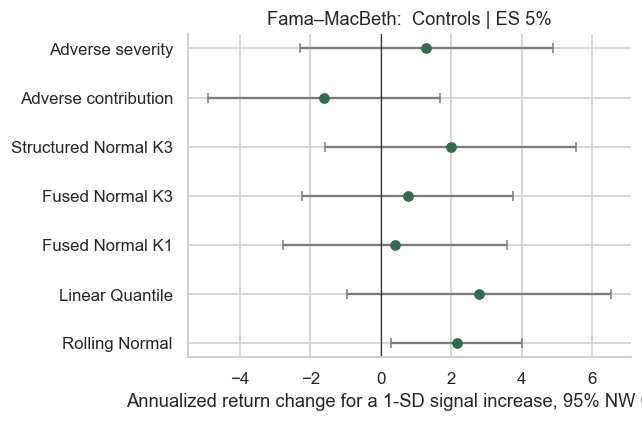

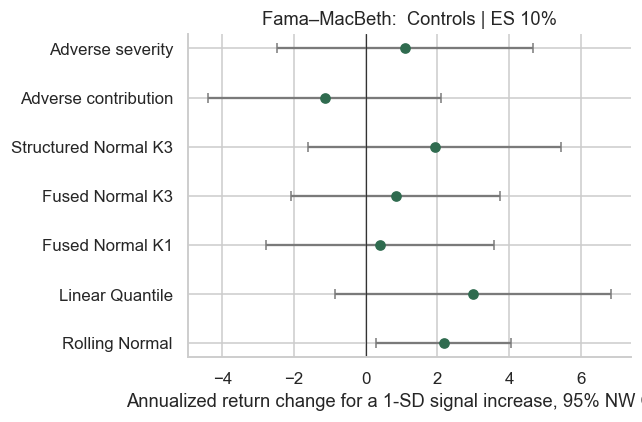

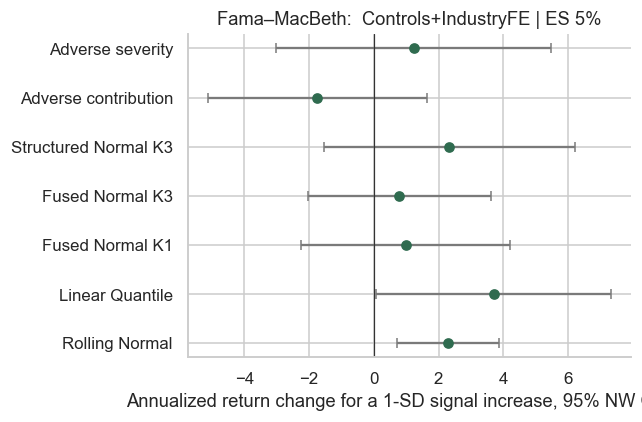

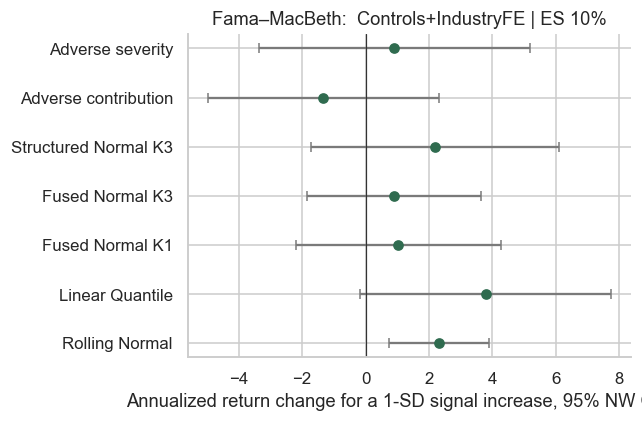

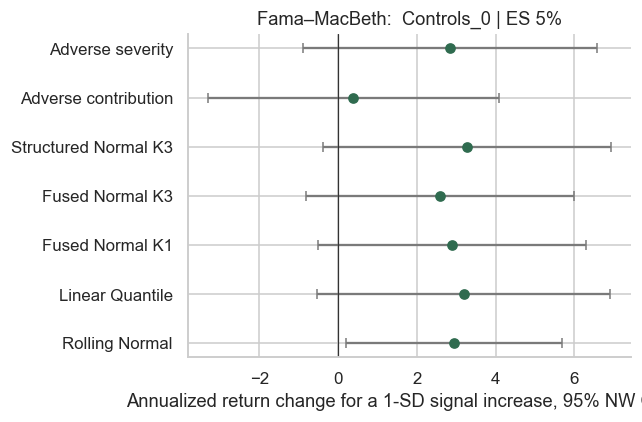

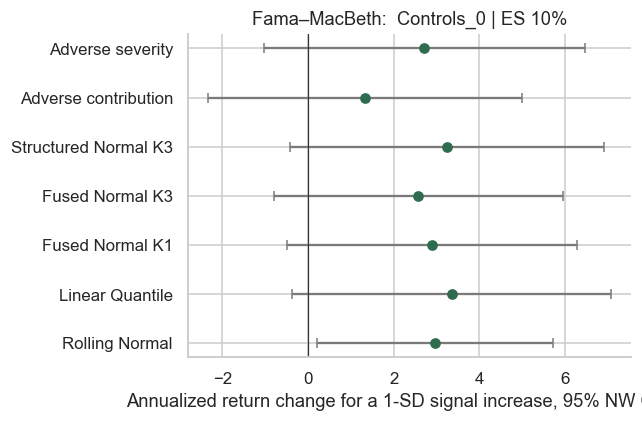

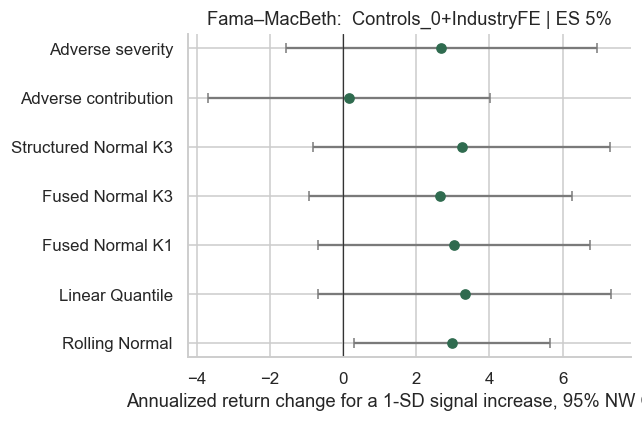

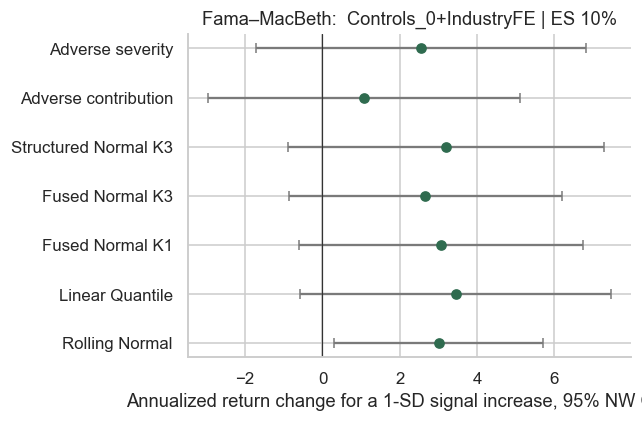

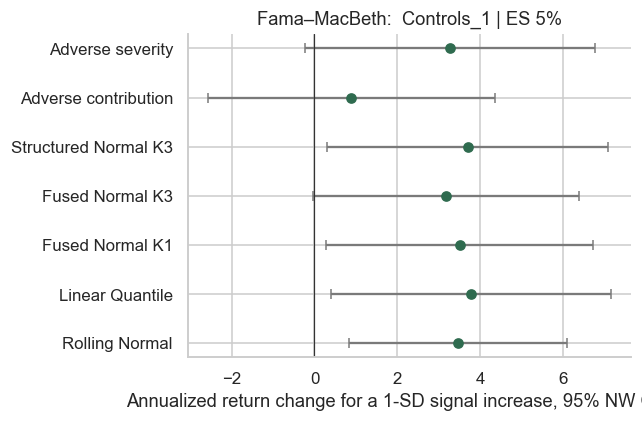

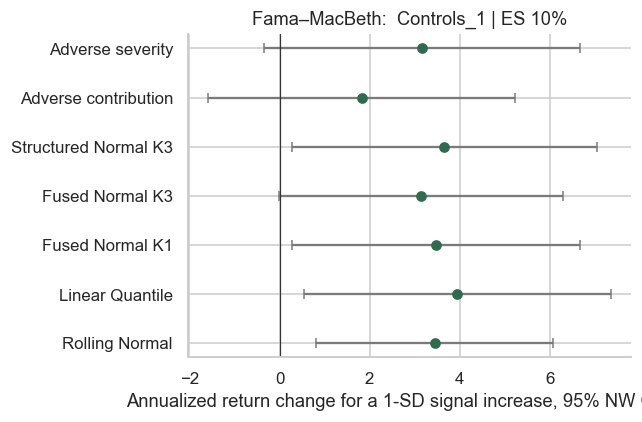

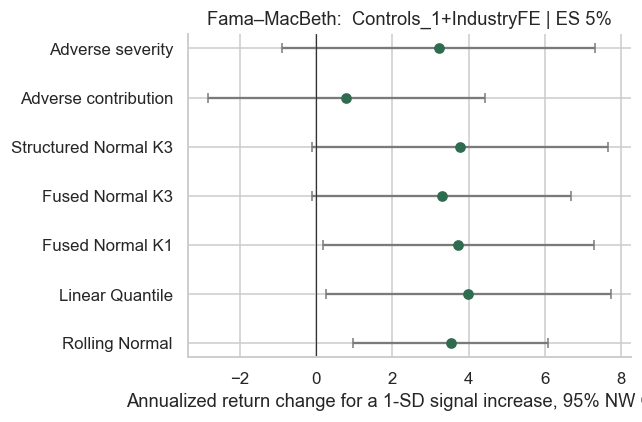

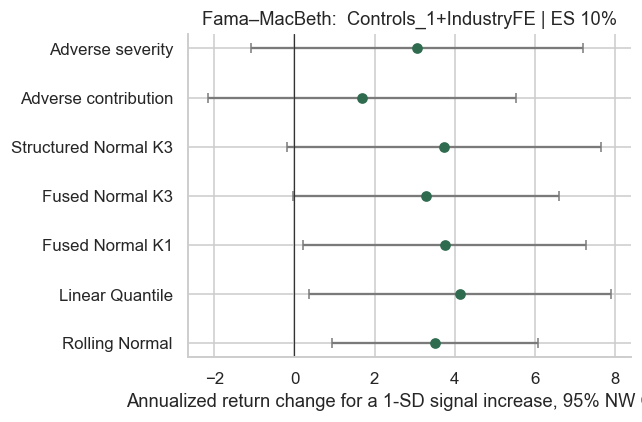

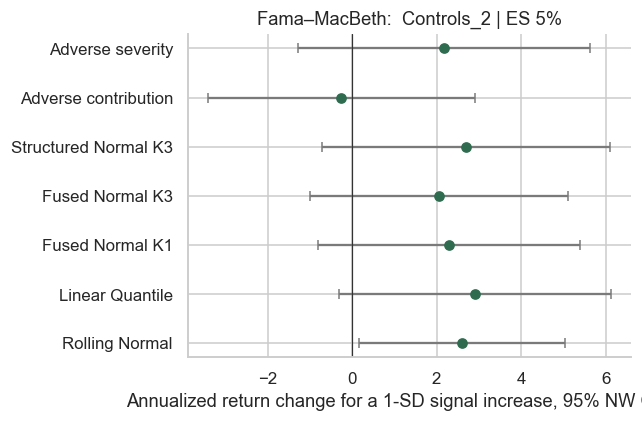

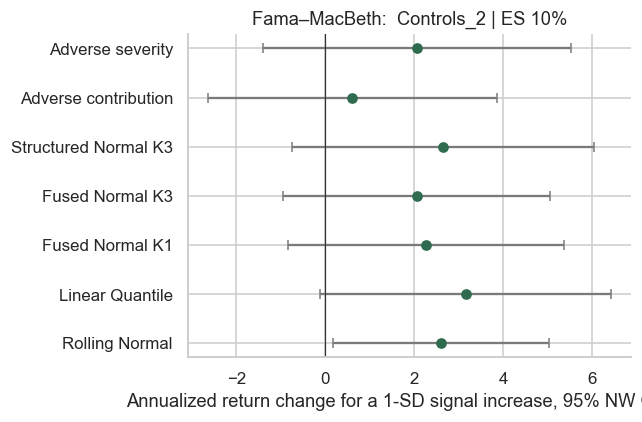

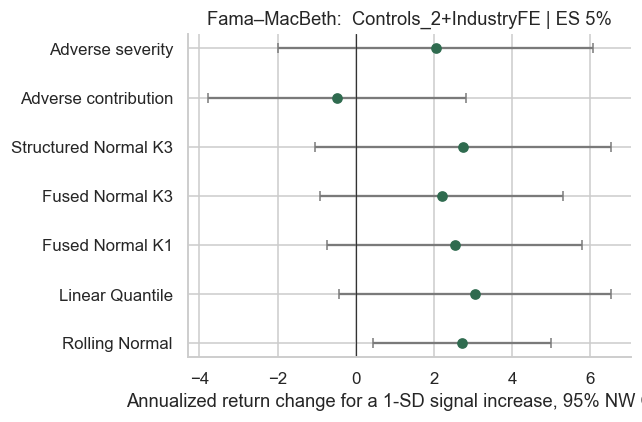

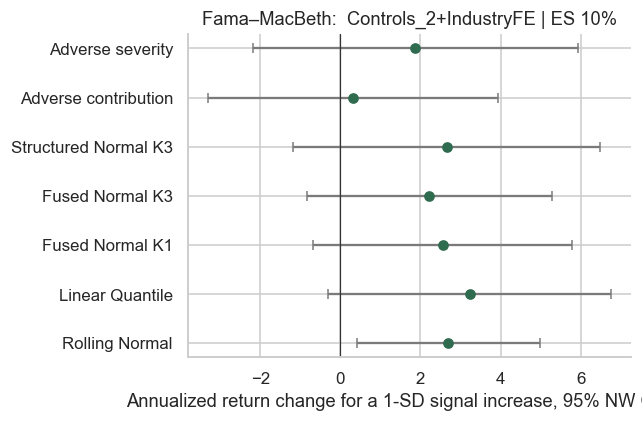

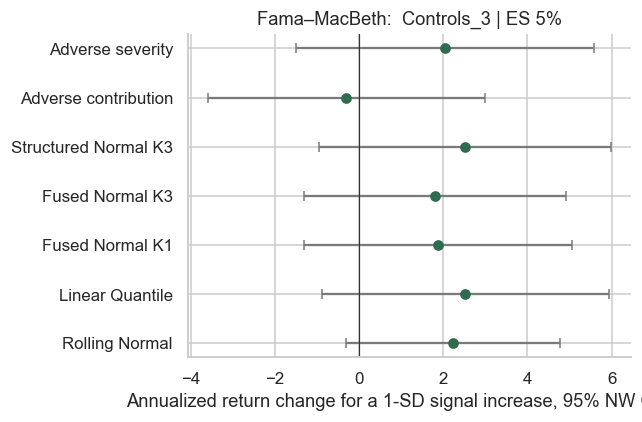

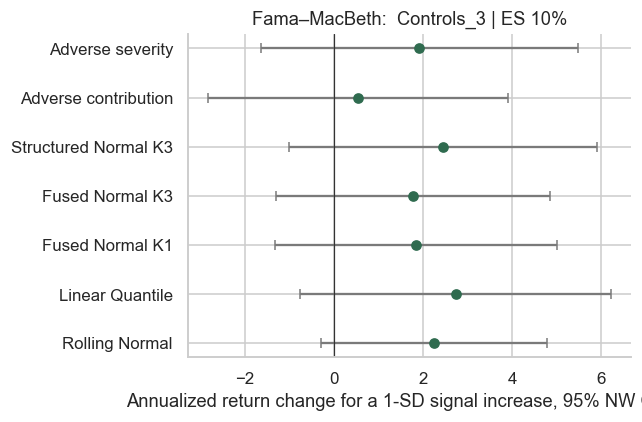

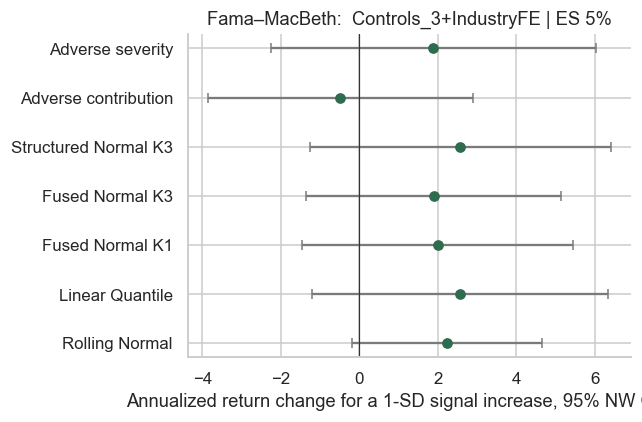

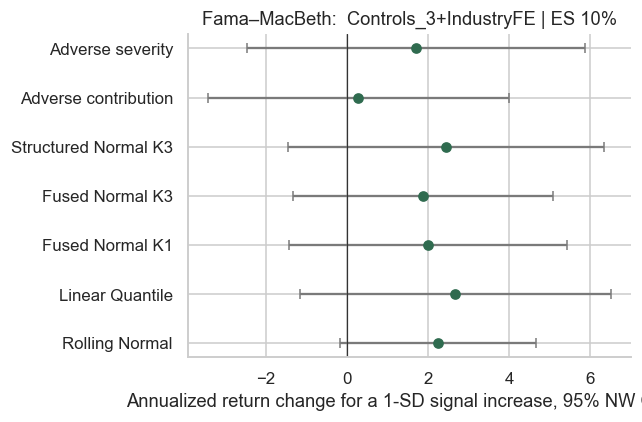

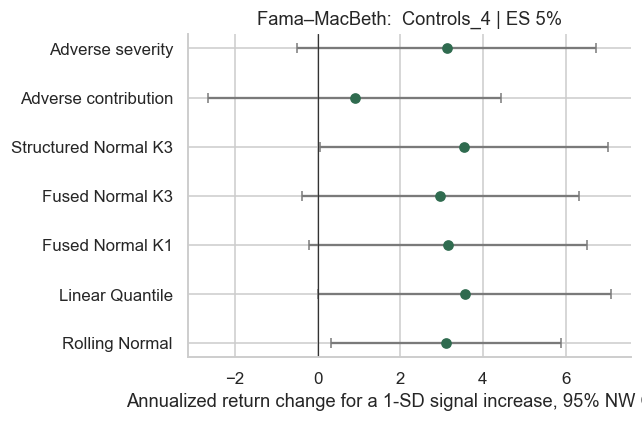

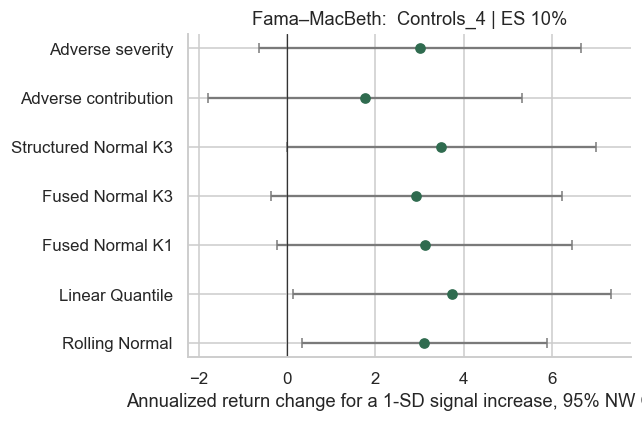

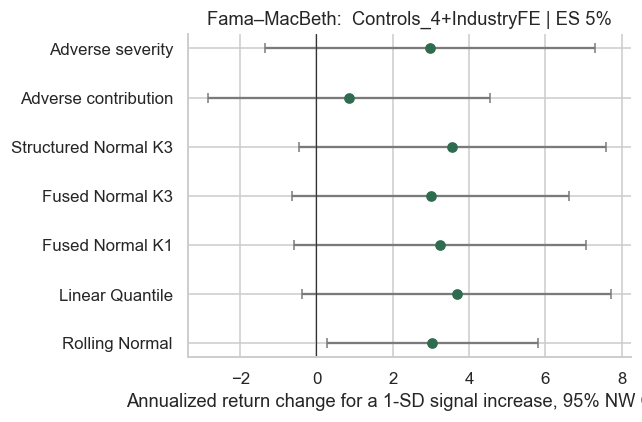

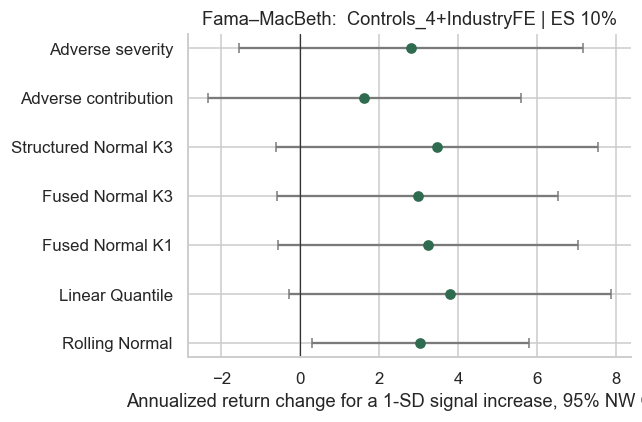

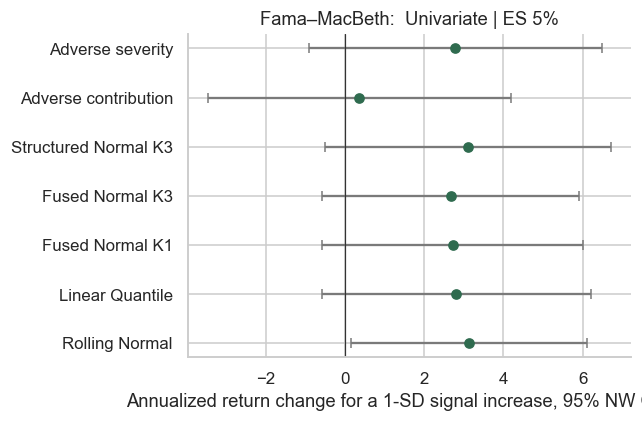

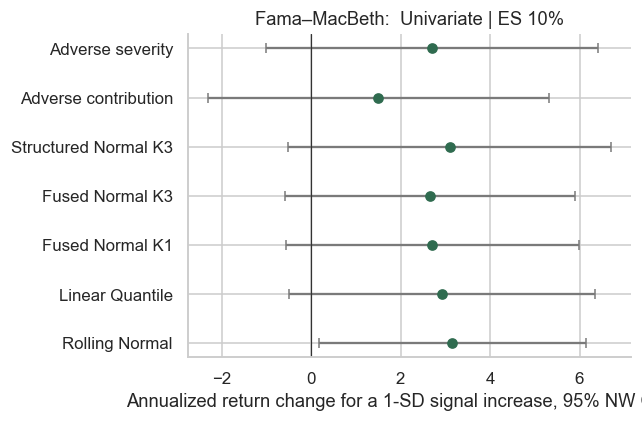

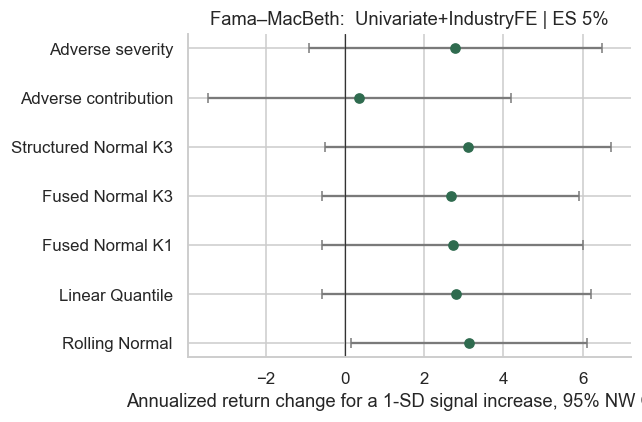

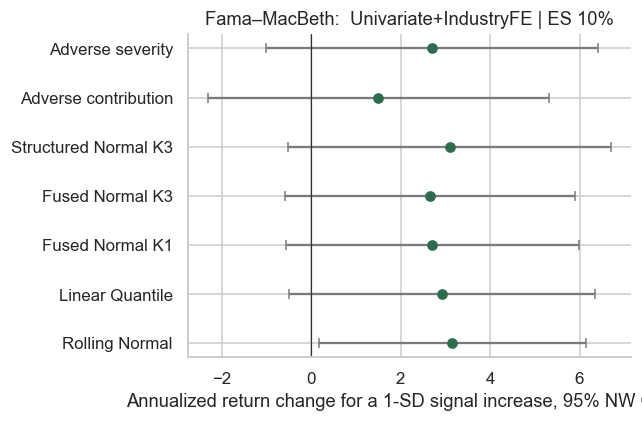

In [29]:
# ==========================================
# 7.3 图：控制变量和行业固定效应下的 Fama-MacBeth slopes
# ==========================================
for control_spec in fmb_summary["specification"].unique():
    for alpha in alphas:
        # print(f"ES alpha = {alpha * 100:g}%")
        fmb_summary = fmb_summary_by_alpha[alpha]
        plot_fmb = fmb_summary[fmb_summary["specification"] == control_spec].copy()
        plot_fmb["series_label"] = plot_fmb["model_label"]
        series_order = list(model_labels.values()) + ["Adverse contribution", "Adverse severity"]
        plot_fmb = plot_fmb.set_index("series_label").reindex(series_order).dropna().reset_index()

        fig, ax = plt.subplots(figsize=(6, 4))
        y = np.arange(len(plot_fmb))
        ax.errorbar(
            plot_fmb["annualized_slope_pct"], y,
            xerr=[plot_fmb["annualized_slope_pct"] - plot_fmb["annualized_ci_low_pct"], plot_fmb["annualized_ci_high_pct"] - plot_fmb["annualized_slope_pct"]],
            fmt="o", color="#2F6B4F", ecolor="#7A7A7A", capsize=3,
        )
        ax.axvline(0, color="#333333", linewidth=0.8)
        ax.set(
            title=f"Fama–MacBeth:  {control_spec} | ES {alpha * 100:g}%",
            xlabel="Annualized return change for a 1-SD signal increase, 95% NW CI (%)",
            yticks=y, yticklabels=plot_fmb["series_label"],
        )
        fig.tight_layout()
        fig.savefig(figure_dir / f"fig07_fama_macbeth_controls_industry_fe_alpha{alpha_suffix(alpha)}_{save_version}.pdf", dpi=220, bbox_inches="tight", pad_inches=0.02)


## 8. Adverse weight 与 state-dependent tail-risk premium

`pi_adverse` 是 Structured K3 在每个月输出的 adverse-component probability。同一个月内，所有股票使用同一个 `pi_adverse`，所以它不是个股排序信号，而是一个月度状态变量。

本节对三个股票层面的 tail-risk signals 做相同的状态依赖检验：

1. **Total ES**：模型给出的总 Expected Shortfall；
2. **Adverse contribution**：adverse component 对总 ES 的加总贡献；
3. **Adverse severity**：进入 adverse component 后的条件尾部严重程度。

三项检验分别回答：

1. 信号形成的 H--L portfolio return 是否随 `pi_adverse` 改变；
2. 信号的月度 Fama--MacBeth slope 是否随 `pi_adverse` 改变；
3. 个股层面的 signal × `pi_adverse` interaction 是否显著。

主设定使用全样本标准化的 `pi_adverse` 并加入 rolling-window fixed effects。固定效应吸收不同模型窗口的平均水平差异，因此系数来自同一窗口内的月度变化。Fama--MacBeth 和 pooled interaction 的主控制变量均为 `Controls_1`：size、book-to-market 和 momentum。

另外做三项机制诊断：检验 adverse tail weight、比较 normal/favorable contribution，并用 leave-one-window-out 检查结果是否由单个 rolling window 推动。没有 window fixed effects 的 global z-score 结果仅作为对照。


In [30]:
# ==========================================
# 8.1 构造月度 adverse-weight state
# ==========================================

state_monthly = (
    pricing_base.groupby("mthcaldt", as_index=False)
    .agg(pi_adverse=("pi_adverse", "first"), window=("window", "first"))
    .sort_values("mthcaldt")
    .reset_index(drop=True)
)

# 主状态变量：全样本 z-score。
pi_mean = state_monthly["pi_adverse"].mean()
pi_std = state_monthly["pi_adverse"].std(ddof=1)
state_monthly["pi_adverse_global_z"] = (state_monthly["pi_adverse"] - pi_mean) / pi_std

# 后续状态验证图使用全样本 percentile rank。
state_monthly["pi_rank_global"] = state_monthly["pi_adverse"].rank(pct=True)

# 稳健性状态变量：在每个 rolling window 内重新标准化。
window_mean = state_monthly.groupby("window")["pi_adverse"].transform("mean")
window_std = state_monthly.groupby("window")["pi_adverse"].transform("std", ddof=1)
state_monthly["pi_adverse_within_z"] = (state_monthly["pi_adverse"] - window_mean) / window_std


def state_signal_names(alpha):
    return [
        f"Total ES ({alpha * 100:g}%)",
        "Adverse contribution",
        "Adverse severity",
    ]


def state_diagnostic_signal_specs(alpha):
    suffix = alpha_suffix(alpha)
    return {
        "Adverse tail weight": f"tail_weight_adverse_{suffix}",
        "Normal contribution": f"es_contribution_normal_{suffix}",
        "Favorable contribution": f"es_contribution_favorable_{suffix}",
    }


# pi_adverse 与 alpha 无关，但保留 by-alpha dictionary，方便与前文接口一致。
state_monthly_by_alpha = {}
for alpha in alphas:
    state_for_alpha = state_monthly.copy()
    state_for_alpha.to_parquet(
        result_dir
        / f"state_monthly_{timestamp}_alpha{alpha_suffix(alpha)}.parquet",
        index=False,
    )
    state_monthly_by_alpha[alpha] = state_for_alpha

display(state_monthly.head())

,mthcaldt,pi_adverse,window,pi_adverse_global_z,pi_rank_global,pi_adverse_within_z
0,2007-01-31,0.596651,0,0.718123,0.685185,-1.257502
1,2007-02-28,0.764886,0,1.230799,0.824074,-0.145338
2,2007-03-31,0.805426,0,1.354340,0.865741,0.122664
3,2007-04-30,0.881491,0,1.586140,0.958333,0.625516
4,2007-05-31,0.905425,0,1.659074,0.972222,0.783734


In [31]:
full_hml_by_alpha[0.05].query("model_id == 'structured_normal_k3'").head()

,mthcaldt,return_date,hml_return,weighting,model_id,model_label,signal_name,n_groups,exclude_microcaps,breakpoint_universe
1728,2007-01-31,2007-02-28,0.009735,EW,structured_normal_k3,Structured Normal K3,Total ES (5%),10,False,All
1729,2007-02-28,2007-03-31,0.022323,EW,structured_normal_k3,Structured Normal K3,Total ES (5%),10,False,All
1730,2007-03-31,2007-04-30,-0.007949,EW,structured_normal_k3,Structured Normal K3,Total ES (5%),10,False,All
1731,2007-04-30,2007-05-31,0.008943,EW,structured_normal_k3,Structured Normal K3,Total ES (5%),10,False,All
1732,2007-05-31,2007-06-30,-0.008472,EW,structured_normal_k3,Structured Normal K3,Total ES (5%),10,False,All


In [32]:
# ==========================================
# 8.2 H--L portfolio return 对 adverse weight 的回归
# ==========================================
def continuous_hml_state_test(hml, state):
    rows = []
    group_cols = ["model_id", "model_label", "signal_name", "weighting"]

    for keys, group in hml.groupby(group_cols):
        merged = group.merge(
            state[["mthcaldt", "window", "pi_adverse_global_z", "pi_adverse_within_z"]],
            on="mthcaldt",
            validate="one_to_one",
        )

        for specification, state_col, add_window_fe in [
            ("Global z-score", "pi_adverse_global_z", False),
            ("Global z-score + window FE", "pi_adverse_global_z", True),
        ]:
            data = merged[["hml_return", state_col, "window"]].dropna()
            X = pd.DataFrame({"const": 1.0, state_col: data[state_col]})

            if add_window_fe:
                window_dummies = pd.get_dummies(
                    data["window"], prefix="window", drop_first=True, dtype=float
                )
                X = pd.concat([X, window_dummies], axis=1)

            fit = sm.OLS(data["hml_return"], X).fit(
                cov_type="HAC",
                cov_kwds={"maxlags": min(NW_LAGS, len(data) - 1)},
            )
            ci = fit.conf_int().loc[state_col]
            rows.append(
                {
                    **dict(zip(group_cols, keys)),
                    "state_specification": specification,
                    "state_variable": state_col,
                    "coefficient": fit.params[state_col],
                    "annualized_coefficient_pct": 1200 * fit.params[state_col],
                    "nw_t": fit.tvalues[state_col],
                    "p_value": fit.pvalues[state_col],
                    "ci_95_low_pct": 1200 * ci.iloc[0],
                    "ci_95_high_pct": 1200 * ci.iloc[1],
                    "months": int(fit.nobs),
                }
            )

    return pd.DataFrame(rows)


state_hml_continuous_by_alpha = {}
for alpha in alphas:
    print(f"ES alpha = {alpha * 100:g}%")
    structured_hml = full_hml_by_alpha[alpha].query(
        "model_id == 'structured_normal_k3'"
    )

    # 机制诊断：tail probability channel 和其他 component placebos。
    diagnostic_hml = []
    for signal_name, signal_col in state_diagnostic_signal_specs(alpha).items():
        portfolios = sort_portfolios(
            pricing_base, signal_col, PRIMARY_GROUPS, me_breakpoints,
            exclude_microcaps, breakpoint_universe=breakpoint_universe,
        )
        metadata = {
            "model_id": "structured_normal_k3",
            "model_label": model_labels["structured_normal_k3"],
            "signal_name": signal_name,
            "n_groups": PRIMARY_GROUPS,
            "exclude_microcaps": exclude_microcaps,
            "breakpoint_universe": breakpoint_universe,
        }
        diagnostic_hml.append(build_hml(portfolios, metadata))

    structured_hml = pd.concat([structured_hml, *diagnostic_hml], ignore_index=True)
    state_hml_continuous = continuous_hml_state_test(
        structured_hml,
        state_monthly_by_alpha[alpha],
    )
    state_hml_continuous.to_parquet(
        result_dir
        / f"state_hml_continuous_{timestamp}_alpha{alpha_suffix(alpha)}.parquet",
        index=False,
    )
    display(
        state_hml_continuous[
            [
                "signal_name",
                "weighting",
                "state_specification",
                "annualized_coefficient_pct",
                "nw_t",
                "p_value",
                "months",
            ]
        ].round(4)
    )
    state_hml_continuous_by_alpha[alpha] = state_hml_continuous


ES alpha = 5%


,signal_name,weighting,state_specification,annualized_coefficient_pct,nw_t,p_value,months
0,Adverse contribution,EW,Global z-score,10.9767,2.0441,0.0409,216
1,Adverse contribution,EW,Global z-score + window FE,20.5228,2.8094,0.0050,216
2,Adverse contribution,VW,Global z-score,2.3297,0.4395,0.6603,216
3,Adverse contribution,VW,Global z-score + window FE,14.6859,1.8438,0.0652,216
4,Adverse severity,EW,Global z-score,2.3106,0.4578,0.6471,216
5,Adverse severity,EW,Global z-score + window FE,13.8028,2.1413,0.0323,216
6,Adverse severity,VW,Global z-score,-0.5565,-0.1063,0.9154,216
7,Adverse severity,VW,Global z-score + window FE,13.0466,1.6321,0.1027,216
8,Adverse tail weight,EW,Global z-score,-11.1157,-2.3423,0.0192,216
9,Adverse tail weight,EW,Global z-score + window FE,-4.7423,-0.6305,0.5284,216


ES alpha = 10%


,signal_name,weighting,state_specification,annualized_coefficient_pct,nw_t,p_value,months
0,Adverse contribution,EW,Global z-score,6.5125,1.3386,0.1807,216
1,Adverse contribution,EW,Global z-score + window FE,18.6577,2.7806,0.0054,216
2,Adverse contribution,VW,Global z-score,0.6697,0.1335,0.8938,216
3,Adverse contribution,VW,Global z-score + window FE,15.1221,2.0785,0.0377,216
4,Adverse severity,EW,Global z-score,2.6231,0.5182,0.6044,216
5,Adverse severity,EW,Global z-score + window FE,14.0325,2.2233,0.0262,216
6,Adverse severity,VW,Global z-score,0.1038,0.0200,0.9840,216
7,Adverse severity,VW,Global z-score + window FE,14.0367,1.8166,0.0693,216
8,Adverse tail weight,EW,Global z-score,-10.5887,-2.5246,0.0116,216
9,Adverse tail weight,EW,Global z-score + window FE,-6.7247,-0.9064,0.3647,216


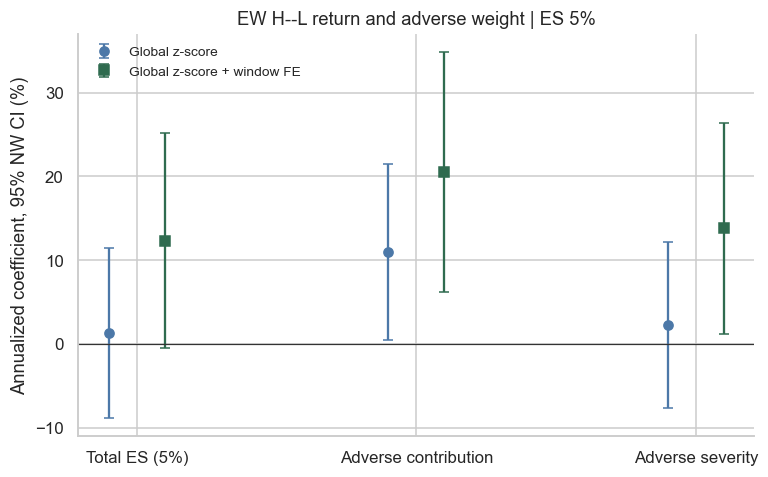

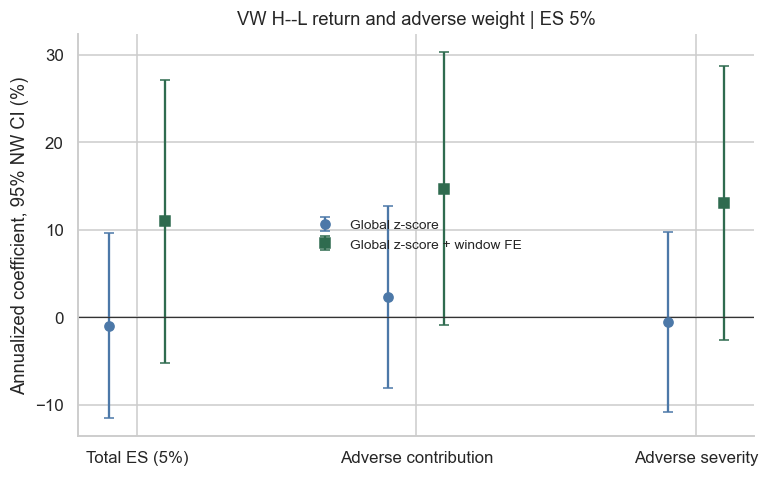

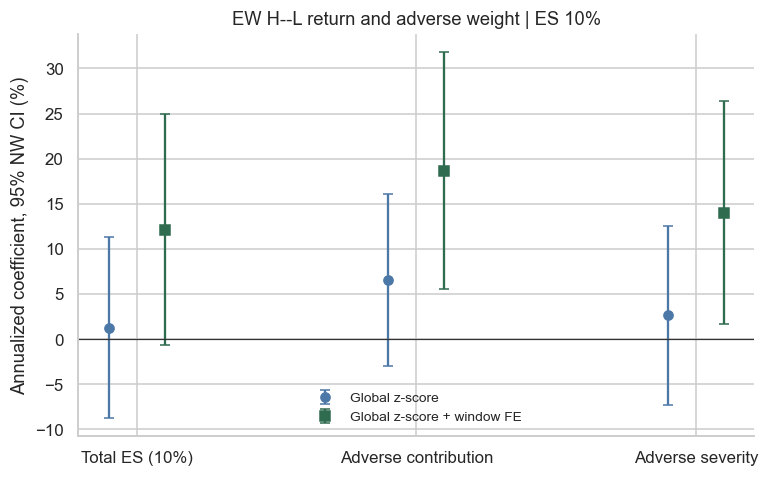

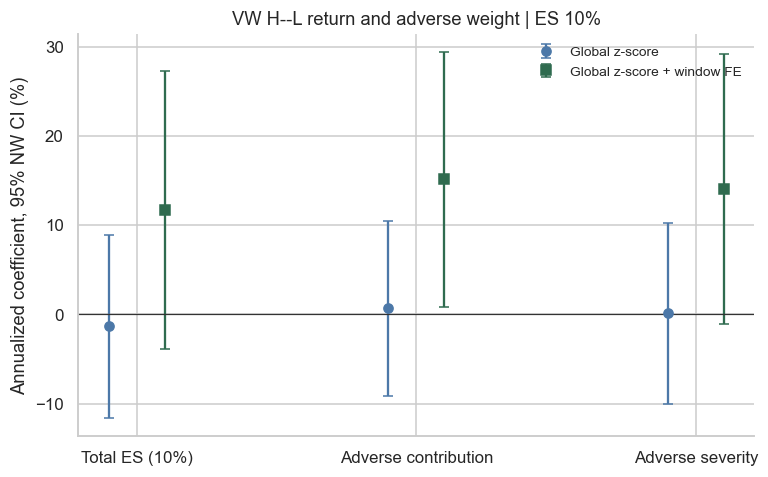

In [33]:
# ==========================================
# 8.2 图：三个 H--L premiums 的状态依赖系数
# ==========================================
for alpha in alphas:
    results = state_hml_continuous_by_alpha[alpha]
    signals = state_signal_names(alpha)

    for weighting in ["EW", "VW"]:
        fig, ax = plt.subplots(figsize=(7.2, 4.5))
        data = results[results["weighting"] == weighting]
        x = np.arange(len(signals))

        for offset, state_name, color, marker in [
            (-0.10, "Global z-score", "#4C78A8", "o"),
            (0.10, "Global z-score + window FE", "#2F6B4F", "s"),
        ]:
            state_data = (
                data[data["state_specification"] == state_name]
                .set_index("signal_name")
                .reindex(signals)
            )
            ax.errorbar(
                x + offset,
                state_data["annualized_coefficient_pct"],
                yerr=[
                    state_data["annualized_coefficient_pct"]
                    - state_data["ci_95_low_pct"],
                    state_data["ci_95_high_pct"]
                    - state_data["annualized_coefficient_pct"],
                ],
                fmt=marker,
                color=color,
                capsize=3,
                label=state_name,
            )

        ax.axhline(0, color="#333333", linewidth=0.8)
        ax.set(
            title=f"{weighting} H--L return and adverse weight | ES {alpha * 100:g}%",
            ylabel="Annualized coefficient, 95% NW CI (%)",
            xticks=x,
            xticklabels=signals,
            xlabel="",
        )
        ax.legend(frameon=False, fontsize=9)
        fig.tight_layout()
        fig.savefig(
            figure_dir
            / f"fig08_state_continuous_coefficients_{weighting}_alpha{alpha_suffix(alpha)}_{save_version}.pdf",
            dpi=220,
            bbox_inches="tight",
            pad_inches=0.02,
        )


In [34]:
fmb_monthly_slopes_by_alpha[0.05].query(
    "model_id == 'structured_normal_k3' and specification == 'Controls_1'"
).head()

,mthcaldt,model_id,model_label,signal_name,specification,signal_slope,r_squared,n_firms,beta_intercept,beta_z_signal,beta_z_mthcap_log,beta_z_bm,beta_z_MOM12m,beta_z_turnover,beta_z_mu_bench,beta_z_sigma_bench,beta_industry_0,beta_industry_1,beta_industry_2,beta_industry_3,beta_industry_4,beta_industry_5,beta_industry_6,beta_industry_7,beta_industry_8,beta_industry_9,beta_industry_10,beta_z_es_contribution_adverse_5,beta_z_severity_adverse_5
12098,2007-01-31,structured_normal_k3,Structured Normal K3,Total ES (5%),Controls_1,0.004106,0.007606,2692,0.005513,0.004106,-0.006199,0.002280,-0.003679,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12112,2007-02-28,structured_normal_k3,Structured Normal K3,Total ES (5%),Controls_1,0.006339,0.012005,2689,0.012627,0.006339,-0.000086,-0.002400,0.008304,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12126,2007-03-31,structured_normal_k3,Structured Normal K3,Total ES (5%),Controls_1,-0.004896,0.004060,2666,0.031542,-0.004896,0.004762,0.001329,0.003621,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12140,2007-04-30,structured_normal_k3,Structured Normal K3,Total ES (5%),Controls_1,0.004868,0.006460,2676,0.035642,0.004868,0.005430,-0.001807,-0.002471,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12154,2007-05-31,structured_normal_k3,Structured Normal K3,Total ES (5%),Controls_1,0.004472,0.013598,2678,-0.002735,0.004472,-0.012323,-0.002941,0.000538,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [35]:
# ==========================================
# 8.3 月度 Fama--MacBeth slope 对 adverse weight 的回归
# ==========================================
# 第一步的 signal_slope 来自每个月的横截面回归，并使用 Controls_1：
# size、book-to-market 和 momentum。
# 第二步检验该 slope 是否随当月 adverse weight 改变。
def monthly_slope_state_test(slopes, state, alpha):
    target_signals = [
        *state_signal_names(alpha),
        *state_diagnostic_signal_specs(alpha).keys(),
    ]
    selected = slopes[
        (slopes["model_id"] == "structured_normal_k3")
        & (slopes["specification"] == "Controls_1")
        & (slopes["signal_name"].isin(target_signals))
    ].merge(
        state[["mthcaldt", "window", "pi_adverse_global_z", "pi_adverse_within_z"]],
        on="mthcaldt",
        validate="many_to_one",
    )

    rows = []
    for signal_name, group in selected.groupby("signal_name", sort=False):
        data = group[
            ["signal_slope", "pi_adverse_global_z", "pi_adverse_within_z", "window"]
        ].dropna()

        for state_specification, state_col, add_window_fe in [
            ("Global z-score", "pi_adverse_global_z", False),
            ("Global z-score + window FE", "pi_adverse_global_z", True),
        ]:
            X = pd.DataFrame({"const": 1.0, state_col: data[state_col]})
            if add_window_fe:
                X = pd.concat(
                    [
                        X,
                        pd.get_dummies(
                            data["window"],
                            prefix="window",
                            drop_first=True,
                            dtype=float,
                        ),
                    ],
                    axis=1,
                )

            fit = sm.OLS(data["signal_slope"], X).fit(
                cov_type="HAC",
                cov_kwds={"maxlags": min(NW_LAGS, len(data) - 1)},
            )
            ci = fit.conf_int().loc[state_col]
            rows.append(
                {
                    "signal_name": signal_name,
                    "fmb_specification": "Controls_1",
                    "state_specification": state_specification,
                    "coefficient": fit.params[state_col],
                    "annualized_coefficient_pct": 1200 * fit.params[state_col],
                    "nw_t": fit.tvalues[state_col],
                    "p_value": fit.pvalues[state_col],
                    "ci_95_low_pct": 1200 * ci.iloc[0],
                    "ci_95_high_pct": 1200 * ci.iloc[1],
                    "months": int(fit.nobs),
                }
            )

    return pd.DataFrame(rows)


state_slope_regression_by_alpha = {}
for alpha in alphas:
    print(f"ES alpha = {alpha * 100:g}%")
    diagnostic_slopes = [
        run_fama_macbeth(
            pricing_base, signal_col, "structured_normal_k3",
            model_labels["structured_normal_k3"], signal_name,
        )
        for signal_name, signal_col in state_diagnostic_signal_specs(alpha).items()
    ]
    slopes_for_state_test = pd.concat(
        [fmb_monthly_slopes_by_alpha[alpha], *diagnostic_slopes],
        ignore_index=True,
    )
    state_slope_regression = monthly_slope_state_test(
        slopes_for_state_test,
        state_monthly_by_alpha[alpha],
        alpha,
    )
    state_slope_regression.to_parquet(
        result_dir
        / f"state_slope_regression_{timestamp}_alpha{alpha_suffix(alpha)}.parquet",
        index=False,
    )
    display(
        state_slope_regression[
            [
                "signal_name",
                "state_specification",
                "annualized_coefficient_pct",
                "nw_t",
                "p_value",
                "months",
            ]
        ].round(4)
    )
    state_slope_regression_by_alpha[alpha] = state_slope_regression


ES alpha = 5%


,signal_name,state_specification,annualized_coefficient_pct,nw_t,p_value,months
0,Total ES (5%),Global z-score,-0.3278,-0.2463,0.8054,216
1,Total ES (5%),Global z-score + window FE,2.3527,1.3693,0.1709,216
2,Adverse contribution,Global z-score,2.4330,1.8080,0.0706,216
3,Adverse contribution,Global z-score + window FE,4.6123,2.3246,0.0201,216
4,Adverse severity,Global z-score,0.1001,0.0733,0.9416,216
5,Adverse severity,Global z-score + window FE,2.9263,1.6763,0.0937,216
6,Adverse tail weight,Global z-score,-2.7695,-2.3289,0.0199,216
7,Adverse tail weight,Global z-score + window FE,-1.9724,-0.9670,0.3335,216
8,Normal contribution,Global z-score,0.6150,0.5425,0.5874,216
9,Normal contribution,Global z-score + window FE,3.1284,2.6025,0.0093,216


ES alpha = 10%


,signal_name,state_specification,annualized_coefficient_pct,nw_t,p_value,months
0,Total ES (10%),Global z-score,-0.2789,-0.2101,0.8336,216
1,Total ES (10%),Global z-score + window FE,2.4086,1.4281,0.1532,216
2,Adverse contribution,Global z-score,1.5233,1.1313,0.2579,216
3,Adverse contribution,Global z-score + window FE,4.0140,2.1390,0.0324,216
4,Adverse severity,Global z-score,0.2220,0.1617,0.8715,216
5,Adverse severity,Global z-score + window FE,3.0457,1.7419,0.0815,216
6,Adverse tail weight,Global z-score,-2.5121,-2.2050,0.0275,216
7,Adverse tail weight,Global z-score + window FE,-2.5556,-1.1999,0.2302,216
8,Normal contribution,Global z-score,-0.4996,-0.4288,0.6681,216
9,Normal contribution,Global z-score + window FE,2.4345,1.7985,0.0721,216


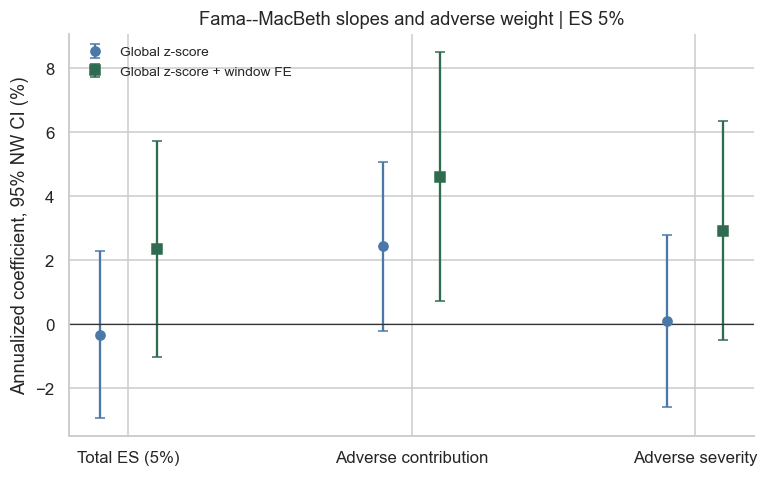

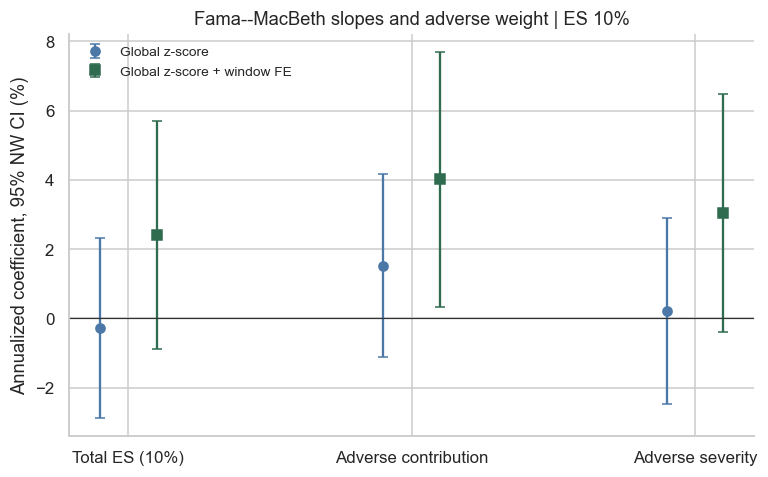

In [36]:
# ==========================================
# 8.3 图：三个 Fama--MacBeth slopes 的状态依赖系数
# ==========================================
for alpha in alphas:
    results = state_slope_regression_by_alpha[alpha]
    signals = state_signal_names(alpha)
    x = np.arange(len(signals))
    fig, ax = plt.subplots(figsize=(7.2, 4.5))

    for offset, state_name, color, marker in [
        (-0.10, "Global z-score", "#4C78A8", "o"),
        (0.10, "Global z-score + window FE", "#2F6B4F", "s"),
    ]:
        state_data = (
            results[results["state_specification"] == state_name]
            .set_index("signal_name")
            .reindex(signals)
        )
        ax.errorbar(
            x + offset,
            state_data["annualized_coefficient_pct"],
            yerr=[
                state_data["annualized_coefficient_pct"]
                - state_data["ci_95_low_pct"],
                state_data["ci_95_high_pct"]
                - state_data["annualized_coefficient_pct"],
            ],
            fmt=marker,
            color=color,
            capsize=3,
            label=state_name,
        )

    ax.axhline(0, color="#333333", linewidth=0.8)
    ax.set(
        title=f"Fama--MacBeth slopes and adverse weight | ES {alpha * 100:g}%",
        ylabel="Annualized coefficient, 95% NW CI (%)",
        xticks=x,
        xticklabels=signals,
        xlabel="",
    )
    ax.legend(frameon=False, fontsize=9)
    fig.tight_layout()
    fig.savefig(
        figure_dir
        / f"fig09_state_slope_coefficients_alpha{alpha_suffix(alpha)}_{save_version}.pdf",
        dpi=220,
        bbox_inches="tight",
        pad_inches=0.02,
    )


In [37]:
# ==========================================
# 8.4 个股层 pooled signal × adverse-weight interaction
# ==========================================
# 月份固定效应通过月内去均值实现。window FE 规格另外允许每个窗口有不同的基础 signal slope。
# 同时报告 month 和 month+firm 聚类标准误。
# interaction > 0 表示 adverse weight 较高时，该信号的收益 slope 更高。
def pooled_state_interaction(
    panel, signal_col, signal_name, state, cluster_on_firm=False
):
    required = ["permno", "mthcaldt", "target_ret_final", signal_col, *control_cols_1]
    work = (
        panel[required]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .copy()
    )
    work = standardize_monthly(work, [signal_col, *control_cols_1])
    work = work.merge(
        state[
            ["mthcaldt", "window", "pi_adverse_global_z", "pi_adverse_within_z"]
        ],
        on="mthcaldt",
        validate="many_to_one",
    )

    rows = []
    for state_specification, state_col, add_window_slope_fe in [
        ("Global z-score", "pi_adverse_global_z", False),
        ("Global z-score + window FE", "pi_adverse_global_z", True),
    ]:
        data = work.dropna(subset=[state_col]).copy()
        z_signal = f"z_{signal_col}"
        data["interaction"] = data[z_signal] * data[state_col]
        data["return_demeaned"] = (
            data["target_ret_final"]
            - data.groupby("mthcaldt")["target_ret_final"].transform("mean")
        )

        regressors = [
            z_signal,
            "interaction",
            *[f"z_{column}" for column in control_cols_1],
        ]
        if add_window_slope_fe:
            window_dummies = pd.get_dummies(
                data["window"], prefix="window", drop_first=True, dtype=float
            )
            for window_column in window_dummies.columns:
                interaction_column = f"{z_signal}_x_{window_column}"
                data[interaction_column] = data[z_signal] * window_dummies[window_column]
                regressors.append(interaction_column)

        month_clusters = pd.factorize(data["mthcaldt"])[0]
        if cluster_on_firm:
            cluster_groups = np.column_stack(
                [month_clusters, pd.factorize(data["permno"])[0]]
            )
            cluster_type = "Month + firm"
        else:
            cluster_groups = month_clusters
            cluster_type = "Month"

        fit = sm.OLS(data["return_demeaned"], data[regressors]).fit(
            cov_type="cluster",
            cov_kwds={"groups": cluster_groups},
        )
        confidence_intervals = fit.conf_int()

        for parameter in regressors:
            rows.append(
                {
                    "signal_name": signal_name,
                    "control_specification": "Controls_1",
                    "cluster_type": cluster_type,
                    "state_specification": state_specification,
                    "state_variable": state_col,
                    "parameter": parameter,
                    "coefficient": fit.params[parameter],
                    "annualized_coefficient_pct": 1200 * fit.params[parameter],
                    "cluster_t": fit.tvalues[parameter],
                    "p_value": fit.pvalues[parameter],
                    "ci_95_low_pct": 1200
                    * confidence_intervals.loc[parameter].iloc[0],
                    "ci_95_high_pct": 1200
                    * confidence_intervals.loc[parameter].iloc[1],
                    "observations": int(fit.nobs),
                    "months": data["mthcaldt"].nunique(),
                }
            )

    return pd.DataFrame(rows)


pooled_interactions_by_alpha = {}
for alpha in alphas:
    print(f"ES alpha = {alpha * 100:g}%")
    state_monthly = state_monthly_by_alpha[alpha]
    structured_es_panel = load_model_panel("structured_normal_k3", alpha)

    pooled_specs = [
        (structured_es_panel, "signal", f"Total ES ({alpha * 100:g}%)"),
        (pricing_base, f"es_contribution_adverse_{alpha_suffix(alpha)}", "Adverse contribution"),
        (pricing_base, f"severity_adverse_{alpha_suffix(alpha)}", "Adverse severity"),
        *[
            (pricing_base, signal_col, signal_name)
            for signal_name, signal_col in state_diagnostic_signal_specs(alpha).items()
        ],
    ]
    pooled_interactions = pd.concat(
        [
            pooled_state_interaction(
                panel, signal_col, signal_name, state_monthly,
                cluster_on_firm=cluster_on_firm,
            )
            for panel, signal_col, signal_name in pooled_specs
            for cluster_on_firm in [False, True]
        ],
        ignore_index=True,
    )
    pooled_interactions.to_parquet(
        result_dir
        / f"pooled_interactions_{timestamp}_alpha{alpha_suffix(alpha)}.parquet",
        index=False,
    )
    display(
        pooled_interactions.loc[
            pooled_interactions["parameter"] == "interaction",
            [
                "signal_name",
                "state_specification",
                "cluster_type",
                "annualized_coefficient_pct",
                "cluster_t",
                "p_value",
                "observations",
                "months",
            ],
        ].round(4)
    )
    pooled_interactions_by_alpha[alpha] = pooled_interactions


ES alpha = 5%


,signal_name,state_specification,cluster_type,annualized_coefficient_pct,cluster_t,p_value,observations,months
1,Total ES (5%),Global z-score,Month,0.0992,0.0684,0.9455,448935,216
6,Total ES (5%),Global z-score + window FE,Month,3.3356,1.5526,0.1205,448935,216
28,Total ES (5%),Global z-score,Month + firm,0.0992,0.0684,0.9455,448935,216
33,Total ES (5%),Global z-score + window FE,Month + firm,3.3356,1.5534,0.1203,448935,216
55,Adverse contribution,Global z-score,Month,2.6192,1.8344,0.0666,448935,216
60,Adverse contribution,Global z-score + window FE,Month,5.8447,2.4883,0.0128,448935,216
82,Adverse contribution,Global z-score,Month + firm,2.6192,1.8356,0.0664,448935,216
87,Adverse contribution,Global z-score + window FE,Month + firm,5.8447,2.4913,0.0127,448935,216
109,Adverse severity,Global z-score,Month,0.4034,0.2746,0.7836,448935,216
114,Adverse severity,Global z-score + window FE,Month,3.7979,1.7259,0.0844,448935,216


ES alpha = 10%


,signal_name,state_specification,cluster_type,annualized_coefficient_pct,cluster_t,p_value,observations,months
1,Total ES (10%),Global z-score,Month,0.1168,0.0803,0.9360,448935,216
6,Total ES (10%),Global z-score + window FE,Month,3.3303,1.5335,0.1251,448935,216
28,Total ES (10%),Global z-score,Month + firm,0.1168,0.0803,0.9360,448935,216
33,Total ES (10%),Global z-score + window FE,Month + firm,3.3303,1.5344,0.1249,448935,216
55,Adverse contribution,Global z-score,Month,1.5854,1.0686,0.2853,448935,216
60,Adverse contribution,Global z-score + window FE,Month,5.3130,2.2532,0.0242,448935,216
82,Adverse contribution,Global z-score,Month + firm,1.5854,1.0693,0.2849,448935,216
87,Adverse contribution,Global z-score + window FE,Month + firm,5.3130,2.2555,0.0241,448935,216
109,Adverse severity,Global z-score,Month,0.4935,0.3350,0.7376,448935,216
114,Adverse severity,Global z-score + window FE,Month,3.9209,1.7670,0.0772,448935,216


In [38]:
# ==========================================
# 8.5 Leave-one-window-out：adverse contribution
# ==========================================
def leave_one_window_out_contribution(slopes, state, alpha):
    signal_name = "Adverse contribution"
    data = slopes[
        (slopes["model_id"] == "structured_normal_k3")
        & (slopes["signal_name"] == signal_name)
        & (slopes["specification"] == "Controls_1")
    ].merge(
        state[["mthcaldt", "window", "pi_adverse_global_z"]],
        on="mthcaldt",
        validate="one_to_one",
    ).dropna(subset=["signal_slope", "pi_adverse_global_z"])

    rows = []
    for omitted_window in sorted(data["window"].unique()):
        sample = data[data["window"] != omitted_window].copy()
        X = pd.DataFrame({
            "const": 1.0,
            "pi_adverse_global_z": sample["pi_adverse_global_z"],
        })
        X = pd.concat(
            [
                X,
                pd.get_dummies(
                    sample["window"], prefix="window", drop_first=True, dtype=float
                ),
            ],
            axis=1,
        )
        fit = sm.OLS(sample["signal_slope"], X).fit(
            cov_type="HAC",
            cov_kwds={"maxlags": min(NW_LAGS, len(sample) - 1)},
        )
        rows.append({
            "alpha": alpha,
            "omitted_window": omitted_window,
            "annualized_coefficient_pct": 1200 * fit.params["pi_adverse_global_z"],
            "nw_t": fit.tvalues["pi_adverse_global_z"],
            "p_value": fit.pvalues["pi_adverse_global_z"],
            "months": int(fit.nobs),
        })
    return pd.DataFrame(rows)


state_slope_loo_by_alpha = {}
for alpha in alphas:
    loo = leave_one_window_out_contribution(
        fmb_monthly_slopes_by_alpha[alpha],
        state_monthly_by_alpha[alpha],
        alpha,
    )
    loo.to_parquet(
        result_dir
        / f"state_slope_loo_{timestamp}_alpha{alpha_suffix(alpha)}.parquet",
        index=False,
    )
    summary = pd.DataFrame({
        "alpha": [alpha],
        "minimum_coefficient_pct": [loo["annualized_coefficient_pct"].min()],
        "maximum_coefficient_pct": [loo["annualized_coefficient_pct"].max()],
        "share_positive": [(loo["annualized_coefficient_pct"] > 0).mean()],
        "minimum_t": [loo["nw_t"].min()],
        "maximum_t": [loo["nw_t"].max()],
        "omitted_windows": [len(loo)],
    })
    display(summary.round(4))
    state_slope_loo_by_alpha[alpha] = loo


,alpha,minimum_coefficient_pct,maximum_coefficient_pct,share_positive,minimum_t,maximum_t,omitted_windows
0,0.05,2.9872,5.4682,1.0,1.5331,2.817,18


,alpha,minimum_coefficient_pct,maximum_coefficient_pct,share_positive,minimum_t,maximum_t,omitted_windows
0,0.1,2.415,4.8484,1.0,1.2995,2.5905,18


### 8.6 Joint component horse-race regression

This regression includes the adverse, normal, and favorable ES contributions at the same time. Each contribution is interacted with the global adverse-weight z-score. The main specification also allows each contribution to have a different base slope in every rolling window. The pairwise Wald tests examine whether the adverse interaction coefficient equals the normal or favorable interaction coefficient. The joint Wald test examines whether all three interaction coefficients are equal.

In [39]:
# ==========================================
# 8.6 Joint horse race: three component contributions
# ==========================================
# Regression:
#   next return = component levels
#               + component x adverse-weight interactions
#               + Controls_1
#               + month FE
#               + component x window FE
#
# The three component interactions are estimated together.
# Therefore, each interaction coefficient measures the state dependence
# of that component while holding the other two components fixed.

def joint_component_horse_race(
    panel, state, alpha, cluster_on_firm=False
):
    suffix = alpha_suffix(alpha)
    component_columns = {
        "Adverse contribution": f"es_contribution_adverse_{suffix}",
        "Normal contribution": f"es_contribution_normal_{suffix}",
        "Favorable contribution": f"es_contribution_favorable_{suffix}",
    }

    # Keep one common sample for all three components and Controls_1.
    required_columns = [
        "permno",
        "mthcaldt",
        "target_ret_final",
        *component_columns.values(),
        *control_cols_1,
    ]
    data = (
        panel[required_columns]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .copy()
    )

    # Winsorize and standardize every firm-level variable within month.
    variables_to_standardize = [
        *component_columns.values(),
        *control_cols_1,
    ]
    data = standardize_monthly(data, variables_to_standardize)
    data = data.merge(
        state[["mthcaldt", "window", "pi_adverse_global_z"]],
        on="mthcaldt",
        validate="many_to_one",
    )

    # Month fixed effects are absorbed by demeaning returns within month.
    data["return_demeaned"] = (
        data["target_ret_final"]
        - data.groupby("mthcaldt")["target_ret_final"].transform("mean")
    )

    component_z_columns = {
        component_name: f"z_{component_column}"
        for component_name, component_column in component_columns.items()
    }

    # Create one state interaction for each component.
    interaction_columns = {}
    for component_name, component_z in component_z_columns.items():
        interaction_column = f"interaction_{component_name.split()[0].lower()}"
        data[interaction_column] = (
            data[component_z] * data["pi_adverse_global_z"]
        )
        interaction_columns[component_name] = interaction_column

    regressors = [
        *component_z_columns.values(),
        *interaction_columns.values(),
        *[f"z_{column}" for column in control_cols_1],
    ]

    # Window fixed effects in a slope regression must be interacted with
    # each component. This allows the base price of every component to
    # differ across rolling estimation windows.
    window_dummies = pd.get_dummies(
        data["window"], prefix="window", drop_first=True, dtype=float
    )
    for component_name, component_z in component_z_columns.items():
        short_name = component_name.split()[0].lower()
        for window_column in window_dummies.columns:
            slope_fe_column = f"{short_name}_x_{window_column}"
            data[slope_fe_column] = (
                data[component_z] * window_dummies[window_column]
            )
            regressors.append(slope_fe_column)

    # Report both month clustering and month + firm two-way clustering.
    month_clusters = pd.factorize(data["mthcaldt"])[0]
    if cluster_on_firm:
        cluster_groups = np.column_stack(
            [month_clusters, pd.factorize(data["permno"])[0]]
        )
        cluster_type = "Month + firm"
    else:
        cluster_groups = month_clusters
        cluster_type = "Month"

    fit = sm.OLS(data["return_demeaned"], data[regressors]).fit(
        cov_type="cluster",
        cov_kwds={"groups": cluster_groups},
    )

    # Table 1: the three interaction coefficients from the joint regression.
    coefficient_rows = []
    confidence_intervals = fit.conf_int()
    for component_name, interaction_column in interaction_columns.items():
        ci = confidence_intervals.loc[interaction_column]
        coefficient_rows.append({
            "alpha": alpha,
            "component": component_name,
            "parameter": interaction_column,
            "cluster_type": cluster_type,
            "coefficient": fit.params[interaction_column],
            "annualized_coefficient_pct": 1200 * fit.params[interaction_column],
            "cluster_t": fit.tvalues[interaction_column],
            "p_value": fit.pvalues[interaction_column],
            "ci_95_low_pct": 1200 * ci.iloc[0],
            "ci_95_high_pct": 1200 * ci.iloc[1],
            "observations": int(fit.nobs),
            "months": data["mthcaldt"].nunique(),
        })

    # Table 2: pairwise Wald tests.
    # H0: adverse interaction = comparison-channel interaction.
    parameter_names = list(fit.params.index)
    adverse_parameter = interaction_columns["Adverse contribution"]
    comparison_rows = []

    for comparison_component in [
        "Normal contribution",
        "Favorable contribution",
    ]:
        comparison_parameter = interaction_columns[comparison_component]
        contrast = np.zeros(len(parameter_names))
        contrast[parameter_names.index(adverse_parameter)] = 1.0
        contrast[parameter_names.index(comparison_parameter)] = -1.0
        test = fit.t_test(contrast)
        difference_ci = np.asarray(test.conf_int()).reshape(-1)

        comparison_rows.append({
            "alpha": alpha,
            "null_hypothesis": (
                f"Adverse interaction = {comparison_component}"
            ),
            "cluster_type": cluster_type,
            "annualized_difference_pct": (
                1200 * np.asarray(test.effect).item()
            ),
            "test_statistic": np.asarray(test.tvalue).item(),
            "p_value": np.asarray(test.pvalue).item(),
            "ci_95_low_pct": 1200 * difference_ci[0],
            "ci_95_high_pct": 1200 * difference_ci[1],
        })

    # Joint Wald test:
    # H0: adverse = normal = favorable interaction coefficient.
    joint_contrast = np.zeros((2, len(parameter_names)))
    normal_parameter = interaction_columns["Normal contribution"]
    favorable_parameter = interaction_columns["Favorable contribution"]
    joint_contrast[0, parameter_names.index(adverse_parameter)] = 1.0
    joint_contrast[0, parameter_names.index(normal_parameter)] = -1.0
    joint_contrast[1, parameter_names.index(adverse_parameter)] = 1.0
    joint_contrast[1, parameter_names.index(favorable_parameter)] = -1.0
    joint_test = fit.wald_test(joint_contrast, scalar=True)

    joint_test_row = pd.DataFrame([{
        "alpha": alpha,
        "null_hypothesis": "Adverse = normal = favorable interactions",
        "cluster_type": cluster_type,
        "wald_statistic": np.asarray(joint_test.statistic).item(),
        "restrictions": 2,
        "p_value": np.asarray(joint_test.pvalue).item(),
    }])

    return (
        pd.DataFrame(coefficient_rows),
        pd.DataFrame(comparison_rows),
        joint_test_row,
    )


joint_component_coefficients_by_alpha = {}
joint_component_comparisons_by_alpha = {}
joint_component_wald_by_alpha = {}

for alpha in alphas:
    coefficient_tables = []
    comparison_tables = []
    joint_test_tables = []

    for cluster_on_firm in [False, True]:
        coefficients, comparisons, joint_test = joint_component_horse_race(
            pricing_base,
            state_monthly_by_alpha[alpha],
            alpha,
            cluster_on_firm=cluster_on_firm,
        )
        coefficient_tables.append(coefficients)
        comparison_tables.append(comparisons)
        joint_test_tables.append(joint_test)

    joint_coefficients = pd.concat(coefficient_tables, ignore_index=True)
    pairwise_tests = pd.concat(comparison_tables, ignore_index=True)
    joint_wald_test = pd.concat(joint_test_tables, ignore_index=True)

    joint_coefficients.to_parquet(
        result_dir
        / f"joint_component_coefficients_{timestamp}_alpha{alpha_suffix(alpha)}.parquet",
        index=False,
    )
    pairwise_tests.to_parquet(
        result_dir
        / f"joint_component_pairwise_tests_{timestamp}_alpha{alpha_suffix(alpha)}.parquet",
        index=False,
    )
    joint_wald_test.to_parquet(
        result_dir
        / f"joint_component_wald_test_{timestamp}_alpha{alpha_suffix(alpha)}.parquet",
        index=False,
    )

    print(f"ES alpha = {alpha * 100:g}%")
    print("Joint interaction coefficients")
    display(joint_coefficients[[
        "component",
        "cluster_type",
        "annualized_coefficient_pct",
        "cluster_t",
        "p_value",
    ]].round(4))
    print("Pairwise Wald tests")
    display(pairwise_tests.round(4))
    print("Joint Wald test")
    display(joint_wald_test.round(4))

    joint_component_coefficients_by_alpha[alpha] = joint_coefficients
    joint_component_comparisons_by_alpha[alpha] = pairwise_tests
    joint_component_wald_by_alpha[alpha] = joint_wald_test


ES alpha = 5%
Joint interaction coefficients


,component,cluster_type,annualized_coefficient_pct,cluster_t,p_value
0,Adverse contribution,Month,5.6483,2.0282,0.0425
1,Normal contribution,Month,-0.4114,-0.2127,0.8315
2,Favorable contribution,Month,-0.0190,-0.0127,0.9899
3,Adverse contribution,Month + firm,5.6483,2.0307,0.0423
4,Normal contribution,Month + firm,-0.4114,-0.2127,0.8316
5,Favorable contribution,Month + firm,-0.0190,-0.0127,0.9898


Pairwise Wald tests


,alpha,null_hypothesis,cluster_type,annualized_difference_pct,test_statistic,p_value,ci_95_low_pct,ci_95_high_pct
0,0.05,Adverse interaction = Normal contribution,Month,6.0598,1.5254,0.1272,-1.7263,13.8458
1,0.05,Adverse interaction = Favorable contribution,Month,5.6673,1.6452,0.0999,-1.0844,12.4190
2,0.05,Adverse interaction = Normal contribution,Month + firm,6.0598,1.5256,0.1271,-1.7253,13.8449
3,0.05,Adverse interaction = Favorable contribution,Month + firm,5.6673,1.6485,0.0993,-1.0709,12.4055


Joint Wald test


...

,component,cluster_type,annualized_coefficient_pct,cluster_t,p_value
0,Adverse contribution,Month,4.0110,1.3511,0.1766
1,Normal contribution,Month,0.8904,0.4145,0.6785
2,Favorable contribution,Month,-0.5061,-0.3183,0.7503
3,Adverse contribution,Month + firm,4.0110,1.3530,0.1761
4,Normal contribution,Month + firm,0.8904,0.4138,0.6790
5,Favorable contribution,Month + firm,-0.5061,-0.3194,0.7494


Pairwise Wald tests


,alpha,null_hypothesis,cluster_type,annualized_difference_pct,test_statistic,p_value,ci_95_low_pct,ci_95_high_pct
0,0.1,Adverse interaction = Normal contribution,Month,3.1207,0.7112,0.4770,-5.4793,11.7207
1,0.1,Adverse interaction = Favorable contribution,Month,4.5171,1.2057,0.2279,-2.8261,11.8603
2,0.1,Adverse interaction = Normal contribution,Month + firm,3.1207,0.7112,0.4770,-5.4799,11.7213
3,0.1,Adverse interaction = Favorable contribution,Month + firm,4.5171,1.2084,0.2269,-2.8096,11.8438


Joint Wald test


,alpha,null_hypothesis,cluster_type,wald_statistic,restrictions,p_value
0,0.1,Adverse = normal = favorable interactions,Month,1.5327,2,0.4647
1,0.1,Adverse = normal = favorable interactions,Month + firm,1.5409,2,0.4628


## 9. Structured ES 稳健性

只对预先固定的 Structured K3 检查：`alphas` 中的 ES、五组/十组、NYSE/全样本 breakpoints，以及是否排除 NYSE size 第20百分位以下的 microcaps。该部分不能用于重新选择主模型。

In [40]:
# ==========================================
# 9.1 组合设计稳健性
# ==========================================
robustness_summary_by_alpha = {}
for alpha in alphas:
    print(f"ES alpha = {alpha * 100:g}%")
    robustness_hml_parts = []

    panel = load_model_panel("structured_normal_k3",alpha,)
    for n_groups in [5, 10]:
        for robust_breakpoint_universe in ["NYSE", "All"]:
            for robust_exclude_microcaps in [False, True]:
                portfolios = sort_portfolios(
                    panel=panel,
                    signal_col="signal",
                    n_groups=n_groups,
                    me_breakpoints_df=me_breakpoints,
                    exclude_microcaps=robust_exclude_microcaps,
                    breakpoint_universe=robust_breakpoint_universe,
                )
                metadata = {
                    "model_id": "structured_normal_k3",
                    "model_label": "Structured Normal K3",
                    "signal_name": f"Total ES ({alpha * 100:g}%)",
                    "n_groups": n_groups,
                    "exclude_microcaps": robust_exclude_microcaps,
                    "breakpoint_universe": robust_breakpoint_universe,
                }
                for key, value in metadata.items():
                    portfolios[key] = value
                hml = build_hml(portfolios, metadata)
                hml["alpha"] = alpha
                robustness_hml_parts.append(hml)

    robustness_hml = pd.concat(robustness_hml_parts, ignore_index=True)
    robustness_summary = summarize_hml(robustness_hml)
    robustness_summary["alpha"] = alpha
    robustness_summary["design"] = (
        robustness_summary["n_groups"].astype(str)
        + " groups | "
        + robustness_summary["breakpoint_universe"]
        + " | "
        + np.where(
            robustness_summary["exclude_microcaps"],
            "no microcaps",
            "all caps",
        )
    )
    # display_cols = [
    #     "alpha",
    #     "n_groups",
    #     "breakpoint_universe",
    #     "exclude_microcaps",
    #     "weighting",
    #     "annualized_mean_pct",
    #     "nw_t",
    #     "p_value",
    # ]
    # display(robustness_summary[display_cols].round(4))
    robustness_summary.to_parquet(result_dir / f"robustness_summary_{timestamp}_alpha{alpha_suffix(alpha)}.parquet", index=False)
    display(robustness_summary.round(4))

    robustness_summary_by_alpha[alpha] = robustness_summary


ES alpha = 5%


,model_id,model_label,signal_name,weighting,n_groups,exclude_microcaps,breakpoint_universe,mean_monthly,nw_se,nw_t,p_value,ci_95_low,ci_95_high,months,annualized_mean_pct,annualized_ci_low_pct,annualized_ci_high_pct,alpha,design
0,structured_normal_k3,Structured Normal K3,Total ES (5%),EW,5,False,All,0.0072,0.0046,1.5566,0.1196,-0.0019,0.0162,216,8.6037,-2.2294,19.4368,0.05,5 groups | All | all caps
1,structured_normal_k3,Structured Normal K3,Total ES (5%),EW,5,False,NYSE,0.0037,0.0044,0.8439,0.3987,-0.0049,0.0122,216,4.4236,-5.8502,14.6974,0.05,5 groups | NYSE | all caps
2,structured_normal_k3,Structured Normal K3,Total ES (5%),EW,5,True,All,0.0017,0.0043,0.3925,0.6947,-0.0067,0.0101,216,2.0207,-8.0703,12.1117,0.05,5 groups | All | no microcaps
3,structured_normal_k3,Structured Normal K3,Total ES (5%),EW,5,True,NYSE,0.0007,0.0042,0.1632,0.8703,-0.0075,0.0089,216,0.8217,-9.0444,10.6879,0.05,5 groups | NYSE | no microcaps
4,structured_normal_k3,Structured Normal K3,Total ES (5%),EW,10,False,All,0.0115,0.0054,2.1296,0.0332,0.0009,0.0221,216,13.8286,1.1012,26.5560,0.05,10 groups | All | all caps
5,structured_normal_k3,Structured Normal K3,Total ES (5%),EW,10,False,NYSE,0.0055,0.0054,1.0329,0.3016,-0.0050,0.0160,216,6.6377,-5.9575,19.2328,0.05,10 groups | NYSE | all caps
6,structured_normal_k3,Structured Normal K3,Total ES (5%),EW,10,True,All,0.0032,0.0051,0.6264,0.5311,-0.0068,0.0131,216,3.8110,-8.1135,15.7355,0.05,10 groups | All | no microcaps
7,structured_normal_k3,Structured Normal K3,Total ES (5%),EW,10,True,NYSE,0.0015,0.0052,0.2787,0.7805,-0.0088,0.0117,216,1.7472,-10.5425,14.0369,0.05,10 groups | NYSE | no microcaps
8,structured_normal_k3,Structured Normal K3,Total ES (5%),VW,5,False,All,0.0029,0.0051,0.5760,0.5646,-0.0070,0.0129,216,3.5149,-8.4458,15.4756,0.05,5 groups | All | all caps
9,structured_normal_k3,Structured Normal K3,Total ES (5%),VW,5,False,NYSE,0.0002,0.0044,0.0368,0.9706,-0.0084,0.0087,216,0.1933,-10.1024,10.4890,0.05,5 groups | NYSE | all caps


ES alpha = 10%


,model_id,model_label,signal_name,weighting,n_groups,exclude_microcaps,breakpoint_universe,mean_monthly,nw_se,nw_t,p_value,ci_95_low,ci_95_high,months,annualized_mean_pct,annualized_ci_low_pct,annualized_ci_high_pct,alpha,design
0,structured_normal_k3,Structured Normal K3,Total ES (10%),EW,5,False,All,0.0071,0.0046,1.5559,0.1197,-0.0018,0.0161,216,8.5345,-2.2169,19.2859,0.1,5 groups | All | all caps
1,structured_normal_k3,Structured Normal K3,Total ES (10%),EW,5,False,NYSE,0.0037,0.0044,0.8395,0.4012,-0.0049,0.0122,216,4.3995,-5.8723,14.6714,0.1,5 groups | NYSE | all caps
2,structured_normal_k3,Structured Normal K3,Total ES (10%),EW,5,True,All,0.0019,0.0042,0.4363,0.6626,-0.0065,0.0102,216,2.2249,-7.7711,12.2209,0.1,5 groups | All | no microcaps
3,structured_normal_k3,Structured Normal K3,Total ES (10%),EW,5,True,NYSE,0.0009,0.0042,0.2249,0.8221,-0.0072,0.0091,216,1.1235,-8.6694,10.9163,0.1,5 groups | NYSE | no microcaps
4,structured_normal_k3,Structured Normal K3,Total ES (10%),EW,10,False,All,0.0116,0.0054,2.1705,0.0300,0.0011,0.0221,216,13.9577,1.3535,26.5620,0.1,10 groups | All | all caps
5,structured_normal_k3,Structured Normal K3,Total ES (10%),EW,10,False,NYSE,0.0059,0.0053,1.0981,0.2722,-0.0046,0.0164,216,7.0480,-5.5323,19.6283,0.1,10 groups | NYSE | all caps
6,structured_normal_k3,Structured Normal K3,Total ES (10%),EW,10,True,All,0.0031,0.0051,0.6044,0.5456,-0.0069,0.0130,216,3.6662,-8.2234,15.5558,0.1,10 groups | All | no microcaps
7,structured_normal_k3,Structured Normal K3,Total ES (10%),EW,10,True,NYSE,0.0018,0.0053,0.3377,0.7356,-0.0086,0.0121,216,2.1363,-10.2624,14.5349,0.1,10 groups | NYSE | no microcaps
8,structured_normal_k3,Structured Normal K3,Total ES (10%),VW,5,False,All,0.0039,0.0050,0.7882,0.4306,-0.0059,0.0138,216,4.7347,-7.0384,16.5077,0.1,5 groups | All | all caps
9,structured_normal_k3,Structured Normal K3,Total ES (10%),VW,5,False,NYSE,0.0000,0.0045,0.0032,0.9975,-0.0088,0.0088,216,0.0172,-10.5687,10.6032,0.1,5 groups | NYSE | all caps


ES alpha = 5%
ES alpha = 10%


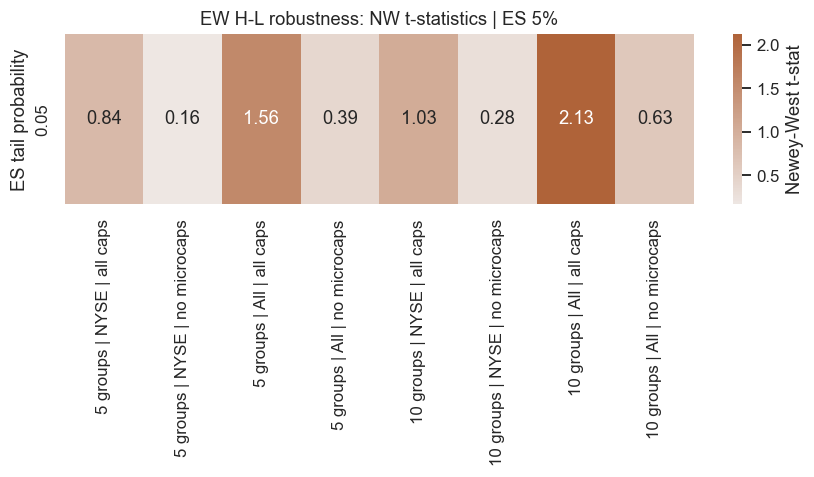

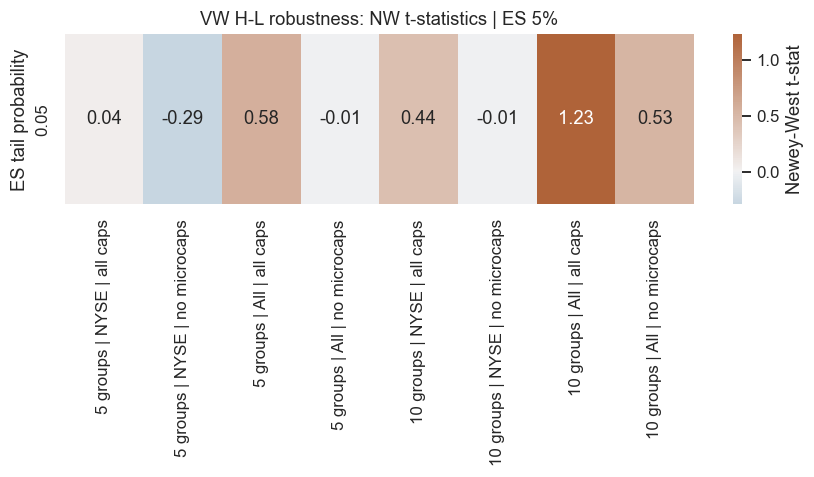

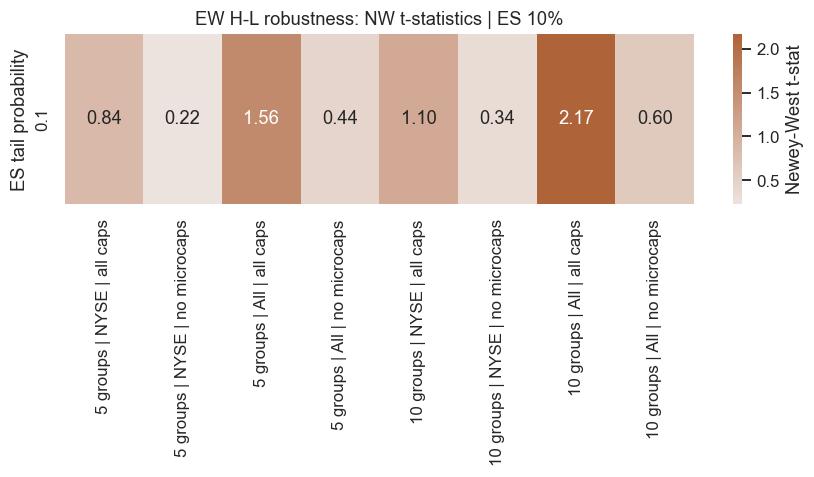

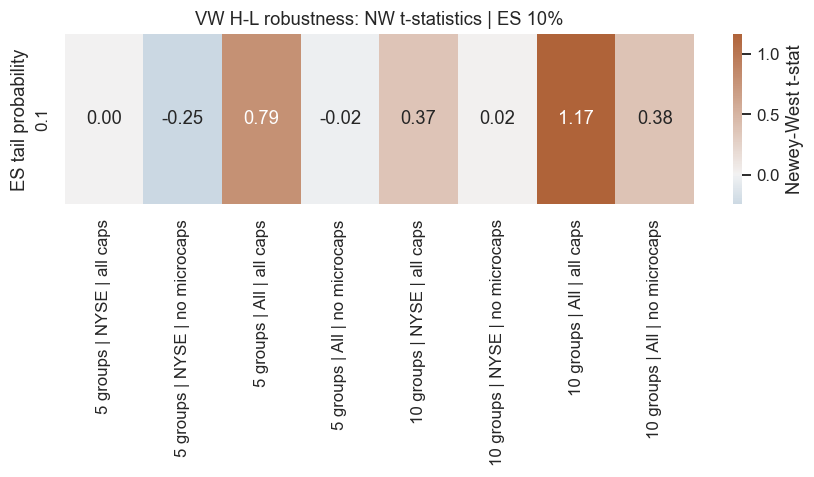

In [41]:
# ==========================================
# 9.2 图：稳健性设计中的 H-L t-statistics
# ==========================================
for alpha in alphas:
    print(f"ES alpha = {alpha * 100:g}%")
    robustness_summary = robustness_summary_by_alpha[alpha]
    design_order = [
        f"{groups} groups | {bp} | {cap}"
        for groups in [5, 10] for bp in ["NYSE", "All"] for cap in ["all caps", "no microcaps"]
    ]


    for weighting in ["EW", "VW"]:
        fig, ax = plt.subplots(figsize=(8, 4.5))
        heat = robustness_summary[robustness_summary["weighting"] == weighting].pivot(index="alpha", columns="design", values="nw_t")
        heat = heat.reindex(index=[alpha], columns=design_order)
        sns.heatmap(
            heat, annot=True, fmt=".2f", center=0,
            cmap=sns.diverging_palette(240, 30, as_cmap=True), cbar_kws={"label": "Newey-West t-stat"}, ax=ax,
        )
        ax.set(
            title=f"{weighting} H-L robustness: NW t-statistics | ES {alpha * 100:g}%", 
            xlabel="", ylabel="ES tail probability")
        fig.tight_layout()
        # fig.suptitle("Structured K3 portfolio-sort robustness", y=1.01)
        fig.savefig(figure_dir / f"fig10_robustness_heatmap_{weighting}_alpha{alpha_suffix(alpha)}_{save_version}.pdf", dpi=220, bbox_inches="tight", pad_inches=0.02)



## 10. Adverse weight 的经济验证

这里区分两类证据：当期 VIX 和信用利差只用于解释 `pi_adverse` 的经济含义；下一月市场收益、坏市场概率和股票横截面尾部损失才是样本外状态验证。坏市场定义为样本外市场超额收益最低的 10% 月份。

作者想证明：我算出来的这个 pi_adverse（不利状态概率/权重），不仅能用来选股，它本身还是一个极其敏锐的宏观风险预测指标。

crash_share：下个月市场, 跌幅超过 20% 的股票占比有多少？（全市场有多惨）。

cross_section_tail_return：下一月收益最低的 5% 股票的平均收益，亏损保留负数。

bad_market：下个月的大盘收益是不是处于历史最差的 10% 以内？（0 或 1）。

代码计算了你发明的 pi_adverse 指标与 VIX、信用利差等传统指标的相关系数 (state_macro_correlations)。


In [42]:
# ==========================================
# 10.1 构建下一月市场和横截面尾部结果
# ==========================================
# 10.1 构建下一月市场和横截面尾部结果
# ==========================================
# 这段代码的核心目的是对量化模型中预测的“市场尾部风险/不利状态（Adverse State）”进行事后检验与宏观经济学验证（Sanity Check）。
# 它将模型预测结果与真实世界的宏观经济指标（如恐慌指数、信用利差）、市场真实崩盘表现(下个月)进行了对齐，并计算了它们之间的关联度。
state_validation_by_alpha = {}
for alpha in alphas:
    print(f"ES alpha = {alpha * 100:g}%")
    state_monthly = state_monthly_by_alpha[alpha]
    macro_data = pd.read_parquet(project_root / 'data/macro_data.parquet', columns=["mthcaldt", "VIXCLS", "CREDIT_SPREAD", "TERM_SPREAD"]) 
    macro_data["mthcaldt"] = pd.to_datetime(macro_data["mthcaldt"])

    realized_tail = pricing_base.groupby("mthcaldt", as_index=False).agg(
        crash_share=("target_ret_final", lambda x: np.mean(x < -0.20)),
        cross_section_tail_return=("target_ret_final", lambda x: x[x <= x.quantile(alpha)].mean()),
    )
    state_validation = state_monthly.copy()
    state_validation["return_date"] = state_validation["mthcaldt"] + pd.offsets.MonthEnd(1)
    state_validation = state_validation.merge(
        factor_data[["return_date", "mktrf_ff5"]], on="return_date", validate="one_to_one"
    ).merge(realized_tail, on="mthcaldt", validate="one_to_one"
    ).merge(macro_data, on="mthcaldt", how="left", validate="one_to_one"
            )
    state_validation["bad_market"] = (state_validation["mktrf_ff5"] <= state_validation["mktrf_ff5"].quantile(0.10)).astype(int)

    macro_cols = ["VIXCLS", "CREDIT_SPREAD", "TERM_SPREAD"]
    macro_within = state_validation[["window", "pi_adverse_within_z", *macro_cols]].copy()
    for column in macro_cols:
        macro_within[column] = macro_within[column] - macro_within.groupby("window")[column].transform("mean")
    state_macro_correlations = macro_within[["pi_adverse_within_z", *macro_cols]].corr()
    state_macro_correlations.to_parquet(result_dir / f"state_macro_correlations_{timestamp}_alpha{alpha_suffix(alpha)}.parquet", index=True)
    display(state_macro_correlations.round(3))

    state_validation_by_alpha[alpha] = state_validation


ES alpha = 5%


,pi_adverse_within_z,VIXCLS,CREDIT_SPREAD,TERM_SPREAD
pi_adverse_within_z,1.000,-0.126,-0.133,0.115
VIXCLS,-0.126,1.000,0.731,0.026
CREDIT_SPREAD,-0.133,0.731,1.000,-0.095
TERM_SPREAD,0.115,0.026,-0.095,1.000


ES alpha = 10%


,pi_adverse_within_z,VIXCLS,CREDIT_SPREAD,TERM_SPREAD
pi_adverse_within_z,1.000,-0.126,-0.133,0.115
VIXCLS,-0.126,1.000,0.731,0.026
CREDIT_SPREAD,-0.133,0.731,1.000,-0.095
TERM_SPREAD,0.115,0.026,-0.095,1.000


In [43]:
# ==========================================
# 10.2 pi_adverse 对下一月坏状态的预测回归
# ==========================================
for alpha in alphas:
    print(f"ES alpha = {alpha * 100:g}%")
    state_validation = state_validation_by_alpha[alpha]
    state_outcomes = {
        "Next market excess return": "mktrf_ff5",
        "Bad-market probability": "bad_market",
        "Cross-sectional crash share": "crash_share",
        f"Cross-sectional {alpha * 100:g}% tail return": "cross_section_tail_return",
    }

    rows = []
    for outcome_name, outcome_col in state_outcomes.items():
        for state_spec, x_col, add_window_fe in [
            ("Global", "pi_adverse_global_z", False),
            ("Within-window + window FE", "pi_adverse_within_z", True),
        ]:
            data = state_validation[[outcome_col, x_col, "window"]].dropna().reset_index(drop=True)
            X = pd.DataFrame({"const": 1.0, x_col: data[x_col]})
            if add_window_fe:
                X = pd.concat([X, pd.get_dummies(data["window"], prefix="window", drop_first=True, dtype=float)], axis=1)
            fit_state = sm.OLS(data[outcome_col], X).fit(cov_type="HAC", cov_kwds={"maxlags": NW_LAGS})
            rows.append({
                "outcome": outcome_name, "state_specification": state_spec,
                "coefficient_pi_adverse_z": fit_state.params[x_col], "nw_t": fit_state.tvalues[x_col],
                "p_value": fit_state.pvalues[x_col], "months": int(fit_state.nobs),
            })
    state_validation_regressions = pd.DataFrame(rows)
    state_validation_regressions.to_parquet(result_dir / f"state_validation_regressions_{timestamp}_alpha{alpha_suffix(alpha)}.parquet", index=False)
    display(state_validation_regressions.round(5))



ES alpha = 5%


,outcome,state_specification,coefficient_pi_adverse_z,nw_t,p_value,months
0,Next market excess return,Global,-0.00228,-0.75653,0.44933,216
1,Next market excess return,Within-window + window FE,-0.00254,-0.61608,0.53784,216
2,Bad-market probability,Global,0.01630,0.78505,0.43242,216
3,Bad-market probability,Within-window + window FE,0.00867,0.32547,0.74483,216
4,Cross-sectional crash share,Global,0.00527,1.23656,0.21625,216
5,Cross-sectional crash share,Within-window + window FE,0.00574,0.97012,0.33198,216
6,Cross-sectional 5% tail return,Global,-0.00717,-1.03650,0.29997,216
7,Cross-sectional 5% tail return,Within-window + window FE,-0.00300,-0.58780,0.55666,216


ES alpha = 10%


,outcome,state_specification,coefficient_pi_adverse_z,nw_t,p_value,months
0,Next market excess return,Global,-0.00228,-0.75653,0.44933,216
1,Next market excess return,Within-window + window FE,-0.00254,-0.61608,0.53784,216
2,Bad-market probability,Global,0.01630,0.78505,0.43242,216
3,Bad-market probability,Within-window + window FE,0.00867,0.32547,0.74483,216
4,Cross-sectional crash share,Global,0.00527,1.23656,0.21625,216
5,Cross-sectional crash share,Within-window + window FE,0.00574,0.97012,0.33198,216
6,Cross-sectional 10% tail return,Global,-0.00612,-1.08065,0.27985,216
7,Cross-sectional 10% tail return,Within-window + window FE,-0.00358,-0.68903,0.49081,216


ES alpha = 5%
ES alpha = 10%


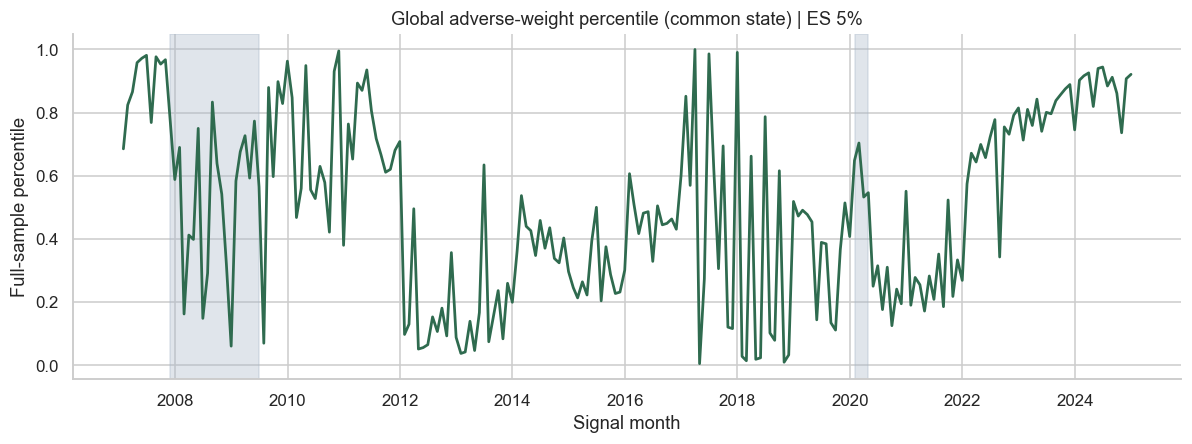

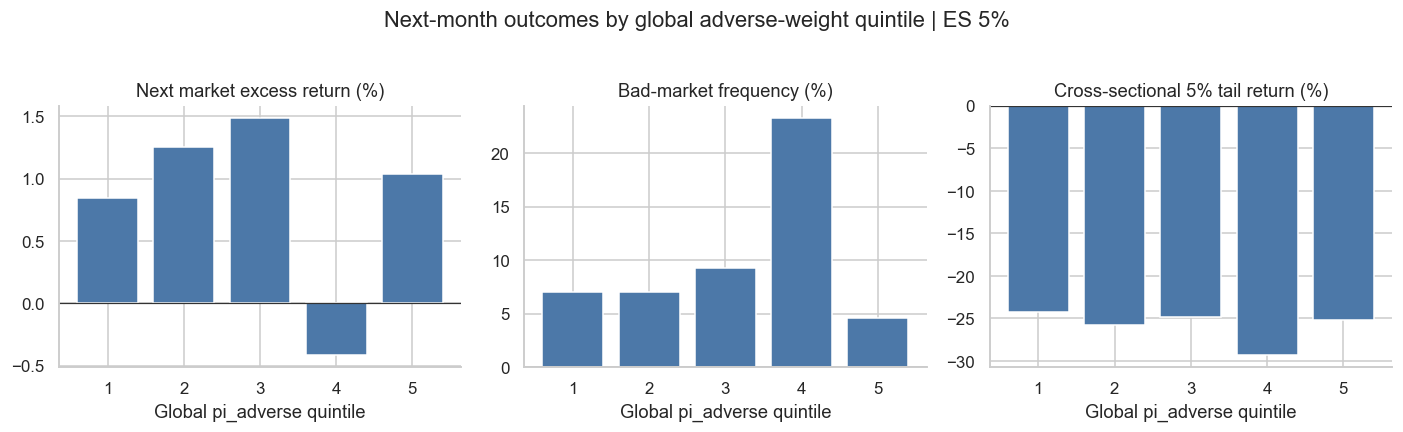

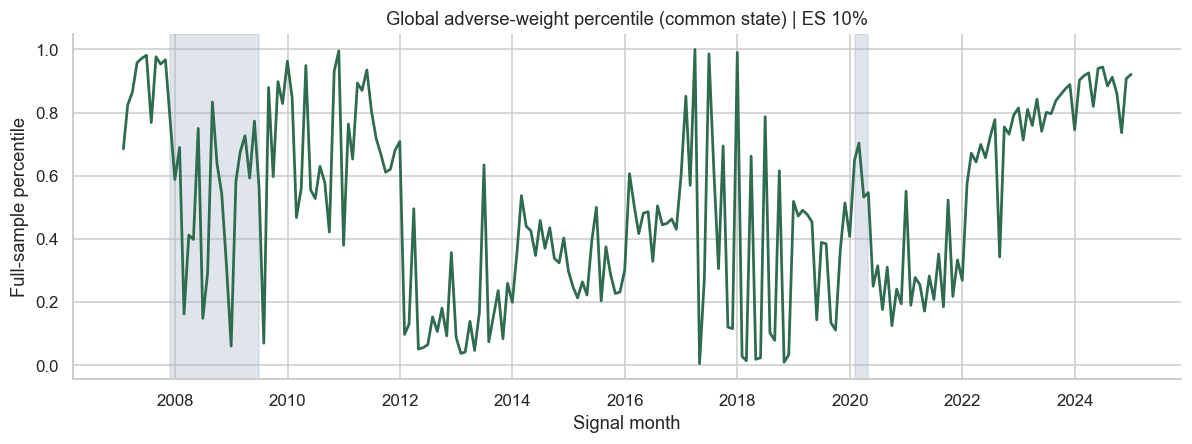

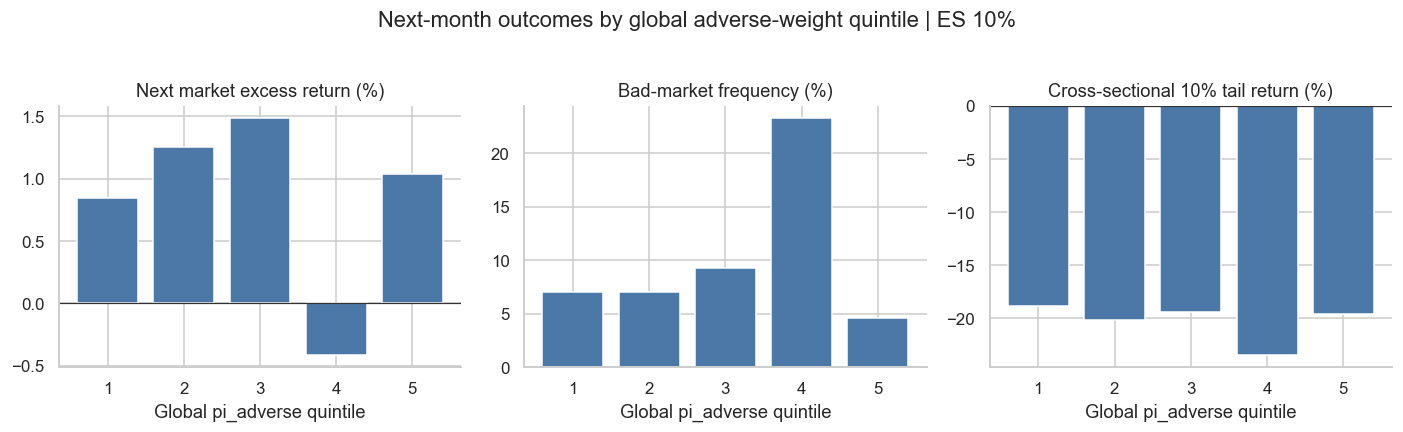

In [44]:
# ==========================================
# 10.3 图：窗口内 adverse-weight rank 和下一月结果
# ==========================================
for alpha in alphas:
    print(f"ES alpha = {alpha * 100:g}%")
    state_validation = state_validation_by_alpha[alpha]
    fig, ax = plt.subplots(figsize=(11, 4.2))
    ax.plot(state_validation["mthcaldt"], state_validation["pi_rank_global"], color="#2F6B4F", linewidth=1.8)
    for start, end in [("2007-12-01", "2009-06-30"), ("2020-02-01", "2020-04-30")]:
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), color="#A7B7C7", alpha=0.35)
    ax.set(
        title=f"Global adverse-weight percentile (common state) | ES {alpha * 100:g}%", 
        xlabel="Signal month", ylabel="Full-sample percentile")
    fig.tight_layout()
    fig.savefig(figure_dir / f"fig11_adverse_weight_time_series_alpha{alpha_suffix(alpha)}_{save_version}.pdf", dpi=220, bbox_inches="tight", pad_inches=0.02)


    state_validation = state_validation.copy()
    state_validation["pi_quintile"] = pd.cut(state_validation["pi_rank_global"], np.linspace(0, 1, 6), labels=np.arange(1, 6), include_lowest=True)
    state_bins = state_validation.groupby("pi_quintile", observed=True).agg(
        market_return=("mktrf_ff5", "mean"), bad_market_rate=("bad_market", "mean"),
        tail_return=("cross_section_tail_return", "mean"), months=("mthcaldt", "size"),
    ).reset_index()

    fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
    for ax, (column, title) in zip(axes, [
        ("market_return", "Next market excess return (%)"),
        ("bad_market_rate", "Bad-market frequency (%)"),
        ("tail_return", f"Cross-sectional {alpha * 100:g}% tail return (%)"),
    ]):
        ax.bar(state_bins["pi_quintile"].astype(int), 100 * state_bins[column], color="#4C78A8", edgecolor="white")
        ax.axhline(0, color="#333333", linewidth=0.8)
        ax.set(title=title, xlabel="Global pi_adverse quintile", xticks=np.arange(1, 6))
    fig.suptitle(f"Next-month outcomes by global adverse-weight quintile | ES {alpha * 100:g}%", y=1.03)
    fig.tight_layout()
    fig.savefig(figure_dir / f"fig12_adverse_weight_validation_alpha{alpha_suffix(alpha)}_{save_version}.pdf", dpi=220, bbox_inches="tight", pad_inches=0.02)



## 11. Severity 是否超越普通波动率

每个月先用 `sigma_bench`、规模、账面市值比和动量解释 adverse severity，再使用剩余部分进行组合排序和 Fama–MacBeth。该检验直接回答 severity 是否只是一个复杂的波动率信号。就是看残差是否显著


In [45]:
# ==========================================
# 11.1 构造横截面 residual severity
# ==========================================
def residualize_monthly(panel, dependent, controls, output_col):
    required = ["permno", "mthcaldt", "return_date", "target_ret_final", "mthcap", industry_type, "is_nyse", dependent, *controls]
    work = panel[required].replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)
    work = standardize_monthly(work, [dependent, *controls])
    work[output_col] = np.nan
    for positions in work.groupby("mthcaldt", sort=False).indices.values():
        month = work.iloc[positions]
        X = sm.add_constant(month[[f"z_{c}" for c in controls]].to_numpy(dtype=float))
        y = month[f"z_{dependent}"].to_numpy(dtype=float)
        work.loc[positions, output_col] = y - X @ np.linalg.lstsq(X, y, rcond=None)[0]
    return work
residual_severity_slopes_by_alpha = {}
for alpha in alphas:
    print(f"ES alpha = {alpha * 100:g}%")


    residual_severity_panel = residualize_monthly(
        pricing_base, f"severity_adverse_{alpha_suffix(alpha)}", control_cols, "severity_residual"
    )
    residual_severity_slopes = run_fama_macbeth(
        residual_severity_panel, "severity_residual", "residual_adverse_severity",
        "Residual adverse severity", "Residual adverse severity",
    )
    residual_severity_fmb = summarize_fama_macbeth(residual_severity_slopes)

    residual_severity_portfolios = sort_portfolios(residual_severity_panel, "severity_residual", PRIMARY_GROUPS, me_breakpoints, exclude_microcaps, breakpoint_universe=breakpoint_universe)
    residual_metadata = {
        "model_id": "residual_adverse_severity", "model_label": "Residual adverse severity",
        "signal_name": "Residual adverse severity", "n_groups": PRIMARY_GROUPS,
        "exclude_microcaps": False, "breakpoint_universe": "NYSE",
    }
    residual_severity_hml = build_hml(residual_severity_portfolios, residual_metadata)
    residual_severity_hml_summary = summarize_hml(residual_severity_hml)
    # display(residual_severity_fmb[residual_severity_fmb["specification"] == "Controls"][[
    #     "signal_name", "annualized_slope_pct", "nw_t", "p_value"
    # ]].round(4))
    # display(residual_severity_hml_summary[["weighting", "annualized_mean_pct", "nw_t", "p_value"]].round(4))
    residual_severity_fmb.to_parquet(result_dir / f"residual_severity_fmb_{timestamp}_alpha{alpha_suffix(alpha)}.parquet", index=False)
    residual_severity_hml_summary.to_parquet(result_dir / f"residual_severity_hml_summary_{timestamp}_alpha{alpha_suffix(alpha)}.parquet", index=False)
    display(residual_severity_fmb.round(4))
    display(residual_severity_hml_summary.round(4))

    residual_severity_slopes_by_alpha[alpha] = residual_severity_slopes


ES alpha = 5%


,model_id,model_label,signal_name,specification,mean_monthly,nw_se,nw_t,p_value,ci_95_low,ci_95_high,months,annualized_slope_pct,annualized_ci_low_pct,annualized_ci_high_pct
0,residual_adverse_severity,Residual adverse severity,Residual adverse severity,Controls,0.0005,0.0006,0.8416,0.4000,-0.0007,0.0018,216,0.6535,-0.8685,2.1756
1,residual_adverse_severity,Residual adverse severity,Residual adverse severity,Controls+IndustryFE,0.0005,0.0008,0.5856,0.5581,-0.0011,0.0020,216,0.5423,-1.2726,2.3571
2,residual_adverse_severity,Residual adverse severity,Residual adverse severity,Controls_0,0.0006,0.0007,0.9188,0.3582,-0.0007,0.0019,216,0.7322,-0.8297,2.2941
3,residual_adverse_severity,Residual adverse severity,Residual adverse severity,Controls_0+IndustryFE,0.0001,0.0006,0.1200,0.9045,-0.0012,0.0013,216,0.0931,-1.4276,1.6138
4,residual_adverse_severity,Residual adverse severity,Residual adverse severity,Controls_1,0.0006,0.0007,0.9402,0.3471,-0.0007,0.0019,216,0.7494,-0.8129,2.3116
5,residual_adverse_severity,Residual adverse severity,Residual adverse severity,Controls_1+IndustryFE,0.0001,0.0006,0.1566,0.8756,-0.0012,0.0014,216,0.1219,-1.4035,1.6473
6,residual_adverse_severity,Residual adverse severity,Residual adverse severity,Controls_2,0.0006,0.0007,0.8609,0.3893,-0.0007,0.0019,216,0.6792,-0.8671,2.2255
7,residual_adverse_severity,Residual adverse severity,Residual adverse severity,Controls_2+IndustryFE,0.0002,0.0007,0.2309,0.8174,-0.0011,0.0014,216,0.1819,-1.3620,1.7258
8,residual_adverse_severity,Residual adverse severity,Residual adverse severity,Controls_3,0.0006,0.0007,0.8636,0.3878,-0.0007,0.0019,216,0.6826,-0.8666,2.2318
9,residual_adverse_severity,Residual adverse severity,Residual adverse severity,Controls_3+IndustryFE,0.0002,0.0007,0.3661,0.7143,-0.0010,0.0015,216,0.2880,-1.2536,1.8296


,model_id,model_label,signal_name,weighting,n_groups,exclude_microcaps,breakpoint_universe,mean_monthly,nw_se,nw_t,p_value,ci_95_low,ci_95_high,months,annualized_mean_pct,annualized_ci_low_pct,annualized_ci_high_pct
0,residual_adverse_severity,Residual adverse severity,Residual adverse severity,EW,10,False,NYSE,0.0015,0.0022,0.6644,0.5064,-0.0028,0.0057,216,1.7465,-3.4054,6.8984
1,residual_adverse_severity,Residual adverse severity,Residual adverse severity,VW,10,False,NYSE,0.0012,0.0025,0.5056,0.6131,-0.0036,0.0061,216,1.4998,-4.3143,7.3139


ES alpha = 10%


,model_id,model_label,signal_name,specification,mean_monthly,nw_se,nw_t,p_value,ci_95_low,ci_95_high,months,annualized_slope_pct,annualized_ci_low_pct,annualized_ci_high_pct
0,residual_adverse_severity,Residual adverse severity,Residual adverse severity,Controls,0.0005,0.0006,0.7069,0.4796,-0.0008,0.0017,216,0.5416,-0.9601,2.0432
1,residual_adverse_severity,Residual adverse severity,Residual adverse severity,Controls+IndustryFE,0.0003,0.0008,0.4107,0.6813,-0.0012,0.0018,216,0.3828,-1.4439,2.2095
2,residual_adverse_severity,Residual adverse severity,Residual adverse severity,Controls_0,0.0005,0.0007,0.7923,0.4282,-0.0008,0.0018,216,0.6250,-0.9211,2.1711
3,residual_adverse_severity,Residual adverse severity,Residual adverse severity,Controls_0+IndustryFE,-0.0000,0.0007,-0.0606,0.9516,-0.0013,0.0012,216,-0.0474,-1.5805,1.4856
4,residual_adverse_severity,Residual adverse severity,Residual adverse severity,Controls_1,0.0005,0.0007,0.8137,0.4158,-0.0008,0.0018,216,0.6415,-0.9037,2.1867
5,residual_adverse_severity,Residual adverse severity,Residual adverse severity,Controls_1+IndustryFE,-0.0000,0.0007,-0.0231,0.9816,-0.0013,0.0013,216,-0.0181,-1.5574,1.5212
6,residual_adverse_severity,Residual adverse severity,Residual adverse severity,Controls_2,0.0005,0.0006,0.7294,0.4658,-0.0008,0.0017,216,0.5679,-0.9581,2.0939
7,residual_adverse_severity,Residual adverse severity,Residual adverse severity,Controls_2+IndustryFE,0.0000,0.0007,0.0459,0.9634,-0.0013,0.0013,216,0.0366,-1.5240,1.5971
8,residual_adverse_severity,Residual adverse severity,Residual adverse severity,Controls_3,0.0005,0.0007,0.7328,0.4637,-0.0008,0.0018,216,0.5719,-0.9577,2.1015
9,residual_adverse_severity,Residual adverse severity,Residual adverse severity,Controls_3+IndustryFE,0.0001,0.0007,0.1738,0.8620,-0.0012,0.0014,216,0.1382,-1.4208,1.6972


,model_id,model_label,signal_name,weighting,n_groups,exclude_microcaps,breakpoint_universe,mean_monthly,nw_se,nw_t,p_value,ci_95_low,ci_95_high,months,annualized_mean_pct,annualized_ci_low_pct,annualized_ci_high_pct
0,residual_adverse_severity,Residual adverse severity,Residual adverse severity,EW,10,False,NYSE,0.0008,0.0021,0.3882,0.6979,-0.0033,0.0049,216,0.9656,-3.9095,5.8407
1,residual_adverse_severity,Residual adverse severity,Residual adverse severity,VW,10,False,NYSE,0.0005,0.0026,0.2074,0.8357,-0.0046,0.0057,216,0.6540,-5.5266,6.8347


## 12. State-dependent pricing horse race

使用同一个 Structured `pi_adverse` 分别解释五个模型总 ES、adverse contribution、raw severity 和 residual severity 的月度价格斜率。若简单模型也得到相同结果，经济事实仍成立，但 Structured decomposition 不是必要条件。


逻辑： 正如中文注释所说：“若简单模型也得到相同结果……Structured decomposition 就不是必要条件。”所以这里引入了一个简单的基准模型叫 linear_quantile。

做法：

代码首先计算了“复杂模型斜率”与“简单模型斜率”的差值（difference = wide[candidate] - wide["linear_quantile"]）。

然后用市场状态 pi_adverse 去回归这个差值。

结论如何看： 如果回归结果显著（p_value 很小，nw_t 绝对值很大），说明复杂模型对恶劣市场状态的敏感度显著区别于（且通常是优于）简单的线性模型。这就证明了研究者费尽心思搞出来的“结构化分解”是不可替代的，是有学术价值的。

## 13. 极端 ES 组合的公司特征

下面检查极端 ES 组合的公司特征；收益率口径下第 1 组为最低 ES（最严重尾部亏损），第 10 组为最高 ES。比较其规模、波动率、账面市值比和动量，不预设哪组收益骤降。所有特征先在月内 winsorize 并标准化，再对月份等权平均。
